# ⚡ FastAPI — Serve ML Models as Fast, Safe Web APIs

> **What you'll learn:** how HTTP works for model serving, how to build a FastAPI prediction service with **Pydantic v2 validation** (bad input → `422`, never `500`), load a model **once** with lifespan events, protect it with API keys and rate limits, understand exactly when `async def` helps or hurts, stream results with Server-Sent Events, test it with pytest, run it under a real **uvicorn** server, and measure **p50/p95/p99 latency** under load. You'll also build an ASGI app with no framework at all, and see how Flask compares.

| | |
|---|---|
| **Difficulty** | 🟢 Beginner → 🟡 Intermediate (🔴 concurrency and load testing) |
| **Time** | ~4 hours to read and run, +2 hours for exercises and the project |
| **Prerequisites** | [Scikit-Learn](../03_Classical_Machine_Learning/02_Scikit_Learn.ipynb) (pipelines, saving models) · [Python Internals & Concurrency](../00_Foundations/05_Python_Internals_and_Concurrency.ipynb) (threads, the GIL, `asyncio`) |
| **Tested with** | Python 3.12 · fastapi 0.141 · pydantic 2.13 · uvicorn 0.52 · httpx 0.28 · scikit-learn 1.9 · flask 3.1 |
| **Interview relevance** | ⭐⭐⭐ High — "design a model-serving API", 422 vs 500, `def` vs `async def`, where to load the model, liveness vs readiness, p99 latency, batching, API security |

## 🤔 What Is FastAPI?

You trained a model in a notebook. Now a mobile app, a website, or another team's service needs predictions from it. They can't open your notebook — they need a **web API**: a program that listens on a network port, accepts requests like *"here are a house's features"*, and answers *"it's worth $243,000"*.

Think of a restaurant:

- The **kitchen** is your model. It makes the food (predictions).
- The **waiter** is the web API. It takes orders in a fixed format, checks they make sense ("we don't serve *purple* soup"), carries them to the kitchen, and brings back the result.
- The **menu** is the API documentation: what you can order and how.

**FastAPI** is a Python library for writing that waiter. You write normal Python functions with type hints; FastAPI turns them into web endpoints, **validates** every incoming request against your types (using the **Pydantic** library), converts results to JSON, and generates interactive documentation automatically.

```
 client (app, website, other service)
       │  HTTP request:  POST /predict   {"sepal_length": 5.1, ...}
       ▼
 ┌──────────── uvicorn (the server: sockets, HTTP parsing) ────────────┐
 │  FastAPI app:  route → validate with Pydantic → your function → JSON │
 │                                   │                                   │
 │                              model.predict()                          │
 └───────────────────────────────────────────────────────────────────────┘
       ▲  HTTP response: 200 OK   {"species": "setosa", ...}
```

Two more words you'll see everywhere:
- **uvicorn** is the *server*: the program that actually opens a network port and speaks HTTP. FastAPI is the *application* that uvicorn calls.
- **ASGI** (Asynchronous Server Gateway Interface) is the contract between them — a standard way for a Python server to call a Python web app. Flask uses the older **WSGI** contract.

## 🎯 Why It Matters

- **Most ML models in production sit behind an HTTP API.** Recommendation scores, fraud checks, embeddings, LLM chat — the model is useless until something can call it reliably.
- **FastAPI is the default choice for Python ML services** today, and it's the layer under many ML platforms. BentoML, Ray Serve, and LLM gateways share the same ideas: validation, lifespan loading, async, streaming.
- **Production problems live here, not in the model.** Malformed input that crashes the server, a model reloaded on every request, one slow endpoint that freezes all the others, memory that grows until the pod is killed. This notebook shows each problem *actually happening*, then fixes it.
- **In interviews** you'll hear: *"Design an API to serve this model"*, *"What status code for bad input?"*, *"`def` or `async def` for a CPU-heavy model?"*, *"How do you know your service is healthy?"*, *"Why p99 and not average latency?"*, *"How would you test it?"* You'll answer all of them with numbers you measured yourself.

## ✅ By the End You Can

- [ ] Explain HTTP methods, status codes, JSON, and idempotency, and pick the right status for every failure
- [ ] Build a FastAPI service with path/query/body parameters, Pydantic v2 validation, response models, and custom error handlers
- [ ] Load a model once with lifespan events, and add auth, rate limits, middleware, health and readiness checks
- [ ] Explain — with measurements — when `def` and `async def` endpoints block, and stream results with Server-Sent Events
- [ ] Test a service with `TestClient` and pytest, run it under uvicorn, and report p50/p95/p99 latency under load
- [ ] Build a raw ASGI app from scratch, and compare FastAPI with Flask accurately

## 📋 Table of Contents

1. [HTTP and REST for Model Serving](#1.-HTTP-and-REST-for-Model-Serving-🟢)
2. [Your First FastAPI App: Path and Query Parameters](#2.-Your-First-FastAPI-App:-Path-and-Query-Parameters-🟢)
3. [Request Bodies and Pydantic v2 Validation](#3.-Request-Bodies-and-Pydantic-v2-Validation-🟢)
4. [Response Models and Error Handling](#4.-Response-Models-and-Error-Handling-🟡)
5. [Load the Model Once: Lifespan Events](#5.-Load-the-Model-Once:-Lifespan-Events-🟡)
6. [Dependency Injection: Auth, Rate Limits, and Security Basics](#6.-Dependency-Injection:-Auth,-Rate-Limits,-and-Security-Basics-🟡)
7. [Running a Real Server: uvicorn in a Background Process](#7.-Running-a-Real-Server:-uvicorn-in-a-Background-Process-🟡)
8. [def vs async def: Who Blocks the Event Loop?](#8.-def-vs-async-def:-Who-Blocks-the-Event-Loop?-🔴)
9. [Batch Predictions, Size Limits, and Background Tasks](#9.-Batch-Predictions,-Size-Limits,-and-Background-Tasks-🟡)
10. [Streaming Responses with Server-Sent Events](#10.-Streaming-Responses-with-Server-Sent-Events-🟡)
11. [Middleware, CORS, Health and Readiness](#11.-Middleware,-CORS,-Health-and-Readiness-🟡)
12. [Testing with TestClient and pytest](#12.-Testing-with-TestClient-and-pytest-🟡)
13. [Latency Under Load: p50, p95, p99](#13.-Latency-Under-Load:-p50,-p95,-p99-🔴)
14. [Production Layout and a Flask Comparison](#14.-Production-Layout-and-a-Flask-Comparison-🟢)
- [🔧 Build It From Scratch](#🔧-Build-It-From-Scratch) · [⚠️ Common Pitfalls](#⚠️-Common-Pitfalls) · [🏋️ Practice Exercises](#🏋️-Practice-Exercises) · [🚀 Mini Project](#🚀-Mini-Project:-California-Housing-Price-Service) · [🎤 Interview Q&A](#🎤-Interview-Q&A) · [🧪 Quick Quiz](#🧪-Quick-Quiz) · [📚 Resources](#📚-Resources) · [📝 Summary](#📝-Summary-Cheat-Sheet)

## ⚙️ Setup

Run the cell below first. If a package is missing, uncomment the `%pip` line, run it once, then restart the kernel. Only one small dataset is downloaded (California Housing, ~0.5 MB, cached in `~/scikit_learn_data`).

**Two ways to call an API in this notebook:**
- **`TestClient`** calls your FastAPI app *inside the notebook process* — no network, instant. Perfect for learning and for tests.
- **A real uvicorn server** started in a *background process* on a free port, called over real HTTP with `httpx`. The `UvicornServer` helper below starts it, waits until it answers, and shuts it down gracefully (like pressing Ctrl+C) when the `with` block ends. We need this whenever the network matters: concurrency, streaming, load tests.

**Optional local LLM (only Section 10 uses it).** One streaming example forwards tokens from an OpenAI-compatible LLM server. It's configured with environment variables:

| Variable | Default | Meaning |
|---|---|---|
| `LLM_BASE_URL` | `http://127.0.0.1:8080/v1` | where the server lives |
| `LLM_MODEL` | `gpt-oss-20b` | model name the server expects |
| `LLM_API_KEY` | `local` | local servers ignore it; real providers need a real key |

To start one locally: `brew install llama.cpp`, then `llama-server -hf ggml-org/gpt-oss-20b-GGUF --port 8080 --jinja` (or `-m /path/to/gpt-oss-20b-MXFP4.gguf`). The same code works with Ollama (`http://localhost:11434/v1`), LM Studio, or OpenAI by changing the variables. If no server is reachable, that one cell prints a skip message. Nothing else depends on it.

The `check()` helper gives instant feedback on exercises: **✅** correct, **⏳** not attempted yet, **❌** wrong (with a hint). `check_routes()` does the same for small FastAPI apps you build.

In [1]:
# %pip install -q "fastapi[standard]>=0.135" "pydantic>=2.11" "uvicorn>=0.35" "httpx>=0.28" "scikit-learn>=1.8" joblib flask matplotlib openai

import asyncio
import atexit
import hashlib
import importlib.metadata as md
import io
import json
import logging
import math
import os
import re
import secrets
import signal
import socket
import subprocess
import sys
import textwrap
import time
import uuid
import warnings
from collections import deque
from contextlib import asynccontextmanager
from dataclasses import dataclass
from datetime import datetime, timezone
from functools import lru_cache
from http import HTTPStatus
from pathlib import Path
from typing import Annotated, Literal

import httpx
import joblib
import matplotlib.pyplot as plt
import numpy as np

# starlette 1.6's TestClient touches an `anyio.abc.BlockingPortal` alias that anyio 4.15 deprecated.
# It's inside the library (not our code) and harmless, so we silence exactly that one message.
warnings.filterwarnings("ignore", message=r"The anyio\.abc\.BlockingPortal alias is deprecated", category=DeprecationWarning)

from fastapi import (APIRouter, BackgroundTasks, Depends, FastAPI, Header, HTTPException, Query, Request, Security)
from fastapi import Path as PathParam                      # renamed: `Path` already means pathlib.Path here
from fastapi.concurrency import run_in_threadpool
from fastapi.exceptions import RequestValidationError
from fastapi.middleware.cors import CORSMiddleware
from fastapi.responses import JSONResponse
from fastapi.security import APIKeyHeader
from fastapi.sse import EventSourceResponse, ServerSentEvent
from fastapi.testclient import TestClient
from pydantic import BaseModel, ConfigDict, Field, ValidationError, field_validator, model_validator

for pkg in ["fastapi", "pydantic", "starlette", "uvicorn", "httpx", "scikit-learn", "flask"]:
    print(f"{pkg} {md.version(pkg)}", end=" | ")
print(f"Python {sys.version.split()[0]}")

SEED = 42
rng = np.random.default_rng(SEED)
OUTPUT_DIR = Path("_outputs").resolve()        # files we write go here (ignored by git)
LOG_DIR = OUTPUT_DIR / "logs"
LOG_DIR.mkdir(parents=True, exist_ok=True)

# Libraries stay at WARNING (httpx would log every request); our own loggers print INFO lines to the notebook
logging.basicConfig(level=logging.WARNING, format="%(levelname)s %(name)s: %(message)s", stream=sys.stdout, force=True)
logger = logging.getLogger("model_api")
logger.setLevel(logging.INFO)

# Optional local LLM (Section 10 only)
LLM_BASE_URL = os.environ.get("LLM_BASE_URL", "http://127.0.0.1:8080/v1")
LLM_MODEL = os.environ.get("LLM_MODEL", "gpt-oss-20b")
LLM_API_KEY = os.environ.get("LLM_API_KEY", "local")


def llm_available(timeout=2.0):
    try:
        return httpx.get(f"{LLM_BASE_URL}/models", headers={"Authorization": f"Bearer {LLM_API_KEY}"}, timeout=timeout).status_code == 200
    except httpx.HTTPError:
        return False


LLM_OK = llm_available()
print("Local LLM server:", f"reachable at {LLM_BASE_URL}" if LLM_OK else f"not reachable at {LLM_BASE_URL} (Section 10's LLM cell will skip)")


def check(name, got, expected, hint=""):
    """✅ if correct, ⏳ if not attempted yet (None), ❌ AssertionError with a hint otherwise."""
    if got is None or got is ...:
        print(f"⏳ {name}: not attempted yet — replace None with your answer.")
        return

    def close(a, b):
        if isinstance(b, float) or isinstance(a, float):
            return isinstance(a, (int, float)) and isinstance(b, (int, float)) and math.isclose(a, b, rel_tol=1e-6, abs_tol=1e-9)
        if isinstance(b, dict):
            return isinstance(a, dict) and a.keys() == b.keys() and all(close(a[k], b[k]) for k in b)
        if isinstance(b, (list, tuple)):
            return isinstance(a, (list, tuple)) and len(a) == len(b) and all(close(x, y) for x, y in zip(a, b))
        return a == b

    assert close(got, expected), f"❌ {name}: not quite (got {got!r}). {hint}"
    print(f"✅ {name}: correct!")


BUILTIN_PATHS = {"/openapi.json", "/docs", "/docs/oauth2-redirect", "/redoc"}


def check_routes(name, app, cases, hint=""):
    """Call a FastAPI app with each case and compare status (and JSON / headers when given).

    A case is a dict: method, path, optional json/headers/content, expected status, optional expected json/headers.
    """
    if app is None or not [r for r in app.routes if getattr(r, "path", None) not in BUILTIN_PATHS]:
        print(f"⏳ {name}: not attempted yet — build the app first.")
        return
    with TestClient(app, raise_server_exceptions=False) as client:
        for case in cases:
            kwargs = {k: case[k] for k in ("json", "headers", "content") if k in case}
            response = client.request(case.get("method", "GET"), case["path"], **kwargs)
            label = f"{case.get('method', 'GET')} {case['path']}"
            assert response.status_code == case["status"], (
                f"❌ {name}: {label} returned {response.status_code}, expected {case['status']}. Body: {response.text[:200]} {hint}")
            if "expect_json" in case:
                assert response.json() == case["expect_json"], f"❌ {name}: {label} returned {response.json()}, expected {case['expect_json']}. {hint}"
            for header, value in case.get("expect_headers", {}).items():
                assert response.headers.get(header) == value, f"❌ {name}: {label} header {header}={response.headers.get(header)!r}, expected {value!r}. {hint}"
    print(f"✅ {name}: correct! ({len(cases)} requests behaved as expected)")


def is_valid(model_cls, payload):
    """True if a Pydantic model accepts the payload."""
    try:
        model_cls.model_validate(payload)
        return True
    except ValidationError:
        return False


def short_path(text):
    """Show paths relative to the notebook (`_outputs/...`) and the home folder as `~`, never full local paths."""
    return str(text).replace(str(OUTPUT_DIR), "_outputs").replace(str(Path.home()), "~")


def free_port():
    with socket.socket() as s:
        s.bind(("127.0.0.1", 0))
        return s.getsockname()[1]


def write(path, text):
    """Create a file (and its folders) from an indented triple-quoted string."""
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    path.write_text(textwrap.dedent(text).lstrip("\n"))


def tree(root):
    root = Path(root)
    skip = {"__pycache__", ".pytest_cache", ".ruff_cache"}
    print(f"📁 {root.name}/")
    for p in sorted(root.rglob("*")):
        parts = p.relative_to(root).parts
        if any(part in skip for part in parts):
            continue
        print("    " * len(parts) + ("📁 " if p.is_dir() else "📄 ") + p.name + ("/" if p.is_dir() else ""))


def run(cmd, cwd=None, env=None, max_lines=40):
    """Run a command like a terminal: print `$ command`, its output, and the exit code if non-zero."""
    cmd = [str(c) for c in cmd]
    result = subprocess.run(cmd, cwd=cwd, env={**os.environ, **(env or {})}, capture_output=True, text=True, timeout=600)
    shown = ["python" if c == sys.executable else c for c in cmd]
    print("$", " ".join(shown))
    lines = (result.stdout + result.stderr).rstrip().splitlines()
    for line in lines[-max_lines:]:
        print("  " + short_path(re.sub(r"\x1b\[[0-9;]*m", "", line)))      # drop terminal colour codes
    if result.returncode != 0:
        print(f"  [exit code {result.returncode}]")
    return result


_RUNNING_SERVERS = []


class UvicornServer:
    """Run `python -m uvicorn <target>` in a background process on a free port.

    with UvicornServer("iris_api:app", cwd=folder) as server:
        httpx.get(server.base_url + "/health")
    """

    def __init__(self, target, cwd, env=None, workers=1, ready_path="/health", extra_args=()):
        self.target, self.cwd, self.workers, self.ready_path = target, Path(cwd), workers, ready_path
        self.port = free_port()
        self.base_url = f"http://127.0.0.1:{self.port}"
        self.env = {**os.environ, "PYTHONUNBUFFERED": "1", **(env or {})}
        self.extra_args = [str(a) for a in extra_args]
        self.log_path = LOG_DIR / f"{target.replace(':', '_').replace('.', '_')}_{self.port}.log"
        self.proc, self.startup_seconds, self.returncode = None, None, None

    def __enter__(self):
        cmd = [sys.executable, "-m", "uvicorn", self.target, "--host", "127.0.0.1", "--port", str(self.port),
               "--workers", str(self.workers), *self.extra_args]
        self._log = open(self.log_path, "w")
        start = time.perf_counter()
        self.proc = subprocess.Popen(cmd, cwd=self.cwd, env=self.env, stdout=self._log, stderr=subprocess.STDOUT)
        _RUNNING_SERVERS.append(self)
        while time.perf_counter() - start < 60:
            if self.proc.poll() is not None:
                self._log.close()
                raise RuntimeError(f"uvicorn exited early (code {self.proc.returncode}):\n{self.log_text()[-2000:]}")
            try:
                status_code = httpx.get(self.base_url + self.ready_path, timeout=1).status_code
                if status_code == 200:
                    self.startup_seconds = time.perf_counter() - start
                    return self
                if status_code == 404:
                    self.stop()
                    raise RuntimeError(f"{self.ready_path} does not exist on {self.target} — pass a valid ready_path")
            except httpx.TransportError:
                pass                                   # not listening yet
            time.sleep(0.05)
        self.stop()
        raise TimeoutError(f"server not ready after 60 s:\n{self.log_text()[-2000:]}")

    def stop(self):
        if self.proc is not None and self.proc.poll() is None:
            self.proc.send_signal(signal.SIGTERM)      # graceful shutdown, like Ctrl+C or `docker stop`
            try:
                self.proc.wait(timeout=20)
            except subprocess.TimeoutExpired:
                self.proc.kill()
                self.proc.wait()
        if self.proc is not None:
            self.returncode = self.proc.returncode
        if hasattr(self, "_log") and not self._log.closed:
            self._log.close()

    def __exit__(self, *exc):
        self.stop()

    def log_text(self):
        return self.log_path.read_text()


atexit.register(lambda: [server.stop() for server in _RUNNING_SERVERS])

fastapi 0.141.1 | pydantic 2.13.5 | starlette 1.6.0 | uvicorn 0.52.4 | httpx 0.28.1 | scikit-learn 1.9.1 | flask 3.1.3 | Python 3.12.11
Local LLM server: not reachable at http://127.0.0.1:8080/v1 (Section 10's LLM cell will skip)


<function __main__.<lambda>()>

## 1. HTTP and REST for Model Serving 🟢

Every call to a model API is one **HTTP request** followed by one **HTTP response**.

```
REQUEST                                          RESPONSE
POST /v1/predict HTTP/1.1      ← method + path   HTTP/1.1 200 OK            ← status code
Host: api.example.com          ← headers         content-type: application/json
content-type: application/json                   x-request-id: 3f9c…
x-api-key: ••••••••
                                                 {"species": "setosa", "probability": 0.98}
{"sepal_length": 5.1, ...}     ← body (JSON)                               ← body
```

**Methods** say what you want to do. Two properties matter:
- **Safe** = doesn't change anything on the server.
- **Idempotent** = sending the same request 1 time or 10 times leaves the server in the same state. Clients and proxies may **retry** idempotent requests automatically after a timeout; they must not blindly retry non-idempotent ones.

| Method | Typical use in an ML service | Safe | Idempotent |
|---|---|---|---|
| `GET` | read: `/health`, `/models/iris/info` | ✅ | ✅ |
| `POST` | compute or create: `/predict`, `/jobs` (start a batch job) | ❌ | ❌ |
| `PUT` | replace a resource: `/models/iris/config` | ❌ | ✅ |
| `PATCH` | partially update a resource | ❌ | ❌ (usually) |
| `DELETE` | remove: `/jobs/42` | ❌ | ✅ |

Predictions use `POST` even though a pure prediction changes nothing, because the input is a JSON body (GET requests shouldn't carry bodies). If a `POST` *does* create something — say, a paid batch job — clients send an **`Idempotency-Key`** header so the server can recognise a retry and not start the job twice.

**REST** (REpresentational State Transfer) is a style, not a library: URLs name **resources** (nouns: `/models/iris/predictions`), methods say the action, and responses use standard **status codes**:

- **2xx** success · **4xx** *the client* made a mistake (don't retry unchanged) · **5xx** *the server* failed (retrying may help)

**JSON** (JavaScript Object Notation) is the text format for bodies: objects `{}`, arrays `[]`, strings, numbers, `true/false`, `null`. Standard JSON has **no NaN or Infinity** — remember that, it causes a real bug in Section 4.

In [2]:
ml_meaning = {
    200: "prediction returned",
    201: "resource created (e.g. a registered model)",
    202: "accepted: a batch job started, poll for the result",
    204: "success with no body (e.g. deleted)",
    400: "malformed request the server can't interpret",
    401: "missing or invalid credentials (API key)",
    403: "valid credentials, but not allowed",
    404: "unknown resource (model version, job id)",
    405: "wrong method (GET on a POST-only route)",
    413: "body too large (giant batch upload)",
    422: "well-formed JSON that fails validation",
    429: "too many requests: rate limit hit",
    500: "bug in the server — should never be caused by user input",
    503: "temporarily unavailable (model still loading, overloaded)",
}
for code, meaning in ml_meaning.items():
    print(f"{code}  {HTTPStatus(code).phrase:<24} → {meaning}")

200  OK                       → prediction returned
201  Created                  → resource created (e.g. a registered model)
202  Accepted                 → accepted: a batch job started, poll for the result
204  No Content               → success with no body (e.g. deleted)
400  Bad Request              → malformed request the server can't interpret
401  Unauthorized             → missing or invalid credentials (API key)
403  Forbidden                → valid credentials, but not allowed
404  Not Found                → unknown resource (model version, job id)
405  Method Not Allowed       → wrong method (GET on a POST-only route)
413  Request Entity Too Large → body too large (giant batch upload)
422  Unprocessable Entity     → well-formed JSON that fails validation
429  Too Many Requests        → too many requests: rate limit hit
500  Internal Server Error    → bug in the server — should never be caused by user input
503  Service Unavailable      → temporarily unavailable (model sti

In [3]:
# httpx builds the exact request a client would send — no network needed to inspect it
request = httpx.Request(
    "POST", "https://api.example.com/v1/predict",
    headers={"X-API-Key": "demo-key"},
    json={"sepal_length": 5.1, "sepal_width": 3.5, "petal_length": 1.4, "petal_width": 0.2},
)
print(request.method, request.url.path)
for key, value in request.headers.items():
    print(f"  {key}: {value}")
print("body bytes:", request.content)

# Python's json module writes NaN, but NaN is NOT valid JSON — strict encoders refuse it
print("\njson.dumps(nan):", json.dumps({"x": float("nan")}))
try:
    json.dumps({"x": float("nan")}, allow_nan=False)
except ValueError as err:
    print("strict JSON encoder:", err)

POST /v1/predict
  host: api.example.com
  x-api-key: demo-key
  content-length: 75
  content-type: application/json
body bytes: b'{"sepal_length":5.1,"sepal_width":3.5,"petal_length":1.4,"petal_width":0.2}'

json.dumps(nan): {"x": NaN}
strict JSON encoder: Out of range float values are not JSON compliant: nan


### ✍️ Your Turn

Pick the status code a model API should return in each situation (use the table above).

In [4]:
status_for = {
    "body is missing a required feature": None,
    "X-API-Key header is missing": None,
    "valid key, but the key may not call the admin endpoint": None,
    "model is still loading during startup": None,
    "client sent 200 requests in one second (limit is 10)": None,
}
check("status_for", None if None in status_for.values() else status_for,
      {"body is missing a required feature": 422, "X-API-Key header is missing": 401,
       "valid key, but the key may not call the admin endpoint": 403, "model is still loading during startup": 503,
       "client sent 200 requests in one second (limit is 10)": 429},
      hint="401 = who are you? · 403 = I know you, but no · 422 = validation · 429 = slow down · 503 = try later")

⏳ status_for: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
status_for = {
    "body is missing a required feature": 422,
    "X-API-Key header is missing": 401,
    "valid key, but the key may not call the admin endpoint": 403,
    "model is still loading during startup": 503,
    "client sent 200 requests in one second (limit is 10)": 429,
}
check("status_for", status_for,
      {"body is missing a required feature": 422, "X-API-Key header is missing": 401,
       "valid key, but the key may not call the admin endpoint": 403, "model is still loading during startup": 503,
       "client sent 200 requests in one second (limit is 10)": 429})
```

A good rule: **4xx means "the client should change the request"**, **5xx means "the server has a problem"**. That's why a validation failure must never surface as a 500. Monitoring treats 5xx as incidents, and clients may retry 5xx, which multiplies bad traffic.
</details>

> 💡 **Interview angle:** "401 vs 403?" — 401 *Unauthorized* really means **unauthenticated** (no or invalid credentials); 403 *Forbidden* means authenticated but **not permitted**. "Is POST idempotent?" — no. Make retries safe with an `Idempotency-Key` header that the server stores with the result.

## 2. Your First FastAPI App: Path and Query Parameters 🟢

A FastAPI app is an object plus **path operations**: a decorator (`@app.get("/path")`) on a normal function. The function's parameters tell FastAPI where each input comes from:

| Parameter kind | Example URL | Declared as |
|---|---|---|
| **Path** parameter — part of the URL path | `/flowers/42` | `def get_flower(index: int)` with `{index}` in the route |
| **Query** parameter — after `?` | `/flowers?species=setosa&limit=3` | any simple parameter *not* in the path |
| **Body** — JSON payload | `POST /predict` + `{...}` | a Pydantic model parameter (next section) |

Type hints aren't decoration: `index: int` makes FastAPI **convert** `"42"` → `42` and **reject** `"abc"` with a 422. `Annotated[int, PathParam(ge=0)]` / `Query(le=20)` add constraints.

We'll serve the real **Iris** dataset (150 flowers, 4 measurements each) so there's something to look at.

In [5]:
from sklearn.datasets import load_iris

iris = load_iris(as_frame=True)
FEATURES = ["sepal_length", "sepal_width", "petal_length", "petal_width"]
flowers = iris.data.set_axis(FEATURES, axis=1)
flowers["species"] = [str(iris.target_names[t]) for t in iris.target]
records = flowers.to_dict(orient="records")
print(len(records), "flowers | first:", records[0])

hello_app = FastAPI(title="Iris Explorer", version="0.1.0")


@hello_app.get("/")
def root():
    return {"message": "Hello, model serving!", "n_flowers": len(records)}   # dicts become JSON automatically


@hello_app.get("/flowers/{index}")
def get_flower(index: Annotated[int, PathParam(ge=0, description="Row number in the dataset")]):
    if index >= len(records):
        raise HTTPException(status_code=404, detail=f"No flower at index {index}")
    return records[index]


@hello_app.get("/flowers")
def list_flowers(
    species: Literal["setosa", "versicolor", "virginica"] | None = None,   # optional query parameter
    limit: Annotated[int, Query(ge=1, le=20)] = 3,                        # query parameter with a default + bounds
):
    rows = [r for r in records if species is None or r["species"] == species][:limit]
    return {"count": len(rows), "flowers": rows}


client = TestClient(hello_app)       # calls the app in-process, no server needed
for method, url in [("GET", "/"), ("GET", "/flowers/0"), ("GET", "/flowers/999"), ("GET", "/flowers/abc"),
                    ("GET", "/flowers?species=virginica&limit=1"), ("GET", "/flowers?limit=500"),
                    ("GET", "/flowers?species=rose"), ("DELETE", "/flowers/0"), ("GET", "/nope")]:
    response = client.request(method, url)
    print(f"{method:6} {url:38} → {response.status_code} {response.text[:90]}")

150 flowers | first: {'sepal_length': 5.1, 'sepal_width': 3.5, 'petal_length': 1.4, 'petal_width': 0.2, 'species': 'setosa'}
GET    /                                      → 200 {"message":"Hello, model serving!","n_flowers":150}
GET    /flowers/0                             → 200 {"sepal_length":5.1,"sepal_width":3.5,"petal_length":1.4,"petal_width":0.2,"species":"seto
GET    /flowers/999                           → 404 {"detail":"No flower at index 999"}
GET    /flowers/abc                           → 422 {"detail":[{"type":"int_parsing","loc":["path","index"],"msg":"Input should be a valid int
GET    /flowers?species=virginica&limit=1     → 200 {"count":1,"flowers":[{"sepal_length":6.3,"sepal_width":3.3,"petal_length":6.0,"petal_widt
GET    /flowers?limit=500                     → 422 {"detail":[{"type":"less_than_equal","loc":["query","limit"],"msg":"Input should be less t
GET    /flowers?species=rose                  → 422 {"detail":[{"type":"literal_error","loc":["query","species"

Read the output carefully. Nobody wrote a single `if` for `"abc"`, `limit=500`, `species=rose`, `DELETE`, or `/nope`, yet each got the correct status: **422** for invalid values, **405** for the wrong method, **404** for unknown paths. The type hints did the work.

### ✍️ Your Turn

Build `species_app` with a route **`GET /species/{name}/count`** that returns `{"species": name, "count": <number of flowers of that species>}`. `name` must be one of the three species (anything else → 422 automatically, via `Literal`).

In [6]:
species_app = None  # TODO: create a FastAPI() app and add the route
check_routes("species_count", species_app, [
    {"path": "/species/setosa/count", "status": 200, "expect_json": {"species": "setosa", "count": 50}},
    {"path": "/species/rose/count", "status": 422},
], hint="Use `name: Literal['setosa', 'versicolor', 'virginica']` and count matching records.")

⏳ species_count: not attempted yet — build the app first.


<details><summary>💡 Show solution</summary>

```python
species_app = FastAPI()

@species_app.get("/species/{name}/count")
def species_count(name: Literal["setosa", "versicolor", "virginica"]):
    return {"species": name, "count": sum(r["species"] == name for r in records)}

check_routes("species_count", species_app, [
    {"path": "/species/setosa/count", "status": 200, "expect_json": {"species": "setosa", "count": 50}},
    {"path": "/species/rose/count", "status": 422},
])
```
</details>

> 💡 **Interview angle:** "How does FastAPI know where a parameter comes from?" — names in the path template are **path** params, Pydantic models are the **body**, other simple types are **query** params; `Header()`, `Cookie()`, and `Depends()` make other sources explicit. Types drive both conversion and validation.

## 3. Request Bodies and Pydantic v2 Validation 🟢

A model API receives untrusted input from the internet. **Pydantic** describes what valid input looks like as a Python class. FastAPI checks every request body against it *before* your function runs, so your code only ever sees clean data.

| Tool | What it does | Example |
|---|---|---|
| `Field(gt=, ge=, lt=, le=)` | numeric bounds | `Field(gt=0, le=15)` |
| `Field(min_length=, max_length=)` | string / list length | `Field(min_length=1, max_length=100)` |
| `Field(allow_inf_nan=False)` | reject NaN / ±Infinity | important for model inputs |
| `Field(description=, examples=[...])` | documentation in `/docs` | `examples=[5.1]` (**not** the old `example=`) |
| `ConfigDict(extra="forbid")` | unknown fields → error (catches typos!) | `model_config = ConfigDict(extra="forbid")` |
| `@field_validator("x")` | custom check or cleanup for **one** field | strip whitespace, reject blanks |
| `@model_validator(mode="after")` | checks that need **several** fields | `petal_width <= petal_length` |
| `ConfigDict(json_schema_extra={"examples": [...]})` | a whole example request in the docs | |

Pydantic v2 is **lax by default**: `"5.1"` (a string) is converted to `5.1`. Use `strict=True` when you'd rather reject that.

In [7]:
class IrisFeatures(BaseModel):
    """Four flower measurements in centimetres — the model's input."""

    model_config = ConfigDict(
        extra="forbid",
        json_schema_extra={"examples": [{"sepal_length": 5.1, "sepal_width": 3.5, "petal_length": 1.4, "petal_width": 0.2}]},
    )

    sepal_length: float = Field(gt=0, le=15, allow_inf_nan=False, description="Sepal length (cm)", examples=[5.1])
    sepal_width: float = Field(gt=0, le=15, allow_inf_nan=False, description="Sepal width (cm)", examples=[3.5])
    petal_length: float = Field(gt=0, le=15, allow_inf_nan=False, description="Petal length (cm)", examples=[1.4])
    petal_width: float = Field(gt=0, le=15, allow_inf_nan=False, description="Petal width (cm)", examples=[0.2])

    @model_validator(mode="after")
    def petal_width_not_above_length(self):
        if self.petal_width > self.petal_length:
            raise ValueError("petal_width cannot exceed petal_length")
        return self


real_rows_ok = sum(is_valid(IrisFeatures, {f: r[f] for f in FEATURES}) for r in records)
print(f"{real_rows_ok}/{len(records)} real iris rows pass validation (the rules must never reject real data)")

good = {"sepal_length": 5.1, "sepal_width": 3.5, "petal_length": 1.4, "petal_width": 0.2}
attempts = {
    "valid": good,
    "string number (lax)": {**good, "sepal_length": "5.1"},
    "negative": {**good, "sepal_length": -1},
    "not a number": {**good, "sepal_width": "wide"},
    "NaN": {**good, "petal_length": float("nan")},
    "typo in field name": {**{k: v for k, v in good.items() if k != "petal_length"}, "petal_lenght": 1.4},
    "width > length": {**good, "petal_width": 3.0},
}
for label, payload in attempts.items():
    try:
        parsed = IrisFeatures.model_validate(payload)
        print(f"✅ {label:22} → accepted: sepal_length={parsed.sepal_length!r}")
    except ValidationError as err:
        problems = [f"{'.'.join(map(str, e['loc'])) or '(model)'}: {e['msg']}" for e in err.errors()]
        print(f"❌ {label:22} → {problems}")

150/150 real iris rows pass validation (the rules must never reject real data)
✅ valid                  → accepted: sepal_length=5.1
✅ string number (lax)    → accepted: sepal_length=5.1
❌ negative               → ['sepal_length: Input should be greater than 0']
❌ not a number           → ['sepal_width: Input should be a valid number, unable to parse string as a number']
❌ NaN                    → ['petal_length: Input should be a finite number']
❌ typo in field name     → ['petal_length: Field required', 'petal_lenght: Extra inputs are not permitted']
❌ width > length         → ['(model): Value error, petal_width cannot exceed petal_length']


Notice the **typo** case: without `extra="forbid"` Pydantic would *ignore* `petal_lenght`. If the field also had a default value, the model would silently predict from the default — a wrong answer with a 200 status. The ⚠️ Pitfalls section shows exactly that.

`@field_validator` is for one field, for example cleaning text before an NLP model sees it:

In [8]:
class ReviewRequest(BaseModel):
    model_config = ConfigDict(extra="forbid")

    text: str = Field(min_length=1, max_length=2000, examples=["Battery life is great"])
    language: Literal["en", "es", "fr"] = "en"

    @field_validator("text")
    @classmethod
    def strip_and_reject_blank(cls, value: str) -> str:
        cleaned = value.strip()
        if not cleaned:
            raise ValueError("text must contain non-whitespace characters")
        return cleaned                                  # the returned value replaces the input


print(ReviewRequest(text="   Loved it!  ").text)
for payload in [{"text": "    "}, {"text": "hola", "language": "de"}]:
    try:
        ReviewRequest.model_validate(payload)
    except ValidationError as err:
        print(payload, "→", err.errors()[0]["msg"])


class StrictNumber(BaseModel):
    model_config = ConfigDict(strict=True)
    x: float


print("strict mode rejects '5.1':", not is_valid(StrictNumber, {"x": "5.1"}), "| still accepts 5:", is_valid(StrictNumber, {"x": 5}))

# `Field(example=...)` is the removed Pydantic v1 style — it triggers a deprecation warning in v2
with warnings.catch_warnings(record=True) as caught:
    warnings.simplefilter("always")

    class OldStyle(BaseModel):
        x: float = Field(example=1.0)

print("Field(example=...) →", caught[0].category.__name__, "|", str(caught[0].message)[:95], "…")

Loved it!
{'text': '    '} → Value error, text must contain non-whitespace characters
{'text': 'hola', 'language': 'de'} → Input should be 'en', 'es' or 'fr'
strict mode rejects '5.1': True | still accepts 5: True
Field(example=...) → PydanticDeprecatedSince20 | Using extra keyword arguments on `Field` is deprecated and will be removed. Use `json_schema_ex …


Now plug the model into FastAPI. A parameter typed as a Pydantic model is read from the **JSON body**, and a failure becomes a **422** response that lists every problem with its location:

In [9]:
validate_app = FastAPI()


@validate_app.post("/echo")
def echo(features: IrisFeatures) -> IrisFeatures:          # the return type hint doubles as the response model
    return features


client = TestClient(validate_app)
response = client.post("/echo", json={"sepal_length": -1, "sepal_width": 3.5, "petal_length": 1.4, "colour": "blue"})
print(response.status_code, response.reason_phrase)      # RFC 9110 renamed 422 "Unprocessable Entity" → "Unprocessable Content"
for error in response.json()["detail"]:                 # one entry per problem: where (loc), what (msg), the bad value (input)
    print(" ", error)

schema = validate_app.openapi()["components"]["schemas"]["IrisFeatures"]
print("\nOpenAPI schema for sepal_length:", schema["properties"]["sepal_length"])
print("whole-request example shown in /docs:", schema["examples"][0])

422 Unprocessable Content
  {'type': 'greater_than', 'loc': ['body', 'sepal_length'], 'msg': 'Input should be greater than 0', 'input': -1, 'ctx': {'gt': 0.0}}
  {'type': 'missing', 'loc': ['body', 'petal_width'], 'msg': 'Field required', 'input': {'sepal_length': -1, 'sepal_width': 3.5, 'petal_length': 1.4, 'colour': 'blue'}}
  {'type': 'extra_forbidden', 'loc': ['body', 'colour'], 'msg': 'Extra inputs are not permitted', 'input': 'blue'}

OpenAPI schema for sepal_length: {'type': 'number', 'maximum': 15.0, 'exclusiveMinimum': 0.0, 'title': 'Sepal Length', 'description': 'Sepal length (cm)', 'examples': [5.1]}
whole-request example shown in /docs: {'petal_length': 1.4, 'petal_width': 0.2, 'sepal_length': 5.1, 'sepal_width': 3.5}


### ✍️ Your Turn

Define a Pydantic model `HouseRequest` with:
- `rooms`: integer from 1 to 20 (inclusive)
- `area_sqm`: float greater than 10 and at most 2000
- `city`: either `"paris"` or `"lyon"`
- unknown fields are **forbidden**

In [10]:
house_payloads = [
    {"rooms": 3, "area_sqm": 75.0, "city": "paris"},                    # fine
    {"rooms": 0, "area_sqm": 75.0, "city": "paris"},                    # too few rooms
    {"rooms": 3, "area_sqm": 5, "city": "lyon"},                        # too small
    {"rooms": 3, "area_sqm": 75.0, "city": "berlin"},                   # unknown city
    {"rooms": 3, "area_sqm": 75.0, "city": "lyon", "garage": True},     # extra field
    {"rooms": 20, "area_sqm": 2000, "city": "lyon"},                    # both limits are inclusive/allowed
]
HouseRequest = None  # TODO: replace this line with `class HouseRequest(BaseModel): ...`
accepted = None if HouseRequest is None else [is_valid(HouseRequest, p) for p in house_payloads]
check("house_request", accepted, [True, False, False, False, False, True],
      hint="Field(ge=1, le=20), Field(gt=10, le=2000), Literal['paris', 'lyon'], ConfigDict(extra='forbid').")

⏳ house_request: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
class HouseRequest(BaseModel):
    model_config = ConfigDict(extra="forbid")
    rooms: int = Field(ge=1, le=20)
    area_sqm: float = Field(gt=10, le=2000)
    city: Literal["paris", "lyon"]

house_payloads = [
    {"rooms": 3, "area_sqm": 75.0, "city": "paris"},
    {"rooms": 0, "area_sqm": 75.0, "city": "paris"},
    {"rooms": 3, "area_sqm": 5, "city": "lyon"},
    {"rooms": 3, "area_sqm": 75.0, "city": "berlin"},
    {"rooms": 3, "area_sqm": 75.0, "city": "lyon", "garage": True},
    {"rooms": 20, "area_sqm": 2000, "city": "lyon"},
]
accepted = [is_valid(HouseRequest, p) for p in house_payloads]
check("house_request", accepted, [True, False, False, False, False, True])
```
</details>

> 💡 **Interview angle:** "How do you stop garbage input from reaching the model?" — a schema at the boundary: types, bounds, `allow_inf_nan=False`, `extra="forbid"`, length limits. Invalid requests get a **422** before any model code runs. Mention that validation bounds should allow all real data (we checked all 150 rows), and that out-of-distribution inputs can be *flagged* rather than rejected.

## 4. Response Models and Error Handling 🟡

First, a model worth serving: a scikit-learn pipeline trained on iris, saved with `joblib` together with its class names and a **version string**, so every prediction can say which model produced it.

Then three tools for responses and errors:
- **`response_model`** (or a return type hint) — FastAPI validates and **filters** what you return, so internal fields never leak to clients.
- **`HTTPException(status_code, detail)`** — stop and return an error from anywhere in your code.
- **`@app.exception_handler(SomeError)`** — turn your own exception types (or FastAPI's) into consistent JSON responses.

In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

X_iris = flowers[FEATURES].to_numpy()
y_iris = iris.target.to_numpy()
X_tr, X_te, y_tr, y_te = train_test_split(X_iris, y_iris, test_size=0.3, random_state=SEED, stratify=y_iris)
iris_model = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000)).fit(X_tr, y_tr)
print(f"iris test accuracy: {iris_model.score(X_te, y_te):.3f}")

IRIS_MODEL_PATH = OUTPUT_DIR / "iris_model.joblib"
joblib.dump({"model": iris_model, "classes": [str(c) for c in iris.target_names], "version": "iris-logreg-1"}, IRIS_MODEL_PATH)
MODELS = {"iris-logreg-1": joblib.load(IRIS_MODEL_PATH)}          # a tiny in-memory "model registry"


def features_to_row(features: IrisFeatures) -> list[float]:
    return [getattr(features, name) for name in FEATURES]          # always the training column order


def predict_rows(bundle: dict, rows: list[list[float]]) -> list[dict]:
    """One vectorized predict_proba call for any number of rows → JSON-friendly dicts (plain Python types)."""
    proba = bundle["model"].predict_proba(np.asarray(rows, dtype=float))
    return [
        {"species": bundle["classes"][int(p.argmax())],
         "probabilities": {c: round(float(v), 4) for c, v in zip(bundle["classes"], p)},
         "model_version": bundle["version"]}
        for p in proba
    ]


def row_to_payload(row) -> dict:
    """A numpy row in FEATURES order → the JSON body a client would send."""
    return {name: float(value) for name, value in zip(FEATURES, row)}


class PredictionResponse(BaseModel):
    species: str
    probabilities: dict[str, float]
    model_version: str


print(predict_rows(MODELS["iris-logreg-1"], [features_to_row(IrisFeatures(**good))]))

iris test accuracy: 0.911


[{'species': 'setosa', 'probabilities': {'setosa': 0.9787, 'versicolor': 0.0213, 'virginica': 0.0}, 'model_version': 'iris-logreg-1'}]


In [12]:
class ModelNotReadyError(Exception):
    """Raised when a model version is registered but still loading."""


async def model_not_ready_handler(request: Request, exc: ModelNotReadyError):
    return JSONResponse(status_code=503, content={"detail": "Model is loading, retry shortly"}, headers={"Retry-After": "5"})


LOADING_VERSIONS = {"iris-logreg-2"}     # controlled example: pretend v2 is still being downloaded
errors_router = APIRouter()              # routes live on a router so we can mount them on two apps below


@errors_router.post("/models/{version}/predict", response_model=PredictionResponse)
def predict_with_version(version: str, features: IrisFeatures):
    if version in LOADING_VERSIONS:
        raise ModelNotReadyError(version)
    bundle = MODELS.get(version)
    if bundle is None:
        raise HTTPException(status_code=404, detail=f"Unknown model version '{version}'")
    result = predict_rows(bundle, [features_to_row(features)])[0]
    result["internal_row"] = features_to_row(features)      # an internal field we do NOT want to leak …
    return result                                            # … response_model filters it out


@errors_router.get("/boom")
def boom():
    raise RuntimeError("database password is hunter2")     # a bug whose message must not reach clients


errors_app = FastAPI()
errors_app.include_router(errors_router)
errors_app.add_exception_handler(ModelNotReadyError, model_not_ready_handler)

client = TestClient(errors_app, raise_server_exceptions=False)   # False: show the 500 response instead of raising
for version in ["iris-logreg-1", "iris-logreg-2", "iris-logreg-9"]:
    response = client.post(f"/models/{version}/predict", json=good)
    print(f"{version}: {response.status_code} {response.json()} {dict(response.headers).get('retry-after', '')}")
boom_response = client.get("/boom")
print("/boom:", boom_response.status_code, boom_response.text)

iris-logreg-1: 200 {'species': 'setosa', 'probabilities': {'setosa': 0.9787, 'versicolor': 0.0213, 'virginica': 0.0}, 'model_version': 'iris-logreg-1'} 


iris-logreg-2: 503 {'detail': 'Model is loading, retry shortly'} 5
iris-logreg-9: 404 {'detail': "Unknown model version 'iris-logreg-9'"} 
/boom: 500 Internal Server Error


`internal_row` was filtered out, the loading model got a **503 + `Retry-After`**, the unknown version a **404**, and the bug a plain-text 500 with no secrets. So far so good.

Now a real bug that surprised many teams. JSON has no NaN, but **Python's `json.loads` accepts `NaN`**, and so does Starlette's request parser. Our schema says `allow_inf_nan=False`, so we *expect* a 422:

In [13]:
nan_body = '{"sepal_length": NaN, "sepal_width": 3.5, "petal_length": 1.4, "petal_width": 0.2}'
response = client.post("/models/iris-logreg-1/predict", content=nan_body, headers={"Content-Type": "application/json"})
print("default validation handler:", response.status_code, response.text)

try:
    TestClient(errors_app).post("/models/iris-logreg-1/predict", content=nan_body, headers={"Content-Type": "application/json"})
except ValueError as err:
    print("the real error inside the server:", type(err).__name__, "—", err)

default validation handler: 500 Internal Server Error
the real error inside the server: ValueError — Out of range float values are not JSON compliant: nan


**A 500 for bad input.** Pydantic *did* reject the NaN, but FastAPI's default 422 handler echoes the offending `input` back in the response, and the JSON encoder refuses to write `NaN`. The error handler itself crashed.

The fix is a custom `RequestValidationError` handler that returns **location, message, and type — but not the input**. It fixes the crash *and* stops the API from echoing potentially sensitive input (emails, medical values) back into logs and proxies.

Handlers must be registered **before the app serves its first request**: FastAPI builds its internal middleware stack on first use, and later registrations are ignored. So we mount the same router on a fresh app.

In [14]:
async def validation_handler(request: Request, exc: RequestValidationError):
    errors = [{"loc": list(e["loc"]), "msg": e["msg"], "type": e["type"]} for e in exc.errors()]
    return JSONResponse(status_code=422, content={"detail": errors})


async def unhandled_handler(request: Request, exc: Exception):
    logger.error("unhandled %s on %s %s", type(exc).__name__, request.method, request.url.path)   # type only, no message/input
    return JSONResponse(status_code=500, content={"detail": "Internal server error"})


safe_app = FastAPI()
safe_app.include_router(errors_router)
safe_app.add_exception_handler(ModelNotReadyError, model_not_ready_handler)
safe_app.add_exception_handler(RequestValidationError, validation_handler)
safe_app.add_exception_handler(Exception, unhandled_handler)

client = TestClient(safe_app, raise_server_exceptions=False)
response = client.post("/models/iris-logreg-1/predict", content=nan_body, headers={"Content-Type": "application/json"})
print("custom validation handler:", response.status_code, response.json())
boom_response = client.get("/boom")
print("/boom now:", boom_response.status_code, boom_response.json())

custom validation handler: 422 {'detail': [{'loc': ['body', 'sepal_length'], 'msg': 'Input should be a finite number', 'type': 'finite_number'}]}
ERROR model_api: unhandled RuntimeError on GET /boom


/boom now: 500 {'detail': 'Internal server error'}


### ✍️ Your Turn

`quota_app` raises `QuotaExceededError` for free-tier customers. Write an **async exception handler** `quota_handler(request, exc)` that returns **status 429** with JSON `{"detail": "quota exceeded", "customer": <exc.customer>}`.

In [15]:
class QuotaExceededError(Exception):
    def __init__(self, customer: str):
        self.customer = customer


quota_app = FastAPI()


@quota_app.get("/usage/{customer}")
def usage(customer: str):
    if customer.startswith("free-"):
        raise QuotaExceededError(customer)
    return {"customer": customer, "ok": True}


quota_handler = None  # TODO: replace with `async def quota_handler(request, exc): ...`
if quota_handler is not None:
    quota_app.add_exception_handler(QuotaExceededError, quota_handler)
check_routes("quota_handler", quota_app if quota_handler is not None else None, [
    {"path": "/usage/acme", "status": 200, "expect_json": {"customer": "acme", "ok": True}},
    {"path": "/usage/free-bob", "status": 429, "expect_json": {"detail": "quota exceeded", "customer": "free-bob"}},
], hint="return JSONResponse(status_code=429, content={...}) using exc.customer")

⏳ quota_handler: not attempted yet — build the app first.


<details><summary>💡 Show solution</summary>

```python
class QuotaExceededError(Exception):
    def __init__(self, customer: str):
        self.customer = customer

quota_app = FastAPI()

@quota_app.get("/usage/{customer}")
def usage(customer: str):
    if customer.startswith("free-"):
        raise QuotaExceededError(customer)
    return {"customer": customer, "ok": True}

async def quota_handler(request: Request, exc: QuotaExceededError):
    return JSONResponse(status_code=429, content={"detail": "quota exceeded", "customer": exc.customer})

quota_app.add_exception_handler(QuotaExceededError, quota_handler)
check_routes("quota_handler", quota_app, [
    {"path": "/usage/acme", "status": 200, "expect_json": {"customer": "acme", "ok": True}},
    {"path": "/usage/free-bob", "status": 429, "expect_json": {"detail": "quota exceeded", "customer": "free-bob"}},
])
```

`add_exception_handler(...)` is the function form of the `@app.exception_handler(...)` decorator.
</details>

> 💡 **Interview angle:** "Our API returns 500 for some bad inputs — how do you debug and prevent that?" — reproduce with a test, find where input escapes validation (hand-written parsing, NaN, numpy shape errors, or a crashing error handler), move all checks into the schema, and add a test that **every invalid payload returns 4xx**. Also: never echo raw inputs or exception messages to clients.

## 5. Load the Model Once: Lifespan Events 🟡

Loading a model means reading a file and unpickling possibly hundreds of megabytes. Doing that **inside** the endpoint means every request pays the cost. The **lifespan** function runs code once at startup (before the first request) and once at shutdown:

```python
@asynccontextmanager
async def lifespan(app):
    app.state.model = load()     # ← startup: runs once
    yield                        # ← the server handles requests while we're "paused" here
    app.state.model = None       # ← shutdown: runs once (close connections, flush logs)

app = FastAPI(lifespan=lifespan)
```

(The old `@app.on_event("startup")` decorator is deprecated; lifespan replaces it.)

To make the cost visible we save a bigger model: a 300-tree random forest.

In [16]:
from sklearn.ensemble import RandomForestClassifier

forest = RandomForestClassifier(n_estimators=300, random_state=SEED).fit(X_tr, y_tr)
FOREST_PATH = OUTPUT_DIR / "iris_forest.joblib"
joblib.dump({"model": forest, "classes": [str(c) for c in iris.target_names], "version": "iris-forest-1"}, FOREST_PATH)
start = time.perf_counter()
joblib.load(FOREST_PATH)
print(f"forest file: {FOREST_PATH.stat().st_size / 1e6:.1f} MB | one joblib.load: {(time.perf_counter() - start) * 1000:.0f} ms")

forest file: 0.5 MB | one joblib.load: 21 ms


In [17]:
per_request_app = FastAPI()


@per_request_app.post("/predict", response_model=PredictionResponse)
def predict_reloading(features: IrisFeatures):
    bundle = joblib.load(FOREST_PATH)                     # ❌ disk read + unpickle on EVERY request
    return predict_rows(bundle, [features_to_row(features)])[0]


@asynccontextmanager
async def lifespan(app: FastAPI):
    start = time.perf_counter()
    app.state.bundle = joblib.load(FOREST_PATH)           # ✅ once, before the first request
    logger.info("startup: model %s loaded in %.0f ms", app.state.bundle["version"], (time.perf_counter() - start) * 1000)
    yield
    app.state.bundle = None                               # shutdown: release it
    logger.info("shutdown: model released")


lifespan_app = FastAPI(lifespan=lifespan)


def get_bundle(request: Request) -> dict:
    """A dependency: hands the loaded model to any endpoint that asks for it (503 if not loaded)."""
    bundle = getattr(request.app.state, "bundle", None)
    if bundle is None:
        raise HTTPException(status_code=503, detail="Model not loaded")
    return bundle


@lifespan_app.post("/predict", response_model=PredictionResponse)
def predict_loaded(features: IrisFeatures, bundle: Annotated[dict, Depends(get_bundle)]):
    return predict_rows(bundle, [features_to_row(features)])[0]


def median_latency_ms(client, n=30):
    times = []
    for _ in range(n):
        start = time.perf_counter()
        assert client.post("/predict", json=good).status_code == 200
        times.append((time.perf_counter() - start) * 1000)
    return float(np.median(times))


reload_ms = median_latency_ms(TestClient(per_request_app))
with TestClient(lifespan_app) as client:                  # `with` runs the lifespan startup and shutdown
    once_ms = median_latency_ms(client)
print(f"load per request: {reload_ms:.1f} ms | load once (lifespan): {once_ms:.1f} ms → {reload_ms / once_ms:.1f}× faster")

INFO model_api: startup: model iris-forest-1 loaded in 25 ms


INFO model_api: shutdown: model released


load per request: 29.0 ms | load once (lifespan): 7.9 ms → 3.7× faster


Two details that matter in production:
- **Each worker process loads its own copy.** With `uvicorn --workers 4`, a 2 GB model costs ~8 GB of RAM. Size workers to memory, not just CPU cores.
- **Readiness:** while the model loads, the process is *alive* but not *ready*. Section 11 exposes this as `/ready`, so a load balancer doesn't send traffic too early.

> 💡 **Interview angle:** "Where do you load the model?" — once per process at startup (lifespan), stored on `app.state`, injected with a dependency; not per request, and not in a request-scoped object. Mention memory × workers, warm-up requests (the first predict can be slow), and failing startup loudly if the artifact is missing or the wrong version.

## 6. Dependency Injection: Auth, Rate Limits, and Security Basics 🟡

A **dependency** is a function that FastAPI calls *before* your endpoint and whose result it passes in: `param: Annotated[T, Depends(func)]`. Dependencies can depend on other dependencies, can raise `HTTPException` to stop the request, and are evaluated **once per request** even if several things ask for them. Typical uses in ML services:

| Dependency | Returns | Can reject with |
|---|---|---|
| `get_settings()` | configuration read from environment variables | — |
| `get_bundle(request)` | the loaded model | 503 |
| `require_api_key(...)` | the caller's identity | 401 |
| `rate_limit(...)` | nothing — just checks | 429 |

Dependencies are also what makes testing easy: `app.dependency_overrides[real] = fake` swaps one out.

In [18]:
@dataclass(frozen=True)
class Settings:
    api_keys: frozenset[str]


@lru_cache                               # read the environment once, reuse the same object
def get_settings() -> Settings:
    raw = os.environ.get("MODEL_API_KEYS", "")
    return Settings(api_keys=frozenset(k.strip() for k in raw.split(",") if k.strip()))


DEMO_KEY = secrets.token_urlsafe(16)      # generated at runtime — never commit keys to code
os.environ["MODEL_API_KEYS"] = DEMO_KEY
get_settings.cache_clear()
print("demo key starts with:", DEMO_KEY[:4] + "…  (never print or log a full key)")

api_key_header = APIKeyHeader(name="X-API-Key", auto_error=False)   # also documents the header in /docs


def require_api_key(api_key: Annotated[str | None, Security(api_key_header)],
                    settings: Annotated[Settings, Depends(get_settings)]) -> str:
    # compare bytes with compare_digest: constant-time (no timing leaks) and safe for non-ASCII header values
    if api_key is None or not any(secrets.compare_digest(api_key.encode(), key.encode()) for key in settings.api_keys):
        raise HTTPException(status_code=401, detail="Invalid or missing API key", headers={"WWW-Authenticate": "APIKey"})
    return api_key


class FixedWindowRateLimiter:
    """Allow `limit` requests per `window` seconds for each key. In-memory = per process (see note below)."""

    def __init__(self, limit: int, window: float, clock=time.monotonic):
        self.limit, self.window, self.clock = limit, window, clock
        self.windows: dict[str, tuple[float, int]] = {}

    def hit(self, key: str) -> float | None:
        """Count one request. Returns None if allowed, otherwise seconds until the window resets."""
        now = self.clock()
        window_start, count = self.windows.get(key, (now, 0))
        if now - window_start >= self.window:
            window_start, count = now, 0
        if count >= self.limit:
            return self.window - (now - window_start)
        self.windows[key] = (window_start, count + 1)
        return None


limiter = FixedWindowRateLimiter(limit=5, window=60)


def rate_limit(api_key: Annotated[str, Depends(require_api_key)]) -> None:
    client_id = hashlib.sha256(api_key.encode()).hexdigest()[:12]      # store a hash, not the key
    retry_after = limiter.hit(client_id)
    if retry_after is not None:
        raise HTTPException(status_code=429, detail="Rate limit exceeded", headers={"Retry-After": str(math.ceil(retry_after))})


secure_app = FastAPI()
v1 = APIRouter(prefix="/v1", dependencies=[Depends(rate_limit)])     # every route in the router is protected


@v1.post("/predict", response_model=PredictionResponse)
def secure_predict(features: IrisFeatures):
    return predict_rows(MODELS["iris-logreg-1"], [features_to_row(features)])[0]


secure_app.include_router(v1)

client = TestClient(secure_app)
print("no key      →", client.post("/v1/predict", json=good).status_code)
print("wrong key   →", client.post("/v1/predict", json=good, headers={"X-API-Key": "guess"}).status_code)
print("non-ASCII   →", client.post("/v1/predict", json=good, headers={"X-API-Key": "clé".encode("latin-1")}).status_code)
codes = [client.post("/v1/predict", json=good, headers={"X-API-Key": DEMO_KEY}).status_code for _ in range(6)]
last = client.post("/v1/predict", json=good, headers={"X-API-Key": DEMO_KEY})
print("valid key ×6 →", codes, "| 7th:", last.status_code, "Retry-After:", last.headers.get("retry-after"))

# In tests, swap real dependencies for fakes — no keys, no limiter state
secure_app.dependency_overrides[rate_limit] = lambda: None
print("with override (test mode) →", client.post("/v1/predict", json=good).status_code)
secure_app.dependency_overrides.clear()

demo key starts with: r0FQ…  (never print or log a full key)
no key      → 401
wrong key   → 401
non-ASCII   → 401
valid key ×6 → [200, 200, 200, 200, 200, 429] | 7th: 429 Retry-After: 60
with override (test mode) → 200


**Security basics for a model API** (each one prevents a real incident):

| Risk | Mitigation |
|---|---|
| Anyone can call (and run up your GPU bill) | API keys or OAuth2/JWT via dependencies; keys from env vars or a secret manager, compared with `secrets.compare_digest` |
| One client floods the service | Rate limits (**429** + `Retry-After`). An in-memory limiter counts **per process**: with 4 workers a "5/min" limit is really 20/min. Use Redis or the API gateway for a shared limit |
| Giant payloads exhaust memory | `max_length` on lists (Section 9), a body-size limit (413), timeouts at the proxy |
| Sensitive inputs leak | Never log raw bodies or echo inputs in errors (Section 4). Log hashes, sizes, request IDs |
| Stack traces reveal internals | A catch-all handler returning a generic 500 (Section 4); `debug` off in production |
| Browser pages call your API from other sites | CORS allow-list (Section 11) — note CORS is *not* authentication |
| Traffic sniffed | HTTPS, usually terminated at a load balancer or reverse proxy in front of uvicorn |
| Docs expose internal endpoints | Protect or disable `/docs` in production (`FastAPI(docs_url=None)`) |

> 💡 **Interview angle:** "How would you secure a public inference API?" — authentication at the edge, per-client rate limits in a shared store, schema validation with size limits, HTTPS, secrets in a secret manager, no raw inputs in logs, and monitoring for abuse (spikes in 401/429). OWASP's API Security Top 10 is the checklist interviewers expect you to know exists.

## 7. Running a Real Server: uvicorn in a Background Process 🟡

`TestClient` skips the network, which is perfect for tests but not for concurrency, streaming, or latency. In production an **ASGI server** (uvicorn) owns the network socket, parses HTTP, and calls your app. From a terminal you'd type:

```bash
uvicorn iris_api:app --host 0.0.0.0 --port 8000              # production-style, 1 process
uvicorn iris_api:app --reload                                # development: restart on code changes
uvicorn iris_api:app --workers 4                             # 4 processes behind one port
fastapi run iris_api.py                                      # the FastAPI CLI wrapper around uvicorn
```

The server needs the app in an importable **file**, so we write a small but complete iris service to `_outputs/iris_service/iris_api.py`, start uvicorn in a **background process**, and call it over real HTTP. We'll reuse this service for tests, load tests, and the from-scratch comparison.

In [19]:
IRIS_SERVICE_DIR = OUTPUT_DIR / "iris_service"
write(IRIS_SERVICE_DIR / "iris_api.py", '''
    """A small iris prediction service: lifespan loading, validation, health and readiness."""
    import logging
    import os
    import time
    from contextlib import asynccontextmanager
    from typing import Annotated

    import joblib
    import numpy as np
    from fastapi import Depends, FastAPI, HTTPException, Request
    from fastapi.exceptions import RequestValidationError
    from fastapi.responses import JSONResponse
    from pydantic import BaseModel, ConfigDict, Field, model_validator

    FEATURES = ["sepal_length", "sepal_width", "petal_length", "petal_width"]
    logger = logging.getLogger("uvicorn.error")          # reuse uvicorn's log handler so messages appear in its log


    class IrisFeatures(BaseModel):
        model_config = ConfigDict(extra="forbid")
        sepal_length: float = Field(gt=0, le=15, allow_inf_nan=False, examples=[5.1])
        sepal_width: float = Field(gt=0, le=15, allow_inf_nan=False, examples=[3.5])
        petal_length: float = Field(gt=0, le=15, allow_inf_nan=False, examples=[1.4])
        petal_width: float = Field(gt=0, le=15, allow_inf_nan=False, examples=[0.2])

        @model_validator(mode="after")
        def petal_width_not_above_length(self):
            if self.petal_width > self.petal_length:
                raise ValueError("petal_width cannot exceed petal_length")
            return self


    class PredictionResponse(BaseModel):
        species: str
        probabilities: dict[str, float]
        model_version: str


    @asynccontextmanager
    async def lifespan(app: FastAPI):
        start = time.perf_counter()
        app.state.bundle = joblib.load(os.environ["IRIS_MODEL_PATH"])   # config read at startup, not import
        logger.info("model %s loaded in %.0f ms", app.state.bundle["version"], (time.perf_counter() - start) * 1000)
        yield
        app.state.bundle = None
        logger.info("model released")


    app = FastAPI(title="Iris Service", version="1.0.0", lifespan=lifespan)


    @app.exception_handler(RequestValidationError)
    async def validation_handler(request: Request, exc: RequestValidationError):
        errors = [{"loc": list(e["loc"]), "msg": e["msg"], "type": e["type"]} for e in exc.errors()]
        return JSONResponse(status_code=422, content={"detail": errors})


    def get_bundle(request: Request) -> dict:
        bundle = getattr(request.app.state, "bundle", None)
        if bundle is None:
            raise HTTPException(status_code=503, detail="Model not loaded")
        return bundle


    @app.get("/health")
    def health():
        return {"status": "ok"}


    @app.get("/ready")
    def ready(bundle: Annotated[dict, Depends(get_bundle)]):
        return {"status": "ready", "model_version": bundle["version"]}


    @app.post("/predict", response_model=PredictionResponse)
    def predict(features: IrisFeatures, bundle: Annotated[dict, Depends(get_bundle)]):
        row = np.array([[getattr(features, name) for name in FEATURES]])
        proba = bundle["model"].predict_proba(row)[0]
        return {
            "species": bundle["classes"][int(proba.argmax())],
            "probabilities": {c: round(float(p), 4) for c, p in zip(bundle["classes"], proba)},
            "model_version": bundle["version"],
        }
''')
IRIS_ENV = {"IRIS_MODEL_PATH": str(IRIS_MODEL_PATH)}
print("wrote", short_path(IRIS_SERVICE_DIR / "iris_api.py"))

wrote _outputs/iris_service/iris_api.py


In [20]:
with UvicornServer("iris_api:app", cwd=IRIS_SERVICE_DIR, env=IRIS_ENV, ready_path="/ready") as server:
    print(f"server up at {server.base_url} after {server.startup_seconds:.2f} s (open {server.base_url}/docs in a browser while it runs)")
    print("GET  /health  →", httpx.get(f"{server.base_url}/health").json())
    print("GET  /ready   →", httpx.get(f"{server.base_url}/ready").json())
    response = httpx.post(f"{server.base_url}/predict", json={"sepal_length": 6.7, "sepal_width": 3.0, "petal_length": 5.2, "petal_width": 2.3})
    print("POST /predict →", response.status_code, response.json())
    print("POST /predict (bad) →", httpx.post(f"{server.base_url}/predict", json={"sepal_length": "x"}).status_code)
    openapi_spec = httpx.get(f"{server.base_url}/openapi.json").json()

print("\nOpenAPI title/version:", openapi_spec["info"]["title"], openapi_spec["info"]["version"])
print("documented paths:", {path: sorted(ops) for path, ops in openapi_spec["paths"].items()})
print(f"exit code after SIGTERM: {server.returncode} (negative = ended by that signal after a graceful shutdown)")
print("--- server log ---")
print(server.log_text())

server up at http://127.0.0.1:53481 after 2.37 s (open http://127.0.0.1:53481/docs in a browser while it runs)
GET  /health  → {'status': 'ok'}
GET  /ready   → {'status': 'ready', 'model_version': 'iris-logreg-1'}
POST /predict → 200 {'species': 'virginica', 'probabilities': {'setosa': 0.0001, 'versicolor': 0.0502, 'virginica': 0.9497}, 'model_version': 'iris-logreg-1'}
POST /predict (bad) → 422



OpenAPI title/version: Iris Service 1.0.0
documented paths: {'/health': ['get'], '/ready': ['get'], '/predict': ['post']}
exit code after SIGTERM: -15 (negative = ended by that signal after a graceful shutdown)
--- server log ---
INFO:     Started server process [4722]
INFO:     Waiting for application startup.
INFO:     model iris-logreg-1 loaded in 1801 ms
INFO:     Application startup complete.
INFO:     Uvicorn running on http://127.0.0.1:53481 (Press CTRL+C to quit)
INFO:     127.0.0.1:53525 - "GET /ready HTTP/1.1" 200 OK
INFO:     127.0.0.1:53526 - "GET /health HTTP/1.1" 200 OK
INFO:     127.0.0.1:53527 - "GET /ready HTTP/1.1" 200 OK
INFO:     127.0.0.1:53528 - "POST /predict HTTP/1.1" 200 OK
INFO:     127.0.0.1:53529 - "POST /predict HTTP/1.1" 422 Unprocessable Entity
INFO:     127.0.0.1:53530 - "GET /openapi.json HTTP/1.1" 200 OK
INFO:     Shutting down
INFO:     Waiting for application shutdown.
INFO:     model released
INFO:     Application shutdown complete.
INFO:     Finis

Read the server log from top to bottom: process started → lifespan startup (**model loaded**) → requests → `Shutting down` → lifespan shutdown (**model released**) → `Finished server process`. That's a graceful shutdown: when a container platform stops your service it sends this same SIGTERM, and in-flight requests get a chance to finish.

The `/openapi.json` document is generated from your code. `/docs` (Swagger UI) and `/redoc` render it, and client SDKs can be generated from it.

### ✍️ Your Turn

From `openapi_spec`, build a **sorted list of the paths that accept `POST`**.

In [21]:
post_paths = None  # TODO: use openapi_spec["paths"] — each value is a dict keyed by lowercase method names
check("post_paths", post_paths, ["/predict"], hint="[path for path, ops in openapi_spec['paths'].items() if 'post' in ops]")

⏳ post_paths: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
post_paths = sorted(path for path, operations in openapi_spec["paths"].items() if "post" in operations)
check("post_paths", post_paths, ["/predict"])
```
</details>

> 💡 **Interview angle:** "What's the difference between FastAPI and uvicorn?" — FastAPI is the **application framework** (routing, validation, docs); uvicorn is the **ASGI server** (sockets, HTTP parsing, worker processes, signals). You can swap the server (Hypercorn, Granian) without changing the app.

## 8. def vs async def: Who Blocks the Event Loop? 🔴

This is the most misunderstood part of FastAPI, and a favourite interview question. The rules:

| You write | FastAPI runs it | Blocks other requests? |
|---|---|---|
| `async def` + `await something_async()` | on the **event loop** thread; `await` hands control back while waiting | ✅ No |
| `def` (plain function) | in a **threadpool** (40 threads by default, via anyio) | ✅ No — only its own thread waits |
| `async def` + a **blocking** call (`time.sleep`, `requests.get`, a slow `model.predict`) | on the event loop thread, which is now stuck | ❌ **Yes — every request on that process waits** |

The **event loop** is one thread that juggles all `async` work. It can only switch tasks at an `await`. Blocking code inside `async def` never reaches an `await`, so the whole server freezes until it finishes.

**CPU-bound** work (pure-Python loops, most model inference) is special: moving it to a thread keeps the event loop *responsive*, but threads don't make Python *faster* because of the GIL. For more CPU throughput you need more **processes** (`--workers`).

Let's measure all of it on a real uvicorn server. `/ping` is a tiny endpoint we call *while* the slow requests run: if `/ping` is slow, the event loop was blocked.

In [22]:
CONCURRENCY_DIR = OUTPUT_DIR / "concurrency_demo"
write(CONCURRENCY_DIR / "slow_api.py", '''
    """Endpoints that wait or compute in different ways, to see who blocks the event loop."""
    import asyncio
    import time

    from fastapi import FastAPI
    from fastapi.concurrency import run_in_threadpool

    app = FastAPI()


    def cpu_work(n: int = 3_000_000) -> int:
        """Pure-Python arithmetic: holds the GIL the whole time (like a Python feature-engineering loop)."""
        total = 0
        for i in range(n):
            total += i * i
        return total


    @app.get("/ping")
    async def ping():
        return {"ok": True}


    @app.get("/async-sleep")
    async def async_sleep():
        await asyncio.sleep(0.2)            # waits WITHOUT holding the event loop
        return {"ok": True}


    @app.get("/def-sleep")
    def def_sleep():
        time.sleep(0.2)                     # blocks only its own threadpool thread
        return {"ok": True}


    @app.get("/async-blocking-sleep")
    async def async_blocking_sleep():
        time.sleep(0.2)                     # blocks the event loop thread itself
        return {"ok": True}


    @app.get("/async-cpu")
    async def async_cpu():
        return {"total": cpu_work()}        # CPU work on the event loop thread


    @app.get("/def-cpu")
    def def_cpu():
        return {"total": cpu_work()}        # CPU work in a threadpool thread


    @app.get("/async-offload-cpu")
    async def async_offload_cpu():
        return {"total": await run_in_threadpool(cpu_work)}   # async endpoint that sends CPU work to a thread
''')


async def burst(base_url, path, n_requests):
    """Send n requests at once, plus one /ping 50 ms later. Returns (total ms, ping ms)."""
    async with httpx.AsyncClient(base_url=base_url, timeout=120, limits=httpx.Limits(max_connections=n_requests + 1)) as client:
        await client.get("/ping")                                   # warm up before timing

        async def timed(p):
            start = time.perf_counter()
            (await client.get(p)).raise_for_status()
            return (time.perf_counter() - start) * 1000

        async def late_ping():
            await asyncio.sleep(0.05)
            return await timed("/ping")

        start = time.perf_counter()
        *_, ping_ms = await asyncio.gather(*(timed(path) for _ in range(n_requests)), late_ping())
        return (time.perf_counter() - start) * 1000, ping_ms


experiments = [("/async-sleep", 10), ("/def-sleep", 10), ("/async-blocking-sleep", 10),
               ("/async-cpu", 3), ("/def-cpu", 3), ("/async-offload-cpu", 3)]
timings = {}
with UvicornServer("slow_api:app", cwd=CONCURRENCY_DIR, ready_path="/ping") as server:
    await burst(server.base_url, "/def-cpu", 1)                     # warm-up
    single_cpu_ms, _ = await burst(server.base_url, "/def-cpu", 1)
    print(f"one CPU request alone: {single_cpu_ms:.0f} ms | one sleep request: 200 ms by design\n")
    print(f"{'endpoint':24} {'requests':>8} {'total ms':>9} {'/ping during':>13}")
    for path, n in experiments:
        timings[path] = await burst(server.base_url, path, n)
        print(f"{path:24} {n:8d} {timings[path][0]:9.0f} {timings[path][1]:10.1f} ms")

one CPU request alone: 107 ms | one sleep request: 200 ms by design

endpoint                 requests  total ms  /ping during


/async-sleep                   10       209        1.8 ms


/def-sleep                     10       211        1.6 ms


/async-blocking-sleep          10      2061     2008.9 ms


/async-cpu                      3       262      209.8 ms


/def-cpu                        3       297       83.8 ms


/async-offload-cpu              3       301       45.3 ms


In [23]:
blocked = timings["/async-blocking-sleep"][0] / timings["/async-sleep"][0]
print(f"1) time.sleep inside async def: 10 requests took {blocked:.1f}× longer than with await asyncio.sleep "
      f"({'they ran one after another' if blocked > 5 else 'less serial than expected'}).")
print(f"   /ping had to wait {timings['/async-blocking-sleep'][1]:.0f} ms — the whole server was frozen.")
print(f"2) def + time.sleep finished 10 requests in {timings['/def-sleep'][0]:.0f} ms: the threadpool runs them side by side.")

ping_loop, ping_def, ping_offload = (timings[p][1] for p in ["/async-cpu", "/def-cpu", "/async-offload-cpu"])
print(f"3) /ping during CPU work: {ping_loop:.0f} ms (async def) vs {ping_def:.0f} ms (def) vs {ping_offload:.0f} ms (run_in_threadpool)"
      f" → {'CPU work on the event loop hurts other requests most' if ping_loop > max(ping_def, ping_offload) else 'no clear difference on this run'}.")
cpu_speedup = 3 * single_cpu_ms / timings["/def-cpu"][0]
print(f"4) 3 CPU requests in threads took {timings['/def-cpu'][0]:.0f} ms vs {3 * single_cpu_ms:.0f} ms back-to-back: "
      f"{cpu_speedup:.2f}× speedup — {'≈ no gain, as the GIL predicts' if cpu_speedup < 1.4 else 'some gain (part of the work released the GIL)'}.")

1) time.sleep inside async def: 10 requests took 9.9× longer than with await asyncio.sleep (they ran one after another).
   /ping had to wait 2009 ms — the whole server was frozen.
2) def + time.sleep finished 10 requests in 211 ms: the threadpool runs them side by side.
3) /ping during CPU work: 210 ms (async def) vs 84 ms (def) vs 45 ms (run_in_threadpool) → CPU work on the event loop hurts other requests most.
4) 3 CPU requests in threads took 297 ms vs 322 ms back-to-back: 1.08× speedup — ≈ no gain, as the GIL predicts.


So threads keep the server *responsive* but don't add CPU *throughput*. For that you need **processes**. `uvicorn --workers 2` starts two copies of the app that share one port. Same 8 CPU-bound requests, 1 vs 2 workers:

In [24]:
async def cpu_burst_with_workers(workers, n_requests=8):
    with UvicornServer("slow_api:app", cwd=CONCURRENCY_DIR, workers=workers, ready_path="/ping") as server:
        await burst(server.base_url, "/def-cpu", workers)          # warm up
        total_ms, _ = await burst(server.base_url, "/def-cpu", n_requests)
    return total_ms


one_worker_ms = await cpu_burst_with_workers(1)
two_workers_ms = await cpu_burst_with_workers(2)
speedup = one_worker_ms / two_workers_ms
print(f"CPU cores: {os.cpu_count()} | 8 CPU requests: 1 worker {one_worker_ms:.0f} ms, 2 workers {two_workers_ms:.0f} ms → {speedup:.2f}× faster")
print("→ extra processes add CPU throughput" if speedup > 1.3 else "→ little gain on this run (requests may have landed unevenly on the workers)")

CPU cores: 15 | 8 CPU requests: 1 worker 971 ms, 2 workers 982 ms → 0.99× faster
→ little gain on this run (requests may have landed unevenly on the workers)


**What to use when:**

| Endpoint does… | Write | Why |
|---|---|---|
| calls async libraries (`httpx.AsyncClient`, async DB drivers, `AsyncOpenAI`) | `async def` + `await` | thousands of waits share one thread cheaply |
| calls blocking libraries (`requests`, most DB drivers, file I/O) | `def` | FastAPI puts it in the threadpool |
| runs a scikit-learn / PyTorch model | `def`, or `async def` + `await run_in_threadpool(model.predict, X)` | keep the loop free; scale throughput with workers/replicas |
| heavy GPU inference at scale | a dedicated model server with **dynamic batching** (Triton, vLLM, Ray Serve, BentoML) | batching beats threads for accelerators |

### ✍️ Your Turn

For each endpoint body, does it **block the event loop** (`True`) or not (`False`)?

In [25]:
blocks_event_loop = {
    "async def + await asyncio.sleep(1)": None,
    "async def + time.sleep(1)": None,
    "def + time.sleep(1)": None,
    "async def + requests.get(url)": None,
    "async def + await httpx.AsyncClient().get(url)": None,
    "async def + model.predict(X) taking 300 ms of CPU": None,
    "async def + await run_in_threadpool(model.predict, X)": None,
}
check("blocks_event_loop", None if None in blocks_event_loop.values() else blocks_event_loop,
      {"async def + await asyncio.sleep(1)": False, "async def + time.sleep(1)": True, "def + time.sleep(1)": False,
       "async def + requests.get(url)": True, "async def + await httpx.AsyncClient().get(url)": False,
       "async def + model.predict(X) taking 300 ms of CPU": True, "async def + await run_in_threadpool(model.predict, X)": False},
      hint="Inside async def, anything that doesn't `await` while it waits or computes holds the loop.")

⏳ blocks_event_loop: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
blocks_event_loop = {
    "async def + await asyncio.sleep(1)": False,
    "async def + time.sleep(1)": True,
    "def + time.sleep(1)": False,
    "async def + requests.get(url)": True,
    "async def + await httpx.AsyncClient().get(url)": False,
    "async def + model.predict(X) taking 300 ms of CPU": True,
    "async def + await run_in_threadpool(model.predict, X)": False,
}
check("blocks_event_loop", blocks_event_loop,
      {"async def + await asyncio.sleep(1)": False, "async def + time.sleep(1)": True, "def + time.sleep(1)": False,
       "async def + requests.get(url)": True, "async def + await httpx.AsyncClient().get(url)": False,
       "async def + model.predict(X) taking 300 ms of CPU": True, "async def + await run_in_threadpool(model.predict, X)": False})
```

`requests` is a synchronous library, so inside `async def` it blocks exactly like `time.sleep`.
</details>

> 💡 **Interview angle:** "Is a plain `def` endpoint blocking?" — **No.** FastAPI runs it in a threadpool, so other requests continue. The dangerous case is blocking or CPU-heavy code inside **`async def`**, which freezes the event loop for everyone. CPU-bound throughput then comes from processes/replicas, not threads or `async`.

## 9. Batch Predictions, Size Limits, and Background Tasks 🟡

Sending 100 rows in **one** request is much cheaper than 100 requests: one HTTP round trip, one validation pass, and one **vectorized** `predict_proba` call. But batch endpoints are where hand-written code breaks. Here is a batch endpoint written the naive way, trusting the client's JSON shape:

In [26]:
legacy_app = FastAPI()


@legacy_app.post("/predict/batch")
def legacy_batch(payload: dict):
    X = np.array(payload["instances"], dtype=float)                      # ❌ trusts whatever shape arrives
    return {"classes": MODELS["iris-logreg-1"]["model"].predict(X).tolist()}


raising_client = TestClient(legacy_app)       # raise_server_exceptions=True: show the exception behind each 500
status_client = TestClient(legacy_app, raise_server_exceptions=False)
legacy_cases = {
    "valid 1 row": {"instances": [[5.1, 3.5, 1.4, 0.2]]},
    "empty list": {"instances": []},
    "ragged rows": {"instances": [[5.1, 3.5, 1.4, 0.2], [5.1, 3.5]]},
    "3 features": {"instances": [[5.1, 3.5, 1.4]]},
    "wrong key": {"rows": [[5.1, 3.5, 1.4, 0.2]]},
}
for label, body in legacy_cases.items():
    code = status_client.post("/predict/batch", json=body).status_code
    reason = ""
    if code == 500:
        try:
            raising_client.post("/predict/batch", json=body)
        except Exception as err:                                       # noqa: BLE001 — we want to see any crash
            reason = f"{type(err).__name__}: {str(err).splitlines()[0][:70]}"
    print(f"{label:12} → {code} {reason}")

valid 1 row  → 200 
empty list   → 500 ValueError: Expected 2D array, got 1D array instead:
ragged rows  → 500 ValueError: setting an array element with a sequence. The requested array has an i
3 features   → 500 ValueError: X has 3 features, but StandardScaler is expecting 4 features as input.
wrong key    → 500 KeyError: 'instances'


Every bad input became a **500**: the client learns nothing, and monitoring pages someone at 3 a.m. for what is really a client mistake. The fix is to describe the batch in the schema: **at least 1 row, at most `MAX_BATCH` rows, and every row exactly valid**.

In [27]:
MAX_BATCH = 100
MAX_BODY_BYTES = 20_000
Measurement = Annotated[float, Field(gt=0, le=15, allow_inf_nan=False)]
FourMeasurements = Annotated[list[Measurement], Field(min_length=4, max_length=4)]


class BatchRequest(BaseModel):
    """Self-documenting rows: each one is a full IrisFeatures object."""
    model_config = ConfigDict(extra="forbid")
    rows: list[IrisFeatures] = Field(min_length=1, max_length=MAX_BATCH)


class MatrixBatchRequest(BaseModel):
    """Compact alternative: arrays in FEATURES order — smaller payloads, easier to get the order wrong."""
    model_config = ConfigDict(extra="forbid")
    instances: list[FourMeasurements] = Field(min_length=1, max_length=MAX_BATCH)


class BatchResponse(BaseModel):
    n: int
    predictions: list[PredictionResponse]


batch_app = FastAPI()
batch_app.add_exception_handler(RequestValidationError, validation_handler)


@batch_app.middleware("http")
async def limit_body_size(request: Request, call_next):
    declared = request.headers.get("content-length")
    if declared is not None and (not declared.isdigit() or int(declared) > MAX_BODY_BYTES):
        return JSONResponse(status_code=413, content={"detail": f"Request body must be at most {MAX_BODY_BYTES} bytes"})
    return await call_next(request)


@batch_app.post("/predict/matrix", response_model=BatchResponse)
def predict_matrix(batch: MatrixBatchRequest):
    predictions = predict_rows(MODELS["iris-logreg-1"], batch.instances)
    return {"n": len(predictions), "predictions": predictions}


client = TestClient(batch_app)
cases = {**legacy_cases, "101 rows": {"instances": [[5.1, 3.5, 1.4, 0.2]] * 101},
         "5,000 rows (big body)": {"instances": [[5.1, 3.5, 1.4, 0.2]] * 5000}}
for label, body in cases.items():
    response = client.post("/predict/matrix", json=body)
    detail = response.json().get("detail", "")
    first_problem = detail[0]["msg"] if isinstance(detail, list) else detail
    print(f"{label:22} → {response.status_code} {first_problem[:75]}")

valid 1 row            → 200 
empty list             → 422 List should have at least 1 item after validation, not 0
ragged rows            → 422 List should have at least 4 items after validation, not 2
3 features             → 422 List should have at least 4 items after validation, not 3
wrong key              → 422 Field required
101 rows               → 422 List should have at most 100 items after validation, not 101
5,000 rows (big body)  → 413 Request body must be at most 20000 bytes


Every bad input is now a **4xx with a useful message**, and the 5,000-row body was rejected by the size middleware (**413**) before a single byte was parsed as JSON.

⚠️ The `Content-Length` check is a first line of defence: clients can send *chunked* bodies without that header. In production the reverse proxy or load balancer (nginx `client_max_body_size`, cloud load balancers) enforces a hard limit too.

Now measure why batching matters, on real test rows:

In [28]:
bundle = MODELS["iris-logreg-1"]
batch_rows = (X_te.tolist() * 3)[:100]

start = time.perf_counter()
one_by_one = [predict_rows(bundle, [row])[0] for row in batch_rows]
loop_ms = (time.perf_counter() - start) * 1000

start = time.perf_counter()
vectorized = predict_rows(bundle, batch_rows)
vector_ms = (time.perf_counter() - start) * 1000

assert one_by_one == vectorized, "vectorized predictions must match row-by-row predictions"
print(f"100 rows: row-by-row {loop_ms:.1f} ms | one vectorized call {vector_ms:.2f} ms → {loop_ms / vector_ms:.0f}× faster, identical results")

100 rows: row-by-row 23.2 ms | one vectorized call 1.32 ms → 18× faster, identical results


**Background tasks** run *after* the response is sent. They're good for small follow-up work like logging a prediction summary. For anything that must not be lost or takes long (retraining, sending emails), use a real queue (Celery, RQ, Kafka, a cloud task queue): a background task dies with the process.

The log below is **bounded** (`deque(maxlen=...)`), stores **no raw features**, and the endpoint that reads it **requires an API key**.

In [29]:
from collections import Counter

prediction_log: deque[dict] = deque(maxlen=5)      # bounded: the oldest entries fall off; production → a database or queue


def record_batch(request_id: str, n_rows: int, species_counts: dict, latency_ms: float) -> None:
    prediction_log.append({"request_id": request_id, "n_rows": n_rows, "species": species_counts, "latency_ms": round(latency_ms, 2)})


@batch_app.post("/predict/batch", response_model=BatchResponse)
def predict_batch(batch: BatchRequest, background_tasks: BackgroundTasks):
    start = time.perf_counter()
    predictions = predict_rows(MODELS["iris-logreg-1"], [features_to_row(row) for row in batch.rows])
    counts = dict(Counter(p["species"] for p in predictions))
    background_tasks.add_task(record_batch, uuid.uuid4().hex[:8], len(predictions), counts, (time.perf_counter() - start) * 1000)
    return {"n": len(predictions), "predictions": predictions}


@batch_app.get("/predictions/log", dependencies=[Depends(require_api_key)])
def read_prediction_log():
    return {"entries": list(prediction_log)}


client = TestClient(batch_app)
for size in [1, 3, 5, 8, 13, 21, 34, 45]:
    body = {"rows": [row_to_payload(row) for row in X_te[:size]]}
    assert client.post("/predict/batch", json=body).status_code == 200
print("log entries kept:", len(prediction_log), "(8 requests sent, maxlen=5)")
print("GET /predictions/log without key →", client.get("/predictions/log").status_code)
for entry in client.get("/predictions/log", headers={"X-API-Key": DEMO_KEY}).json()["entries"]:
    print("  ", entry)

log entries kept: 5 (8 requests sent, maxlen=5)
GET /predictions/log without key → 401
   {'request_id': '461bbd97', 'n_rows': 8, 'species': {'virginica': 3, 'versicolor': 5}, 'latency_ms': 0.45}
   {'request_id': '8cdb3cb4', 'n_rows': 13, 'species': {'virginica': 5, 'versicolor': 5, 'setosa': 3}, 'latency_ms': 0.46}
   {'request_id': 'd7c192f9', 'n_rows': 21, 'species': {'virginica': 7, 'versicolor': 7, 'setosa': 7}, 'latency_ms': 0.66}
   {'request_id': 'a7bc86b4', 'n_rows': 34, 'species': {'virginica': 10, 'versicolor': 14, 'setosa': 10}, 'latency_ms': 0.83}
   {'request_id': '0bf8d19e', 'n_rows': 45, 'species': {'virginica': 13, 'versicolor': 17, 'setosa': 15}, 'latency_ms': 0.72}


> 💡 **Interview angle:** "Design a batch prediction endpoint." — schema-enforced `min_length=1` / `max_length=N` and per-row validation (422, not 500); a body-size limit (413); one vectorized model call; the same code path as single predictions so results match; and for very large jobs, an **async job API** (`202 Accepted` + a job id to poll) instead of one huge request.

## 10. Streaming Responses with Server-Sent Events 🟡

Some results take a while: an LLM writes a long answer token by token, a batch job scores thousands of rows. Instead of making the client stare at a spinner, **stream** partial results as they're ready.

**Server-Sent Events (SSE)** is the simplest standard for that: one long HTTP response with `Content-Type: text/event-stream`, made of small text events separated by a blank line:

```
event: progress        ← optional event type
id: 10                 ← optional id (browsers resend it as Last-Event-ID when reconnecting)
data: {"done": 10}     ← the payload
                       ← blank line = end of this event
```

SSE goes **server → client only**, over plain HTTP, and browsers have `EventSource` built in. It's what OpenAI-style chat APIs use for `stream=True`. **WebSockets** are two-way and better for chat-like interactive protocols, but need more infrastructure.

FastAPI 0.135+ supports SSE natively: set `response_class=EventSourceResponse` and **`yield`** events from the endpoint. (Older code uses the `sse-starlette` package, which works the same way.)

In [30]:
sse_app = FastAPI()


@sse_app.post("/predict/stream", response_class=EventSourceResponse)
async def predict_stream(batch: BatchRequest):
    rows = [features_to_row(row) for row in batch.rows]
    for start in range(0, len(rows), 2):
        chunk = await run_in_threadpool(predict_rows, MODELS["iris-logreg-1"], rows[start:start + 2])   # CPU work off the loop
        yield ServerSentEvent(event="progress", id=str(start + len(chunk)),
                              data={"done": start + len(chunk), "total": len(rows), "species": [p["species"] for p in chunk]})
    yield ServerSentEvent(event="complete", data={"total": len(rows)})


with TestClient(sse_app) as client:
    response = client.post("/predict/stream", json={"rows": [row_to_payload(r) for r in X_te[:5]]})
print(response.status_code, response.headers["content-type"])
print(response.text)

200 text/event-stream; charset=utf-8
event: progress
data: {"done": 2, "total": 5, "species": ["virginica", "versicolor"]}
id: 2

event: progress
data: {"done": 4, "total": 5, "species": ["versicolor", "versicolor"]}
id: 4

event: progress
data: {"done": 5, "total": 5, "species": ["virginica"]}
id: 5

event: complete
data: {"total": 5}




`TestClient` collects the whole stream before returning, so it can't show *timing*. To see events arrive over time we serve a streaming endpoint with uvicorn. Each chunk is scored by the 300-tree forest, which is slow enough to watch. The client parses the stream with a tiny SSE parser.

In [31]:
write(IRIS_SERVICE_DIR / "stream_api.py", '''
    """Streams predictions chunk by chunk as Server-Sent Events."""
    import os
    import time
    from contextlib import asynccontextmanager
    from typing import Annotated

    import joblib
    import numpy as np
    from fastapi import FastAPI, Request
    from fastapi.concurrency import run_in_threadpool
    from fastapi.sse import EventSourceResponse, ServerSentEvent
    from pydantic import BaseModel, ConfigDict, Field

    Measurement = Annotated[float, Field(gt=0, le=15, allow_inf_nan=False)]
    Row = Annotated[list[Measurement], Field(min_length=4, max_length=4)]


    class StreamRequest(BaseModel):
        model_config = ConfigDict(extra="forbid")
        rows: list[Row] = Field(min_length=1, max_length=500)
        chunk_size: int = Field(default=10, ge=1, le=100)


    @asynccontextmanager
    async def lifespan(app: FastAPI):
        app.state.bundle = joblib.load(os.environ["FOREST_PATH"])
        yield
        app.state.bundle = None


    app = FastAPI(lifespan=lifespan)


    @app.get("/health")
    def health():
        return {"status": "ok"}


    @app.post("/predict/stream", response_class=EventSourceResponse)
    async def predict_stream(body: StreamRequest, request: Request):
        bundle = request.app.state.bundle
        start = time.perf_counter()
        for i in range(0, len(body.rows), body.chunk_size):
            if await request.is_disconnected():                 # client left: stop spending CPU
                break
            chunk = np.asarray(body.rows[i:i + body.chunk_size])
            proba = await run_in_threadpool(bundle["model"].predict_proba, chunk)
            yield ServerSentEvent(
                event="progress", id=str(i + len(chunk)),
                data={"done": i + len(chunk), "total": len(body.rows),
                      "species": [bundle["classes"][int(k)] for k in proba.argmax(axis=1)],
                      "server_ms": round((time.perf_counter() - start) * 1000, 1)},
            )
        yield ServerSentEvent(event="complete", data={"total": len(body.rows)})
''')


def parse_sse(lines):
    """Minimal SSE parser: `field: value` lines build an event; a blank line ends it; `:` lines are comments."""
    event = {}
    for line in lines:
        if line == "":
            if event:
                yield event
            event = {}
        elif line.startswith(":"):
            continue
        else:
            field, _, value = line.partition(":")
            value = value[1:] if value.startswith(" ") else value
            event[field] = event[field] + "\n" + value if field == "data" and field in event else value
    if event:
        yield event


with UvicornServer("stream_api:app", cwd=IRIS_SERVICE_DIR, env={"FOREST_PATH": str(FOREST_PATH)}) as server:
    payload = {"rows": X_iris.tolist(), "chunk_size": 10}          # all 150 real flowers, 10 per event
    start = time.perf_counter()
    arrivals = []
    with httpx.stream("POST", f"{server.base_url}/predict/stream", json=payload, timeout=60) as response:
        print(response.status_code, response.headers["content-type"])
        for event in parse_sse(response.iter_lines()):
            arrived_ms = (time.perf_counter() - start) * 1000
            arrivals.append(arrived_ms)
            print(f"{arrived_ms:6.0f} ms  event={event['event']:<8} id={event.get('id', '-'):>3}  data={event['data'][:70]}")

print(f"\nfirst result after {arrivals[0]:.0f} ms, all results after {arrivals[-1]:.0f} ms "
      f"→ the client could show progress {arrivals[-1] / arrivals[0]:.1f}× sooner than waiting for everything")

200 text/event-stream; charset=utf-8
    41 ms  event=progress id= 10  data={"done": 10, "total": 150, "species": ["setosa", "setosa", "setosa", "
    51 ms  event=progress id= 20  data={"done": 20, "total": 150, "species": ["setosa", "setosa", "setosa", "
    62 ms  event=progress id= 30  data={"done": 30, "total": 150, "species": ["setosa", "setosa", "setosa", "
    71 ms  event=progress id= 40  data={"done": 40, "total": 150, "species": ["setosa", "setosa", "setosa", "
    80 ms  event=progress id= 50  data={"done": 50, "total": 150, "species": ["setosa", "setosa", "setosa", "
    90 ms  event=progress id= 60  data={"done": 60, "total": 150, "species": ["versicolor", "versicolor", "ve
   102 ms  event=progress id= 70  data={"done": 70, "total": 150, "species": ["versicolor", "versicolor", "ve
   112 ms  event=progress id= 80  data={"done": 80, "total": 150, "species": ["versicolor", "versicolor", "ve
   123 ms  event=progress id= 90  data={"done": 90, "total": 150, "species": ["vers


first result after 41 ms, all results after 195 ms → the client could show progress 4.7× sooner than waiting for everything


**Streaming an LLM through your API.** The same pattern forwards tokens from an LLM: the endpoint is `async def`, calls the LLM with `stream=True`, and re-yields each text delta as an event. This cell runs only if the local LLM server from ⚙️ Setup is reachable.

In [32]:
if not llm_available():
    print(f"⏭️ Skipped: no OpenAI-compatible LLM server reachable at {LLM_BASE_URL}.\n"
          "   Start one (see ⚙️ Setup, e.g. `llama-server -hf ggml-org/gpt-oss-20b-GGUF --port 8080 --jinja`) "
          "or set LLM_BASE_URL / LLM_MODEL / LLM_API_KEY, then re-run this cell.")
else:
    from openai import AsyncOpenAI

    class ChatRequest(BaseModel):
        model_config = ConfigDict(extra="forbid")
        prompt: str = Field(min_length=1, max_length=500)

    chat_app = FastAPI()

    @chat_app.post("/chat/stream", response_class=EventSourceResponse)
    async def chat_stream(body: ChatRequest):
        async with AsyncOpenAI(base_url=LLM_BASE_URL, api_key=LLM_API_KEY) as llm:
            stream = await llm.chat.completions.create(
                model=LLM_MODEL, messages=[{"role": "user", "content": body.prompt}], stream=True, max_tokens=512)
            async for chunk in stream:
                delta = chunk.choices[0].delta.content if chunk.choices else None
                if delta:
                    yield ServerSentEvent(event="token", data=delta)
        yield ServerSentEvent(event="done", data="[DONE]")

    with TestClient(chat_app) as client:
        response = client.post("/chat/stream", json={"prompt": "In one sentence: why stream LLM responses?"}, timeout=180)
    events = list(parse_sse(response.text.splitlines()))
    tokens = [json.loads(e["data"]) for e in events if e.get("event") == "token"]
    print(f"{len(tokens)} token events, last event: {events[-1]['event'] if events else 'none'}")
    print("assembled answer:", "".join(tokens)[:400])

⏭️ Skipped: no OpenAI-compatible LLM server reachable at http://127.0.0.1:8080/v1.
   Start one (see ⚙️ Setup, e.g. `llama-server -hf ggml-org/gpt-oss-20b-GGUF --port 8080 --jinja`) or set LLM_BASE_URL / LLM_MODEL / LLM_API_KEY, then re-run this cell.


### ✍️ Your Turn

Write `to_sse(event, data)` that returns one SSE event as a string: an `event:` line, a `data:` line with `json.dumps(data)`, and the blank line that ends the event.

In [33]:
def to_sse(event: str, data: dict) -> str:
    return None  # TODO


check("to_sse", to_sse("progress", {"done": 5, "total": 45}), 'event: progress\ndata: {"done": 5, "total": 45}\n\n',
      hint="f-string with two lines, each ending in \\n, plus one extra \\n.")

⏳ to_sse: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
def to_sse(event: str, data: dict) -> str:
    return f"event: {event}\ndata: {json.dumps(data)}\n\n"

check("to_sse", to_sse("progress", {"done": 5, "total": 45}), 'event: progress\ndata: {"done": 5, "total": 45}\n\n')
```

Real encoders also split multi-line data into several `data:` lines and reject newlines in `event`/`id`, which FastAPI's `ServerSentEvent` does for you.
</details>

> 💡 **Interview angle:** "How would you stream LLM output to a web client?" — SSE from an `async def` endpoint that re-yields the provider's token stream; handle client disconnects (stop generating = stop paying), send keep-alive comments so proxies don't cut idle connections, disable proxy buffering, and set timeouts. WebSockets only when you need two-way messages.

## 11. Middleware, CORS, Health and Readiness 🟡

**Middleware** wraps *every* request: code before `call_next(request)` runs on the way in, code after runs on the way out. Perfect for cross-cutting concerns:

- a **request ID** on every response and log line, so one failing request can be traced across services
- **timing** headers and access logs (method, path, status, duration — **never the body**)
- **CORS** (Cross-Origin Resource Sharing): tells *browsers* which other websites may call your API from JavaScript

Middleware wraps like onion layers: **the last one added is the outermost** and runs first.

Two kinds of "is it OK?" endpoints are expected by every orchestrator (Kubernetes, ECS, load balancers):

| Endpoint | Question | If it fails, the platform… | Should check |
|---|---|---|---|
| `/health` (**liveness**) | is the process alive and responsive? | **restarts** the container | nothing external — keep it cheap |
| `/ready` (**readiness**) | can it serve traffic right now? | **stops sending traffic** (no restart) | model loaded, required dependencies reachable |

In [34]:
REQUEST_ID_RE = re.compile(r"[A-Za-z0-9-]{8,64}")
access_log_stream = io.StringIO()                      # capture the access log so we can print it below
access_logger = logging.getLogger("access")
access_logger.setLevel(logging.INFO)
access_logger.addHandler(logging.StreamHandler(access_log_stream))
access_logger.propagate = False


@asynccontextmanager
async def iris_lifespan(app: FastAPI):
    app.state.bundle = joblib.load(IRIS_MODEL_PATH)
    yield
    app.state.bundle = None


mw_app = FastAPI(lifespan=iris_lifespan)
mw_app.add_exception_handler(RequestValidationError, validation_handler)     # the safe 422 handler from Section 4


@mw_app.middleware("http")
async def request_id_and_timing(request: Request, call_next):
    incoming = request.headers.get("X-Request-ID", "")
    request_id = incoming if REQUEST_ID_RE.fullmatch(incoming) else uuid.uuid4().hex   # never trust header text in logs
    start = time.perf_counter()
    response = await call_next(request)
    elapsed_ms = (time.perf_counter() - start) * 1000
    response.headers["X-Request-ID"] = request_id
    response.headers["X-Process-Time-Ms"] = f"{elapsed_ms:.2f}"
    access_logger.info("request_id=%s method=%s path=%s status=%d duration_ms=%.2f",
                       request_id, request.method, request.url.path, response.status_code, elapsed_ms)
    return response


mw_app.add_middleware(CORSMiddleware, allow_origins=["https://dashboard.example.com"],
                      allow_methods=["GET", "POST"], allow_headers=["Content-Type", "X-API-Key"])


@mw_app.get("/health")
def liveness():
    return {"status": "ok"}


@mw_app.get("/ready")
def readiness(bundle: Annotated[dict, Depends(get_bundle)]):
    return {"status": "ready", "model_version": bundle["version"]}


@mw_app.post("/predict", response_model=PredictionResponse)
def mw_predict(features: IrisFeatures, bundle: Annotated[dict, Depends(get_bundle)]):
    return predict_rows(bundle, [features_to_row(features)])[0]


with TestClient(mw_app) as client:
    r = client.post("/predict", json=good, headers={"X-Request-ID": "checkout-42-abcdef"})
    print("kept caller's id  :", r.headers["x-request-id"], "| took", r.headers["x-process-time-ms"], "ms")
    r = client.post("/predict", json=good, headers={"X-Request-ID": "<script>alert(1)</script>"})
    print("replaced bad id   :", r.headers["x-request-id"])

    allowed = client.options("/predict", headers={"Origin": "https://dashboard.example.com", "Access-Control-Request-Method": "POST"})
    evil = client.options("/predict", headers={"Origin": "https://evil.example", "Access-Control-Request-Method": "POST"})
    print("preflight allowed :", allowed.status_code, "access-control-allow-origin =", allowed.headers.get("access-control-allow-origin"))
    print("preflight evil    :", evil.status_code, evil.text)
    simple = client.get("/health", headers={"Origin": "https://evil.example"})
    print("simple GET evil   :", simple.status_code, "allow-origin header:", simple.headers.get("access-control-allow-origin"),
          "→ the server still ran the request; only the browser hides the answer")

    print("\n/health:", client.get("/health").status_code, "| /ready:", client.get("/ready").status_code)
    saved, client.app.state.bundle = client.app.state.bundle, None       # simulate: model being reloaded
    print("model unloaded → /health:", client.get("/health").status_code, "| /ready:", client.get("/ready").status_code, client.get("/ready").json())
    client.app.state.bundle = saved

print("\naccess log (no bodies, no keys):")
print(access_log_stream.getvalue())

kept caller's id  : checkout-42-abcdef | took 4.45 ms
replaced bad id   : 03389c1366f8464aa50b2dab7efc4cc7
preflight allowed : 200 access-control-allow-origin = https://dashboard.example.com
preflight evil    : 400 Disallowed CORS origin
simple GET evil   : 200 allow-origin header: None → the server still ran the request; only the browser hides the answer

/health: 200 | /ready: 200
model unloaded → /health: 200 | /ready: 503 {'detail': 'Model not loaded'}

access log (no bodies, no keys):
request_id=checkout-42-abcdef method=POST path=/predict status=200 duration_ms=4.45
request_id=03389c1366f8464aa50b2dab7efc4cc7 method=POST path=/predict status=200 duration_ms=1.92
request_id=a2b38d22f936428db8c89a59685bc736 method=GET path=/health status=200 duration_ms=0.65
request_id=9a943d5a8b704c379c880a04c5b288bf method=GET path=/health status=200 duration_ms=0.52
request_id=5beae5aee5fc49f0b4684136a0bba4b1 method=GET path=/ready status=200 duration_ms=0.62
request_id=2e6b7ca7770c49d4a077be284

`@app.middleware("http")` is convenient. For high-traffic services, **pure ASGI middleware** (a class wrapping `scope, receive, send`, like the one you'll build from scratch) is faster and plays better with streaming responses.

### ✍️ Your Turn

Write a middleware function `model_version_middleware(request, call_next)` that adds the header **`X-Model-Version: iris-logreg-1`** to every response.

In [35]:
version_app = FastAPI()


@version_app.get("/ping")
def version_ping():
    return {"ok": True}


model_version_middleware = None  # TODO: replace with `async def model_version_middleware(request, call_next): ...`
if model_version_middleware is not None:
    version_app.middleware("http")(model_version_middleware)
check_routes("model_version_header", version_app if model_version_middleware is not None else None,
             [{"path": "/ping", "status": 200, "expect_headers": {"x-model-version": "iris-logreg-1"}}],
             hint="response = await call_next(request); response.headers['X-Model-Version'] = ...; return response")

⏳ model_version_header: not attempted yet — build the app first.


<details><summary>💡 Show solution</summary>

```python
version_app = FastAPI()

@version_app.get("/ping")
def version_ping():
    return {"ok": True}

async def model_version_middleware(request, call_next):
    response = await call_next(request)
    response.headers["X-Model-Version"] = "iris-logreg-1"
    return response

version_app.middleware("http")(model_version_middleware)
check_routes("model_version_header", version_app,
             [{"path": "/ping", "status": 200, "expect_headers": {"x-model-version": "iris-logreg-1"}}])
```

HTTP header names are case-insensitive, which is why the checker can look up `x-model-version`.
</details>

> 💡 **Interview angle:** "Liveness vs readiness?" — liveness answers *restart me?* and must not depend on external systems (or a database outage restarts every pod); readiness answers *send me traffic?* and checks the model and critical dependencies. "Is CORS a security feature?" — it protects **browser users**, not your API; `curl` ignores it. Authentication still has to happen.

## 12. Testing with TestClient and pytest 🟡

A model service needs tests just like any code, and API tests are cheap with `TestClient`. Three rules make them reliable:

| Rule | Why |
|---|---|
| Create the client with **`with TestClient(app) as client:`** | only then does the **lifespan** run, so the model is loaded (the ⚠️ Pitfalls section shows what happens otherwise) |
| Put the client in a **pytest fixture** | every test gets a ready client; `scope="module"` loads the model once per file |
| Swap dependencies with **`app.dependency_overrides`** or `monkeypatch` | test auth, "model not loaded", or a fake model without touching real keys |

The most valuable API test for ML: **every kind of bad input returns 422, never 500**. `@pytest.mark.parametrize` runs one test body over many payloads.

We write a real test file next to `iris_api.py` and run pytest in a subprocess, exactly as CI would.

In [36]:
write(IRIS_SERVICE_DIR / "pyproject.toml", '''
    [tool.pytest.ini_options]
    pythonpath = ["."]
    testpaths = ["tests"]
    filterwarnings = [
        "error",   # any new warning (e.g. a deprecated API) fails the test run
        "ignore:The anyio.abc.BlockingPortal alias is deprecated:DeprecationWarning",   # known starlette 1.6 + anyio 4.15 notice
    ]
''')

write(IRIS_SERVICE_DIR / "tests" / "test_iris_api.py", '''
    import pytest
    from fastapi.testclient import TestClient

    from iris_api import app

    VALID = {"sepal_length": 5.1, "sepal_width": 3.5, "petal_length": 1.4, "petal_width": 0.2}


    @pytest.fixture(scope="module")
    def client():
        with TestClient(app) as test_client:          # `with` runs the lifespan → the model is loaded
            yield test_client


    def test_health(client):
        assert client.get("/health").json() == {"status": "ok"}


    def test_ready_reports_model_version(client):
        assert client.get("/ready").json() == {"status": "ready", "model_version": "iris-logreg-1"}


    def test_predicts_setosa_with_valid_probabilities(client):
        response = client.post("/predict", json=VALID)
        assert response.status_code == 200
        body = response.json()
        assert body["species"] == "setosa"
        assert set(body) == {"species", "probabilities", "model_version"}     # nothing internal leaks
        assert abs(sum(body["probabilities"].values()) - 1) < 1e-3


    @pytest.mark.parametrize(
        "payload",
        [{}, {**VALID, "sepal_length": -1}, {**VALID, "sepal_length": "abc"}, {**VALID, "sepal_length": None},
         {**VALID, "unexpected": 1}, {k: v for k, v in VALID.items() if k != "petal_width"},
         {**VALID, "petal_width": 9.0}, [VALID]],
        ids=["empty", "negative", "string", "null", "extra-field", "missing-field", "width-gt-length", "list-body"],
    )
    def test_bad_input_is_422_never_500(client, payload):
        assert client.post("/predict", json=payload).status_code == 422


    @pytest.mark.parametrize("raw", [b'{"sepal_length": NaN, "sepal_width": 3.5, "petal_length": 1.4, "petal_width": 0.2}',
                                     b"{not json", b""], ids=["nan", "broken-json", "no-body"])
    def test_malformed_body_is_422(client, raw):
        response = client.post("/predict", content=raw, headers={"Content-Type": "application/json"})
        assert response.status_code == 422


    def test_not_ready_without_model(client, monkeypatch):
        monkeypatch.setattr(client.app.state, "bundle", None)     # restored automatically after the test
        assert client.get("/health").status_code == 200           # alive …
        assert client.get("/ready").status_code == 503            # … but not ready
        assert client.post("/predict", json=VALID).status_code == 503


    def test_openapi_documents_predict(client):
        assert "post" in client.get("/openapi.json").json()["paths"]["/predict"]
''')

result = run([sys.executable, "-m", "pytest", "-v", "--no-header", "-p", "no:cacheprovider"], cwd=IRIS_SERVICE_DIR, env=IRIS_ENV)
assert result.returncode == 0, "the test suite must pass"

$ python -m pytest -v --no-header -p no:cacheprovider
  ============================= test session starts ==============================
  collecting ... collected 16 items
  
  tests/test_iris_api.py::test_health PASSED                               [  6%]
  tests/test_iris_api.py::test_ready_reports_model_version PASSED          [ 12%]
  tests/test_iris_api.py::test_predicts_setosa_with_valid_probabilities PASSED [ 18%]
  tests/test_iris_api.py::test_bad_input_is_422_never_500[empty] PASSED    [ 25%]
  tests/test_iris_api.py::test_bad_input_is_422_never_500[negative] PASSED [ 31%]
  tests/test_iris_api.py::test_bad_input_is_422_never_500[string] PASSED   [ 37%]
  tests/test_iris_api.py::test_bad_input_is_422_never_500[null] PASSED     [ 43%]
  tests/test_iris_api.py::test_bad_input_is_422_never_500[extra-field] PASSED [ 50%]
  tests/test_iris_api.py::test_bad_input_is_422_never_500[missing-field] PASSED [ 56%]
  tests/test_iris_api.py::test_bad_input_is_422_never_500[width-gt-length]

**The ML testing pyramid** (the next notebook puts it into CI):

```
         ▲  few, slow     end-to-end: container up → real HTTP → prediction matches offline model
        ▲▲▲               API/integration: TestClient — status codes, schemas, auth, 422-never-500
      ▲▲▲▲▲▲              model tests: metric ≥ threshold on a fixed holdout, invariance/directional checks
    ▲▲▲▲▲▲▲▲▲▲  many, fast unit + data tests: feature functions, schema of training data, no NaNs / ranges
```

> 💡 **Interview angle:** "How do you test a model API?" — unit tests for feature/predict code without the web layer; `TestClient` tests with the lifespan (`with`) for status codes, validation (parametrized bad inputs → 422), auth, and readiness; a parity test that the API returns the same prediction as the offline model; and a small load test before release.

## 13. Latency Under Load: p50, p95, p99 🔴

"Average latency is 12 ms" hides the users who waited 400 ms. Services are judged by **percentiles**:

- **p50** (median): half of requests are faster than this.
- **p95 / p99**: 95% / 99% of requests are faster. The slowest 1 in 100 requests is slower than p99. That's the **tail**.

Why the tail matters: one page may call 10 services, so a user sees the *slowest* of 10 responses. If each service's p99 is 400 ms, about 1 − 0.99¹⁰ ≈ **10%** of page loads hit at least one 400 ms response. SLOs (Service Level Objectives) are therefore written like *"p95 < 50 ms at 200 requests/s"*.

**Concurrency** = how many requests are in flight at once. As it rises, requests queue for the CPU. Throughput stops growing and the tail stretches. Let's measure that on the real iris server with `httpx.AsyncClient`.

In [37]:
async def load_test(base_url, path, payloads, n_requests, concurrency, headers=None):
    """Closed-loop load test: `concurrency` requests in flight at a time. Latency is measured per request."""
    latencies, statuses = [], []
    semaphore = asyncio.Semaphore(concurrency)
    limits = httpx.Limits(max_connections=concurrency, max_keepalive_connections=concurrency)
    async with httpx.AsyncClient(base_url=base_url, headers=headers, timeout=60, limits=limits) as client:
        await asyncio.gather(*(client.post(path, json=payloads[i % len(payloads)]) for i in range(concurrency)))   # warm-up

        async def one(i):
            async with semaphore:
                start = time.perf_counter()
                response = await client.post(path, json=payloads[i % len(payloads)])
                latencies.append((time.perf_counter() - start) * 1000)
                statuses.append(response.status_code)

        start = time.perf_counter()
        await asyncio.gather(*(one(i) for i in range(n_requests)))
        elapsed = time.perf_counter() - start
    lat = np.array(latencies)
    return {"concurrency": concurrency, "requests": n_requests, "errors": sum(s != 200 for s in statuses),
            "mean_ms": lat.mean(), "p50_ms": np.percentile(lat, 50), "p95_ms": np.percentile(lat, 95),
            "p99_ms": np.percentile(lat, 99), "max_ms": lat.max(), "rps": n_requests / elapsed}


iris_payloads = [row_to_payload(row) for row in X_te]
with UvicornServer("iris_api:app", cwd=IRIS_SERVICE_DIR, env=IRIS_ENV, ready_path="/ready", extra_args=["--no-access-log"]) as server:
    load_results = [await load_test(server.base_url, "/predict", iris_payloads, n_requests=400, concurrency=c) for c in [1, 4, 16, 64]]

print(f"{'conc':>4} {'errors':>6} {'mean':>7} {'p50':>7} {'p95':>7} {'p99':>7} {'max':>7} {'req/s':>7}")
for r in load_results:
    print(f"{r['concurrency']:4d} {r['errors']:6d} {r['mean_ms']:7.1f} {r['p50_ms']:7.1f} {r['p95_ms']:7.1f} {r['p99_ms']:7.1f} {r['max_ms']:7.1f} {r['rps']:7.0f}")

conc errors    mean     p50     p95     p99     max   req/s
   1      0     2.3     2.2     3.1     3.6     4.9     425
   4      0     4.1     3.9     5.7     6.4     7.3     938
  16      0    61.1    43.2   164.0   329.9   408.6     251
  64      0   774.6   492.0  2582.7  3794.2  4681.2      77


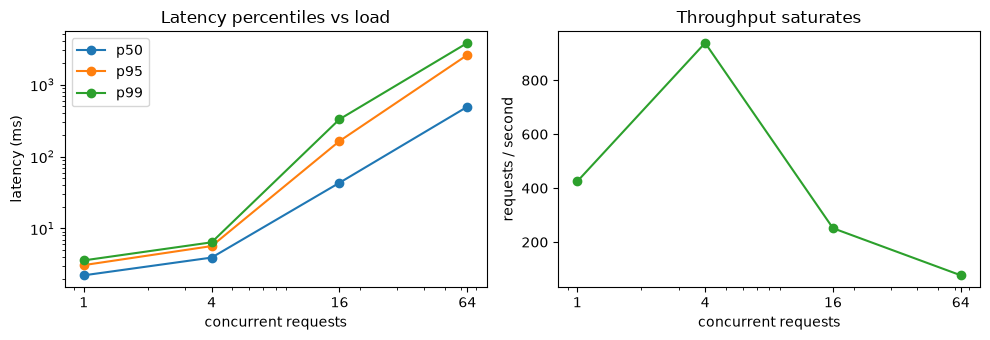

• p99 grew 1054× (from 3.6 ms at concurrency 1 to 3794.2 ms at 64).
• Throughput peaked at 938 req/s (concurrency 4); at 64 it was 77 req/s → past the peak, extra concurrency only adds queueing.
• At concurrency 64 the mean (774.6 ms) understates p99 (3794.2 ms) by 4.9×.


In [38]:
conc = [r["concurrency"] for r in load_results]
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3.5))
for key in ["p50_ms", "p95_ms", "p99_ms"]:
    ax1.plot(conc, [r[key] for r in load_results], marker="o", label=key.replace("_ms", ""))
ax1.set(xscale="log", yscale="log", xlabel="concurrent requests", ylabel="latency (ms)", title="Latency percentiles vs load")
ax1.set_xticks(conc, [str(c) for c in conc])
ax1.legend()
ax2.plot(conc, [r["rps"] for r in load_results], marker="o", color="tab:green")
ax2.set(xscale="log", xlabel="concurrent requests", ylabel="requests / second", title="Throughput saturates")
ax2.set_xticks(conc, [str(c) for c in conc])
plt.tight_layout()
plt.show()

low, high = load_results[0], load_results[-1]
best = max(load_results, key=lambda r: r["rps"])
assert sum(r["errors"] for r in load_results) == 0, "load test produced non-200 responses"
print(f"• p99 grew {high['p99_ms'] / low['p99_ms']:.0f}× (from {low['p99_ms']:.1f} ms at concurrency 1 to {high['p99_ms']:.1f} ms at {high['concurrency']}).")
print(f"• Throughput peaked at {best['rps']:.0f} req/s (concurrency {best['concurrency']}); at {high['concurrency']} it was {high['rps']:.0f} req/s "
      f"→ {'past the peak, extra concurrency only adds queueing' if high['rps'] < 1.2 * best['rps'] and best is not high else 'still scaling'}.")
print(f"• At concurrency {high['concurrency']} the mean ({high['mean_ms']:.1f} ms) understates p99 ({high['p99_ms']:.1f} ms) by {high['p99_ms'] / high['mean_ms']:.1f}×.")

**Measuring honestly:**
- Here the load generator and the server share one laptop's CPU, so the numbers are a *relative* picture. Real load tests run the client on a separate machine.
- This is a **closed-loop** test: a new request starts only when one finishes, so a slow server automatically receives less load. Real users arrive regardless (**open loop**). Closed-loop tools under-report the tail — this is called **coordinated omission**. Tools like k6, Locust, Vegeta, or oha can generate open-loop load at a fixed rate.
- Always report percentiles **with** the load (concurrency or request rate) and the hardware.

### ✍️ Your Turn

Implement the **nearest-rank** percentile: sort the values; the p-th percentile is the value at rank `ceil(p/100 × n)` (ranks start at 1).

In [39]:
def percentile_nearest_rank(values, p):
    return None  # TODO


sample_latencies = [12, 15, 11, 90, 13, 14, 12, 16, 13, 250]
got = None if percentile_nearest_rank(sample_latencies, 50) is None else [percentile_nearest_rank(sample_latencies, p) for p in (50, 90, 99)]
check("percentile_nearest_rank", got, [13, 90, 250], hint="ordered = sorted(values); return ordered[math.ceil(p / 100 * len(ordered)) - 1]")

⏳ percentile_nearest_rank: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
def percentile_nearest_rank(values, p):
    ordered = sorted(values)
    rank = max(1, math.ceil(p / 100 * len(ordered)))
    return ordered[rank - 1]

sample_latencies = [12, 15, 11, 90, 13, 14, 12, 16, 13, 250]
got = [percentile_nearest_rank(sample_latencies, p) for p in (50, 90, 99)]
check("percentile_nearest_rank", got, [13, 90, 250])
```

With only 10 samples, p99 is simply the maximum. You need hundreds of requests before p99 means anything. `np.percentile` interpolates between neighbours by default, so it can return values that never occurred.
</details>

> 💡 **Interview angle:** "Why p99 instead of average?" — averages hide the tail, and the tail is what users and fan-out services feel. Report p50/p95/p99 **at a stated load**, find the knee where throughput stops rising, and set capacity so normal traffic stays below it. Know the coordinated-omission caveat.

## 14. Production Layout and a Flask Comparison 🟢

Notebook cells are great for learning; a service lives in a small package with tests. The layout the mini project uses:

```
model_service/
├── app/
│   ├── __init__.py
│   ├── config.py      # settings from environment variables (12-factor config)
│   ├── schemas.py     # Pydantic request/response models
│   ├── model.py       # load the artifact + predict — no FastAPI imports, easy to unit-test
│   └── main.py        # the FastAPI app: lifespan, middleware, auth dependency, routes
├── model/             # model.joblib + metadata.json (or downloaded from a model registry at startup)
├── tests/
│   ├── conftest.py    # fixtures: TestClient with lifespan, auth headers
│   └── test_api.py
├── pyproject.toml     # pytest (and ruff) configuration
└── requirements.txt   # pinned runtime dependencies (the Docker image installs exactly these)
```

Production habits: version routes (`/v1/...`) so you can change the contract later; keep the model code independent of the web framework; read config from environment variables; log structured lines with request IDs; in containers, prefer **one uvicorn process per container** and scale with more containers (replicas), or use `--workers` on a single VM.

### Flask, compared fairly

**Flask** is the classic, minimal Python web framework, built on **WSGI** (the synchronous predecessor of ASGI). Plenty of model APIs still run on it. Here is the same iris endpoint in Flask 3.1:

In [40]:
import inspect

from flask import Flask
from flask import request as flask_request
from flask.cli import run_command


def validate_iris_payload(payload):
    """What Pydantic did for us in one class — written by hand."""
    if not isinstance(payload, dict):
        return ["body must be a JSON object"]
    errors = []
    for name in FEATURES:
        value = payload.get(name)
        if name not in payload:
            errors.append(f"{name}: field required")
        elif isinstance(value, bool) or not isinstance(value, (int, float)):
            errors.append(f"{name}: must be a number")
        elif not math.isfinite(value) or not 0 < value <= 15:
            errors.append(f"{name}: must be a finite number in (0, 15]")
    errors += [f"{name}: unexpected field" for name in payload if name not in FEATURES]
    if not errors and payload["petal_width"] > payload["petal_length"]:
        errors.append("petal_width cannot exceed petal_length")
    return errors


def create_flask_app(model_path):
    """The Flask 'application factory' pattern: build the app (and load the model) once."""
    flask_app = Flask("iris_flask")
    bundle = joblib.load(model_path)                 # loaded once per process, captured by the view functions

    @flask_app.get("/health")
    def flask_health():
        return {"status": "ok"}                      # returning a dict → Flask sends JSON

    @flask_app.post("/predict")
    def flask_predict():
        payload = flask_request.get_json(silent=True)   # None if the body isn't valid JSON
        errors = validate_iris_payload(payload)
        if errors:
            return {"detail": errors}, 422
        return predict_rows(bundle, [[float(payload[name]) for name in FEATURES]])[0]

    return flask_app


flask_app = create_flask_app(IRIS_MODEL_PATH)
flask_client = flask_app.test_client()

same = 0
with TestClient(mw_app) as fastapi_client:
    for row in X_te[:15]:
        payload = row_to_payload(row)
        same += flask_client.post("/predict", json=payload).get_json() == fastapi_client.post("/predict", json=payload).json()
    bad_payloads = [{}, {**good, "sepal_length": -1}, {**good, "extra": 1}, {**good, "sepal_width": True}, [good]]
    flask_codes = [flask_client.post("/predict", json=p).status_code for p in bad_payloads]
    fastapi_codes = [fastapi_client.post("/predict", json=p).status_code for p in bad_payloads]
    nan_codes = (flask_client.post("/predict", data=nan_body, content_type="application/json").status_code,
                 fastapi_client.post("/predict", content=nan_body, headers={"Content-Type": "application/json"}).status_code)

print(f"identical predictions from Flask and FastAPI: {same}/15")
print("bad inputs → Flask:", flask_codes, "| FastAPI:", fastapi_codes, "| NaN body (Flask, FastAPI):", nan_codes)
print("FastAPI 'true' for a float field:", "accepted (lax mode converts True → 1.0)" if fastapi_codes[3] == 200 else "rejected",
      "| our Flask validator:", "rejected" if flask_codes[3] == 422 else "accepted")

manual_lines = len(inspect.getsource(validate_iris_payload).splitlines())
print(f"\nhand-written validator: {manual_lines} lines of code and no API docs; "
      f"the Pydantic IrisFeatures class declares the same rules and also generates the OpenAPI schema")

identical predictions from Flask and FastAPI: 15/15
bad inputs → Flask: [422, 422, 422, 422, 422] | FastAPI: [422, 422, 422, 200, 422] | NaN body (Flask, FastAPI): (422, 422)
FastAPI 'true' for a float field: accepted (lax mode converts True → 1.0) | our Flask validator: rejected

hand-written validator: 17 lines of code and no API docs; the Pydantic IrisFeatures class declares the same rules and also generates the OpenAPI schema


In [41]:
# Facts about Flask 3.1 that older tutorials get wrong — checked against the installed version
health = flask_client.get("/health")
print(f"Flask {md.version('flask')}")
print("• returning a dict works → status", health.status_code, "| content-type", health.content_type)
print("• `flask run` uses threads by default (--with-threads):", next(p.default for p in run_command.params if p.name == "with_threads"))
print("• JSON key sorting is set with app.json.sort_keys (default", flask_app.json.sort_keys, ") — JSON_SORT_KEYS config key present:", "JSON_SORT_KEYS" in flask_app.config)
print("• @app.before_first_request still exists:", hasattr(flask_app, "before_first_request"), "(removed in Flask 2.3 — load resources in the app factory)")

Flask 3.1.3
• returning a dict works → status 200 | content-type application/json
• `flask run` uses threads by default (--with-threads): True
• JSON key sorting is set with app.json.sort_keys (default True ) — JSON_SORT_KEYS config key present: False
• @app.before_first_request still exists: False (removed in Flask 2.3 — load resources in the app factory)


| | **FastAPI** | **Flask** |
|---|---|---|
| Interface | ASGI (async-native) | WSGI (sync); `async def` views are supported via `asgiref`, but each one runs in its own event loop inside a worker thread — no concurrency gain |
| Validation | Pydantic from type hints → automatic 422s | by hand, or extensions (Marshmallow, flask-pydantic) |
| Docs | OpenAPI + `/docs` generated | extensions (flask-smorest, apispec) |
| Dev server | `fastapi dev` / `uvicorn --reload` | `flask run` (threaded by default; **not** for production) |
| Production server | uvicorn (optionally several workers), Hypercorn, Granian | Gunicorn, uWSGI, Waitress |
| Where state lives | `app.state` via lifespan | app factory / `app.extensions`; `g` is **per request** (wrong place for a model) |
| Best at | typed JSON APIs, streaming, many concurrent I/O calls (LLM gateways) | server-rendered web apps, huge extension ecosystem, existing codebases |

**Speed, honestly:** for a CPU-bound model, the model dominates latency in *both* frameworks, and neither `async` nor ASGI removes the GIL. FastAPI's real wins are validation, docs, and cheap concurrency when an endpoint mostly **waits** (calling an LLM API, a feature store, a database).

> 💡 **Interview angle:** "FastAPI or Flask for a new model service?" — FastAPI for typed JSON APIs: schema validation, generated docs, native async/streaming. Flask is fine for an existing codebase or server-rendered pages. Don't claim FastAPI makes CPU-bound inference faster; the model and the number of processes decide that.

## 🔧 Build It From Scratch

What does FastAPI actually do? Under all the decorators, a web app is **one async function** that follows the ASGI specification:

```python
async def app(scope, receive, send):
    # scope   : dict describing the connection — type ("http" / "lifespan"), method, path, headers
    # receive : await it to get incoming messages — request body chunks, disconnects, lifespan events
    # send    : await it to send outgoing messages — response start (status + headers), response body
```

We'll write the iris prediction route with **no framework**: parse the body, validate, predict, send JSON. Then we serve it with **uvicorn** and `assert` it returns exactly the same responses as the FastAPI `iris_api.py`.

In [42]:
RAW_DIR = OUTPUT_DIR / "raw_asgi"
write(RAW_DIR / "raw_app.py", '''
    """An iris prediction API written directly against the ASGI interface — no framework."""
    import json
    import math
    import os

    import joblib
    import numpy as np

    FEATURES = ["sepal_length", "sepal_width", "petal_length", "petal_width"]
    STATE = {}


    async def read_body(receive) -> bytes:
        """Bodies can arrive in several chunks: keep receiving until more_body is False."""
        body, more = b"", True
        while more:
            message = await receive()
            body += message.get("body", b"")
            more = message.get("more_body", False)
        return body


    async def send_json(send, status: int, payload) -> None:
        body = json.dumps(payload).encode()
        await send({"type": "http.response.start", "status": status,
                    "headers": [(b"content-type", b"application/json"), (b"content-length", str(len(body)).encode())]})
        await send({"type": "http.response.body", "body": body})


    def validate(payload) -> list[str]:
        if not isinstance(payload, dict):
            return ["body must be a JSON object"]
        errors = []
        for name in FEATURES:
            value = payload.get(name)
            if name not in payload:
                errors.append(f"{name}: field required")
            elif isinstance(value, bool) or not isinstance(value, (int, float)):
                errors.append(f"{name}: must be a number")
            elif not math.isfinite(value) or not 0 < value <= 15:
                errors.append(f"{name}: must be a finite number in (0, 15]")
        errors += [f"{name}: unexpected field" for name in payload if name not in FEATURES]
        if not errors and payload["petal_width"] > payload["petal_length"]:
            errors.append("petal_width cannot exceed petal_length")
        return errors


    async def lifespan(receive, send) -> None:
        while True:
            message = await receive()
            if message["type"] == "lifespan.startup":
                STATE["bundle"] = joblib.load(os.environ["IRIS_MODEL_PATH"])
                await send({"type": "lifespan.startup.complete"})
            elif message["type"] == "lifespan.shutdown":
                STATE.clear()
                await send({"type": "lifespan.shutdown.complete"})
                return


    async def app(scope, receive, send):
        if scope["type"] == "lifespan":
            return await lifespan(receive, send)
        if scope["type"] != "http":
            return
        path, method = scope["path"], scope["method"]
        if path == "/health":
            return await send_json(send, 200, {"status": "ok"}) if method == "GET" else await send_json(send, 405, {"detail": "Method Not Allowed"})
        if path != "/predict":
            return await send_json(send, 404, {"detail": "Not Found"})
        if method != "POST":
            return await send_json(send, 405, {"detail": "Method Not Allowed"})
        try:
            payload = json.loads(await read_body(receive))
        except (json.JSONDecodeError, UnicodeDecodeError):
            return await send_json(send, 422, {"detail": ["body is not valid JSON"]})
        errors = validate(payload)
        if errors:
            return await send_json(send, 422, {"detail": errors})
        bundle = STATE["bundle"]
        proba = bundle["model"].predict_proba(np.array([[float(payload[name]) for name in FEATURES]]))[0]
        await send_json(send, 200, {
            "species": bundle["classes"][int(proba.argmax())],
            "probabilities": {c: round(float(p), 4) for c, p in zip(bundle["classes"], proba)},
            "model_version": bundle["version"],
        })
''')

First, call the raw app **directly** with hand-made `scope`, `receive`, and `send`, so you can see the exact messages a server exchanges with an app:

In [43]:
import importlib.util

spec = importlib.util.spec_from_file_location("raw_app", RAW_DIR / "raw_app.py")
raw_app = importlib.util.module_from_spec(spec)
spec.loader.exec_module(raw_app)
raw_app.STATE["bundle"] = joblib.load(IRIS_MODEL_PATH)      # we skip the lifespan protocol for this direct call


async def call_asgi(app, method, path, body=b""):
    incoming = [{"type": "http.request", "body": body, "more_body": False}]
    sent = []

    async def receive():
        return incoming.pop(0) if incoming else {"type": "http.disconnect"}

    async def send(message):
        sent.append(message)

    scope = {"type": "http", "asgi": {"version": "3.0"}, "http_version": "1.1", "method": method, "path": path,
             "query_string": b"", "headers": [(b"content-type", b"application/json")]}
    await app(scope, receive, send)
    return sent


for message in await call_asgi(raw_app.app, "POST", "/predict", json.dumps(good).encode()):
    print(message)

{'type': 'http.response.start', 'status': 200, 'headers': [(b'content-type', b'application/json'), (b'content-length', b'132')]}
{'type': 'http.response.body', 'body': b'{"species": "setosa", "probabilities": {"setosa": 0.9787, "versicolor": 0.0213, "virginica": 0.0}, "model_version": "iris-logreg-1"}'}


Now serve **both** apps with uvicorn and compare real HTTP responses: 15 valid real test rows and 8 invalid requests.

In [44]:
valid_payloads = [row_to_payload(row) for row in X_te[:15]]
invalid_requests = [
    ("POST", "/predict", {"json": {"sepal_length": 5.1}}),
    ("POST", "/predict", {"json": {**good, "extra": 1}}),
    ("POST", "/predict", {"json": {**good, "sepal_length": -3}}),
    ("POST", "/predict", {"json": {**good, "petal_width": 9.0}}),
    ("POST", "/predict", {"content": nan_body, "headers": {"Content-Type": "application/json"}}),
    ("POST", "/predict", {"content": "{not json", "headers": {"Content-Type": "application/json"}}),
    ("GET", "/predict", {}),
    ("GET", "/nope", {}),
]

with UvicornServer("raw_app:app", cwd=RAW_DIR, env=IRIS_ENV, extra_args=["--no-access-log"]) as raw_server, \
     UvicornServer("iris_api:app", cwd=IRIS_SERVICE_DIR, env=IRIS_ENV, ready_path="/ready", extra_args=["--no-access-log"]) as fast_server:
    with httpx.Client(base_url=raw_server.base_url) as raw_http, httpx.Client(base_url=fast_server.base_url) as fast_http:
        for payload in valid_payloads:
            raw_response, fast_response = raw_http.post("/predict", json=payload), fast_http.post("/predict", json=payload)
            assert raw_response.status_code == fast_response.status_code == 200
            assert raw_response.json() == fast_response.json(), (raw_response.json(), fast_response.json())
        for method, path, kwargs in invalid_requests:
            raw_code, fast_code = raw_http.request(method, path, **kwargs).status_code, fast_http.request(method, path, **kwargs).status_code
            assert raw_code == fast_code, f"{method} {path} {kwargs}: raw {raw_code} vs FastAPI {fast_code}"
            print(f"{method:4} {path:9} {str(kwargs)[:60]:62} → both {raw_code}")

        def median_ms(http_client, n=300):
            times = []
            for i in range(n):
                start = time.perf_counter()
                http_client.post("/predict", json=valid_payloads[i % len(valid_payloads)])
                times.append((time.perf_counter() - start) * 1000)
            return float(np.median(times))

        raw_ms, fast_ms = median_ms(raw_http), median_ms(fast_http)

print(f"\n✅ raw ASGI app matches FastAPI on {len(valid_payloads)} predictions (identical JSON) and {len(invalid_requests)} error cases")
print(f"median latency over real HTTP: raw ASGI {raw_ms:.2f} ms vs FastAPI {fast_ms:.2f} ms "
      f"→ the framework adds ~{fast_ms - raw_ms:.2f} ms per request here (validation, routing, serialization)")

POST /predict  {'json': {'sepal_length': 5.1}}                                → both 422
POST /predict  {'json': {'sepal_length': 5.1, 'sepal_width': 3.5, 'petal_le   → both 422
POST /predict  {'json': {'sepal_length': -3, 'sepal_width': 3.5, 'petal_len   → both 422
POST /predict  {'json': {'sepal_length': 5.1, 'sepal_width': 3.5, 'petal_le   → both 422
POST /predict  {'content': '{"sepal_length": NaN, "sepal_width": 3.5, "peta   → both 422
POST /predict  {'content': '{not json', 'headers': {'Content-Type': 'applic   → both 422
GET  /predict  {}                                                             → both 405
GET  /nope     {}                                                             → both 404



✅ raw ASGI app matches FastAPI on 15 predictions (identical JSON) and 8 error cases
median latency over real HTTP: raw ASGI 1.83 ms vs FastAPI 2.86 ms → the framework adds ~1.02 ms per request here (validation, routing, serialization)


**What you just learned by building it:** routing is `if` on `scope["path"]` and `scope["method"]`; a body can arrive in chunks; a response is two messages (start + body); the lifespan is a small message protocol. FastAPI (via Starlette) adds routing tables, dependency injection, Pydantic validation, OpenAPI generation, and error handling on top. That costs some microseconds, and saves weeks of hand-written validation like the ~20 lines above.

## ⚠️ Common Pitfalls

### ❌ Pitfall 1 — Returning NumPy types

In [45]:
np_app = FastAPI()


@np_app.get("/wrong")
def wrong_type():
    prediction = iris_model.predict(X_te[:1])[0]
    return {"class_id": prediction}                     # ❌ numpy.int64 is not a Python int


@np_app.get("/right")
def right_type():
    prediction = iris_model.predict(X_te[:1])[0]
    return {"class_id": int(prediction)}                # ✅ convert (or declare a response_model with `int`)


print("type from sklearn:", type(iris_model.predict(X_te[:1])[0]).__name__)
print("❌ /wrong →", TestClient(np_app, raise_server_exceptions=False).get("/wrong").status_code)
try:
    TestClient(np_app).get("/wrong")
except Exception as err:                                  # noqa: BLE001
    print("   server error:", type(err).__name__, "—", str(err).splitlines()[0][:90])
print("✅ /right →", TestClient(np_app).get("/right").json())

type from sklearn: int64
❌ /wrong → 500
   server error: ValueError — [TypeError("'numpy.int64' object is not iterable"), TypeError('vars() argument must have _
✅ /right → {'class_id': 2}


### ❌ Pitfall 2 — Creating `TestClient` without `with` (the lifespan never runs)

In [46]:
client_without_with = TestClient(lifespan_app)          # ❌ no startup → no model
response = client_without_with.post("/predict", json=good)
print("❌ without `with`:", response.status_code, response.json())

with TestClient(lifespan_app) as client_with:            # ✅ startup runs, model loaded
    response = client_with.post("/predict", json=good)
print("✅ with `with`   :", response.status_code, response.json()["species"])

❌ without `with`: 503 {'detail': 'Model not loaded'}
INFO model_api: startup: model iris-forest-1 loaded in 43 ms


INFO model_api: shutdown: model released


✅ with `with`   : 200 setosa


### ❌ Pitfall 3 — Default values that silently hide client mistakes

A client misspells `petal_length`. A schema with defaults and ignored extras quietly fills in a "typical" value and answers with **200 OK**. Nobody is told the input was wrong.

In [47]:
class LooseFeatures(BaseModel):          # ❌ defaults + unknown fields silently ignored (Pydantic's default)
    sepal_length: float = 5.8
    sepal_width: float = 3.0
    petal_length: float = 3.8
    petal_width: float = 1.2


FLOWER = 0
real_flower = row_to_payload(X_iris[FLOWER])                        # a real setosa: petal_length 1.4 cm
typo_payload = {("petal_lenght" if k == "petal_length" else k): v for k, v in real_flower.items()}

truth = predict_rows(MODELS["iris-logreg-1"], [list(real_flower.values())])[0]
loose = LooseFeatures.model_validate(typo_payload)
wrong = predict_rows(MODELS["iris-logreg-1"], [[getattr(loose, f) for f in FEATURES]])[0]
print("true species          :", flowers.loc[FLOWER, "species"])
print("correct payload       :", truth["species"], truth["probabilities"])
print(f"❌ typo + defaults     : {wrong['species']} {wrong['probabilities']} ← used petal_length={loose.petal_length}, status would be 200")
print("   species changed by the typo:", "YES — a wrong answer nobody notices" if wrong["species"] != truth["species"]
      else f"no, but P({truth['species']}) moved {truth['probabilities'][truth['species']]:.3f} → {wrong['probabilities'][truth['species']]:.3f}")
try:
    IrisFeatures.model_validate(typo_payload)                       # ✅ required fields + extra="forbid"
except ValidationError as err:
    print("✅ strict schema → 422:", [e["msg"] for e in err.errors()])

true species          : setosa
correct payload       : setosa {'setosa': 0.9787, 'versicolor': 0.0213, 'virginica': 0.0}
❌ typo + defaults     : setosa {'setosa': 0.8439, 'versicolor': 0.156, 'virginica': 0.0001} ← used petal_length=3.8, status would be 200
   species changed by the typo: no, but P(setosa) moved 0.979 → 0.844
✅ strict schema → 422: ['Field required', 'Extra inputs are not permitted']


### ❌ Pitfall 4 — Logging raw request bodies

In [48]:
log_capture = io.StringIO()
audit = logging.getLogger("audit_demo")
audit.setLevel(logging.INFO)
audit.addHandler(logging.StreamHandler(log_capture))
audit.propagate = False

request_body = {"email": "jane.doe@example.com", "text": "My card 4111 1111 1111 1111 was charged twice"}
audit.info("❌ predict body=%s", request_body)                                   # PII now lives in every log system
digest = hashlib.sha256(json.dumps(request_body, sort_keys=True).encode()).hexdigest()[:12]
audit.info("✅ predict request_id=%s fields=%s body_sha256=%s text_chars=%d",
           uuid.uuid4().hex[:8], sorted(request_body), digest, len(request_body["text"]))
print(log_capture.getvalue())

❌ predict body={'email': 'jane.doe@example.com', 'text': 'My card 4111 1111 1111 1111 was charged twice'}
✅ predict request_id=f8edd809 fields=['email', 'text'] body_sha256=5c84d9a22bec text_chars=45



The ✅ line still lets you debug (which fields, how big, a hash to match duplicates, a request ID to join with other logs) without copying emails and card numbers into log storage, where they are hard to delete.

### ❌ Pitfall 5 — Unbounded in-memory state

In [49]:
import tracemalloc


def memory_after(container, n=50_000):
    tracemalloc.start()
    for i in range(n):
        container.append({"request_id": uuid.uuid4().hex, "species": "setosa", "latency_ms": 1.0})
    current, _ = tracemalloc.get_traced_memory()
    tracemalloc.stop()
    return len(container), current / 1e6


n_list, mb_list = memory_after([])                     # ❌ grows with every request, forever
n_deque, mb_deque = memory_after(deque(maxlen=1000))   # ✅ bounded
print(f"❌ list  after 50,000 requests: {n_list:,} entries, ~{mb_list:.1f} MB (and still growing)")
print(f"✅ deque after 50,000 requests: {n_deque:,} entries, ~{mb_deque:.2f} MB (flat)")
print("Also: each worker process has its OWN copy, so an in-memory log shows only that worker's requests.")

❌ list  after 50,000 requests: 50,000 entries, ~13.3 MB (and still growing)
✅ deque after 50,000 requests: 1,000 entries, ~0.25 MB (flat)
Also: each worker process has its OWN copy, so an in-memory log shows only that worker's requests.


## 🏋️ Practice Exercises

Try each one before opening the solution. Run the cell: ⏳ means not attempted, ✅ means correct.

### 🟢 Exercise 1 — A schema for a sentiment model
Define `SentimentRequest` with:
- `text`: 1 to 280 characters, **stripped** of surrounding whitespace, and rejected if it is blank after stripping
- `language`: `"en"` or `"es"`, default `"en"`
- unknown fields forbidden

In [50]:
sentiment_payloads = [
    {"text": "love it"},
    {"text": "   "},
    {"text": "x" * 281},
    {"text": "hola", "language": "es"},
    {"text": "bonjour", "language": "fr"},
    {"text": "ok", "user_email": "a@b.c"},
]
SentimentRequest = None  # TODO: replace with `class SentimentRequest(BaseModel): ...`
result = None if SentimentRequest is None else [is_valid(SentimentRequest, p) for p in sentiment_payloads] + [SentimentRequest(text="  hi  ").text]
check("sentiment_request", result, [True, False, False, True, False, False, "hi"],
      hint="Field(min_length=1, max_length=280), Literal['en', 'es'] = 'en', a @field_validator that strips, extra='forbid'.")

⏳ sentiment_request: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
class SentimentRequest(BaseModel):
    model_config = ConfigDict(extra="forbid")
    text: str = Field(min_length=1, max_length=280)
    language: Literal["en", "es"] = "en"

    @field_validator("text")
    @classmethod
    def strip_text(cls, value: str) -> str:
        if not value.strip():
            raise ValueError("text must not be blank")
        return value.strip()

sentiment_payloads = [
    {"text": "love it"}, {"text": "   "}, {"text": "x" * 281},
    {"text": "hola", "language": "es"}, {"text": "bonjour", "language": "fr"}, {"text": "ok", "user_email": "a@b.c"},
]
result = [is_valid(SentimentRequest, p) for p in sentiment_payloads] + [SentimentRequest(text="  hi  ").text]
check("sentiment_request", result, [True, False, False, True, False, False, "hi"])
```
</details>

### 🟢 Exercise 2 — Path parameters with bounds
Build `square_app` with **`GET /square/{n}`** returning `{"n": n, "square": n * n}`, where `n` is an integer from 0 to 1000.

In [51]:
square_app = None  # TODO
check_routes("square", square_app, [
    {"path": "/square/12", "status": 200, "expect_json": {"n": 12, "square": 144}},
    {"path": "/square/-1", "status": 422},
    {"path": "/square/abc", "status": 422},
    {"path": "/square/1001", "status": 422},
], hint="n: Annotated[int, PathParam(ge=0, le=1000)]")

⏳ square: not attempted yet — build the app first.


<details><summary>💡 Show solution</summary>

```python
square_app = FastAPI()

@square_app.get("/square/{n}")
def square(n: Annotated[int, PathParam(ge=0, le=1000)]):
    return {"n": n, "square": n * n}

check_routes("square", square_app, [
    {"path": "/square/12", "status": 200, "expect_json": {"n": 12, "square": 144}},
    {"path": "/square/-1", "status": 422},
    {"path": "/square/abc", "status": 422},
    {"path": "/square/1001", "status": 422},
])
```
</details>

### 🟢 Exercise 3 — A readiness endpoint
Build `ready_app` with **`GET /ready`**: if `app.state.model` is `None`, return **503** with JSON `{"status": "loading"}`; otherwise **200** with `{"status": "ready"}`. (Hint: `HTTPException` would wrap your message in `{"detail": ...}` — return a `JSONResponse` instead.)

In [52]:
def probe_readiness(app):
    """Flip app.state.model and record what /ready says each time."""
    if app is None:
        return None
    with TestClient(app) as test_client:
        app.state.model = None
        loading = test_client.get("/ready")
        app.state.model = "a loaded model"
        loaded = test_client.get("/ready")
    return [loading.status_code, loading.json(), loaded.status_code, loaded.json()]

In [53]:
ready_app = None  # TODO
check("readiness", probe_readiness(ready_app), [503, {"status": "loading"}, 200, {"status": "ready"}],
      hint="def ready(request: Request): read getattr(request.app.state, 'model', None)")

⏳ readiness: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
ready_app = FastAPI()

@ready_app.get("/ready")
def ready_probe(request: Request):
    if getattr(request.app.state, "model", None) is None:
        return JSONResponse(status_code=503, content={"status": "loading"})
    return {"status": "ready"}

check("readiness", probe_readiness(ready_app), [503, {"status": "loading"}, 200, {"status": "ready"}])
```
</details>

### 🟡 Exercise 4 — A safe batch endpoint
Build `sum_app` with **`POST /batch/sum`**. The body is `{"rows": [[a, b, c], ...]}` with **1 to 5 rows**, each **exactly 3 numbers**. Return `{"sums": [a+b+c, ...]}`. Every invalid body must be a **422**, never a 500.

In [54]:
sum_app = None  # TODO
check_routes("batch_sum", sum_app, [
    {"method": "POST", "path": "/batch/sum", "json": {"rows": [[1, 2, 3], [0.5, 0.5, 1]]}, "status": 200, "expect_json": {"sums": [6.0, 2.0]}},
    {"method": "POST", "path": "/batch/sum", "json": {"rows": []}, "status": 422},
    {"method": "POST", "path": "/batch/sum", "json": {"rows": [[1, 2, 3]] * 6}, "status": 422},
    {"method": "POST", "path": "/batch/sum", "json": {"rows": [[1, 2]]}, "status": 422},
    {"method": "POST", "path": "/batch/sum", "json": {"rows": [[1, 2, "x"]]}, "status": 422},
    {"method": "POST", "path": "/batch/sum", "json": {"data": [[1, 2, 3]]}, "status": 422},
], hint="rows: list[Annotated[list[float], Field(min_length=3, max_length=3)]] = Field(min_length=1, max_length=5)")

⏳ batch_sum: not attempted yet — build the app first.


<details><summary>💡 Show solution</summary>

```python
class SumRequest(BaseModel):
    model_config = ConfigDict(extra="forbid")
    rows: list[Annotated[list[float], Field(min_length=3, max_length=3)]] = Field(min_length=1, max_length=5)

sum_app = FastAPI()

@sum_app.post("/batch/sum")
def batch_sum(body: SumRequest):
    return {"sums": [sum(row) for row in body.rows]}

check_routes("batch_sum", sum_app, [
    {"method": "POST", "path": "/batch/sum", "json": {"rows": [[1, 2, 3], [0.5, 0.5, 1]]}, "status": 200, "expect_json": {"sums": [6.0, 2.0]}},
    {"method": "POST", "path": "/batch/sum", "json": {"rows": []}, "status": 422},
    {"method": "POST", "path": "/batch/sum", "json": {"rows": [[1, 2, 3]] * 6}, "status": 422},
    {"method": "POST", "path": "/batch/sum", "json": {"rows": [[1, 2]]}, "status": 422},
    {"method": "POST", "path": "/batch/sum", "json": {"rows": [[1, 2, "x"]]}, "status": 422},
    {"method": "POST", "path": "/batch/sum", "json": {"data": [[1, 2, 3]]}, "status": 422},
])
```
</details>

### 🟡 Exercise 5 — Roles with dependencies (401 vs 403)
Build `roles_app` using the keys in `ROLE_KEYS`:
- a dependency that reads the **`X-API-Key`** header and returns the role, or raises **401** if the key is missing/unknown
- **`GET /models`** (any role) returns `{"role": <role>}`
- **`DELETE /models/{name}`** (admin only) returns `{"deleted": name}`; a valid non-admin key gets **403**

In [55]:
ROLE_KEYS = {"key-reader-123": "reader", "key-admin-456": "admin"}
roles_app = None  # TODO
check_routes("roles", roles_app, [
    {"path": "/models", "status": 401},
    {"path": "/models", "headers": {"X-API-Key": "nope"}, "status": 401},
    {"path": "/models", "headers": {"X-API-Key": "key-reader-123"}, "status": 200, "expect_json": {"role": "reader"}},
    {"method": "DELETE", "path": "/models/iris", "headers": {"X-API-Key": "key-reader-123"}, "status": 403},
    {"method": "DELETE", "path": "/models/iris", "headers": {"X-API-Key": "key-admin-456"}, "status": 200, "expect_json": {"deleted": "iris"}},
], hint="get_role depends on APIKeyHeader(auto_error=False); require_admin depends on get_role and raises 403.")

⏳ roles: not attempted yet — build the app first.


<details><summary>💡 Show solution</summary>

```python
ROLE_KEYS = {"key-reader-123": "reader", "key-admin-456": "admin"}
roles_app = FastAPI()
role_key_header = APIKeyHeader(name="X-API-Key", auto_error=False)

def get_role(api_key: Annotated[str | None, Security(role_key_header)]) -> str:
    for key, role in ROLE_KEYS.items():
        if api_key is not None and secrets.compare_digest(api_key.encode(), key.encode()):
            return role
    raise HTTPException(status_code=401, detail="Invalid or missing API key")

def require_admin(role: Annotated[str, Depends(get_role)]) -> str:
    if role != "admin":
        raise HTTPException(status_code=403, detail="Admin role required")
    return role

@roles_app.get("/models")
def list_models(role: Annotated[str, Depends(get_role)]):
    return {"role": role}

@roles_app.delete("/models/{name}", dependencies=[Depends(require_admin)])
def delete_model(name: str):
    return {"deleted": name}

check_routes("roles", roles_app, [
    {"path": "/models", "status": 401},
    {"path": "/models", "headers": {"X-API-Key": "nope"}, "status": 401},
    {"path": "/models", "headers": {"X-API-Key": "key-reader-123"}, "status": 200, "expect_json": {"role": "reader"}},
    {"method": "DELETE", "path": "/models/iris", "headers": {"X-API-Key": "key-reader-123"}, "status": 403},
    {"method": "DELETE", "path": "/models/iris", "headers": {"X-API-Key": "key-admin-456"}, "status": 200, "expect_json": {"deleted": "iris"}},
])
```

Dependencies compose: `require_admin` reuses `get_role`, and FastAPI evaluates `get_role` only once per request.
</details>

### 🔴 Exercise 6 — Token-bucket rate limiter (interview classic)
Implement `TokenBucket(capacity, rate, clock=time.monotonic)`:
- it starts **full** with `capacity` tokens and refills continuously at `rate` tokens per second, never above `capacity`
- `allow()` spends one token and returns `True`, or returns `False` if less than one token is available
- `retry_after()` returns the seconds until one token will be available (`0.0` if one is available now)

The checker drives it with a fake clock, then plugs it into a FastAPI dependency (one bucket per API key) that returns **429 + `Retry-After`**.

In [56]:
class FakeClock:
    """A clock you move by hand, so rate-limit tests are instant and deterministic."""

    def __init__(self):
        self.now = 0.0

    def __call__(self):
        return self.now

    def advance(self, seconds):
        self.now += seconds


def probe_token_bucket(bucket_cls):
    if bucket_cls is None:
        return None
    clock = FakeClock()
    bucket = bucket_cls(capacity=3, rate=1.0, clock=clock)
    burst = [bucket.allow() for _ in range(5)]
    wait = round(bucket.retry_after(), 3)
    clock.advance(0.5)
    half = bucket.allow()
    clock.advance(0.5)
    one = bucket.allow()
    clock.advance(10)
    refill = [bucket.allow() for _ in range(4)]

    buckets, api_clock = {}, FakeClock()
    limited_app = FastAPI()

    def per_key_limit(x_api_key: Annotated[str, Header()]):
        key_bucket = buckets.setdefault(x_api_key, bucket_cls(capacity=2, rate=0.5, clock=api_clock))
        if not key_bucket.allow():
            raise HTTPException(status_code=429, detail="rate limited", headers={"Retry-After": str(math.ceil(key_bucket.retry_after()))})

    @limited_app.get("/predict", dependencies=[Depends(per_key_limit)])
    def limited_predict():
        return {"ok": True}

    with TestClient(limited_app) as test_client:
        codes = [test_client.get("/predict", headers={"X-API-Key": "a"}).status_code for _ in range(3)]
        retry_header = test_client.get("/predict", headers={"X-API-Key": "a"}).headers.get("retry-after")
        other_key = test_client.get("/predict", headers={"X-API-Key": "b"}).status_code
    return {"burst": burst, "retry_after": wait, "half_token": half, "one_token": one, "refill_capped": refill,
            "http_codes": codes, "retry_header": retry_header, "other_key": other_key}


TOKEN_BUCKET_EXPECTED = {"burst": [True, True, True, False, False], "retry_after": 1.0, "half_token": False, "one_token": True,
                         "refill_capped": [True, True, True, False], "http_codes": [200, 200, 429], "retry_header": "2", "other_key": 200}

In [57]:
TokenBucket = None  # TODO: replace with `class TokenBucket: ...`
check("token_bucket", probe_token_bucket(TokenBucket), TOKEN_BUCKET_EXPECTED,
      hint="On every call: tokens = min(capacity, tokens + elapsed * rate); remember the time of the last refill.")

⏳ token_bucket: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
class TokenBucket:
    def __init__(self, capacity, rate, clock=time.monotonic):
        self.capacity, self.rate, self.clock = float(capacity), float(rate), clock
        self.tokens = float(capacity)
        self.updated = clock()

    def _refill(self):
        now = self.clock()
        self.tokens = min(self.capacity, self.tokens + (now - self.updated) * self.rate)
        self.updated = now

    def allow(self) -> bool:
        self._refill()
        if self.tokens >= 1:
            self.tokens -= 1
            return True
        return False

    def retry_after(self) -> float:
        self._refill()
        return max(0.0, (1 - self.tokens) / self.rate)

check("token_bucket", probe_token_bucket(TokenBucket), TOKEN_BUCKET_EXPECTED)
```

**Talking points:** a token bucket allows short **bursts** (up to `capacity`) while enforcing an average `rate`, unlike a fixed window, which lets 2× the limit through at a window boundary. It needs O(1) memory per client. For several workers or replicas, keep the bucket state in Redis and update it atomically (a Lua script), or enforce limits at the API gateway.
</details>

## 🚀 Mini Project: California Housing Price Service

**Goal:** ship a real model service. Train a scikit-learn model on the **California Housing** dataset (20,640 real census block groups), save it with metadata, write a production-style FastAPI service to `_outputs/model_service/`, prove it with pytest, run it under uvicorn, send real requests, and load-test it — reporting p50/p95/p99 latency and throughput with conclusions computed from the measurements.

**Steps:** train and evaluate without leakage → persist the model and metadata → write the service → run the tests → start the server and call it → load test → shut down gracefully → conclusions.

### Step 1 — Train and evaluate (validation for choices, test set touched once)

In [58]:
from sklearn.datasets import fetch_california_housing
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, r2_score

housing = fetch_california_housing(as_frame=True)
HOUSING_FEATURES = list(housing.feature_names)
X_all, y_all = housing.data.to_numpy(), housing.target.to_numpy()       # target: median house value in $100,000s
print(f"{X_all.shape[0]:,} rows | features: {HOUSING_FEATURES}")

X_trval, X_test_h, y_trval, y_test_h = train_test_split(X_all, y_all, test_size=0.2, random_state=SEED)
X_train_h, X_val_h, y_train_h, y_val_h = train_test_split(X_trval, y_trval, test_size=0.25, random_state=SEED)
print(f"train {len(X_train_h):,} | validation {len(X_val_h):,} | test {len(X_test_h):,}")

val_mae = {}
for leaves in [15, 31, 63]:
    candidate = HistGradientBoostingRegressor(max_leaf_nodes=leaves, max_iter=300, random_state=SEED).fit(X_train_h, y_train_h)
    val_mae[leaves] = mean_absolute_error(y_val_h, candidate.predict(X_val_h))
    print(f"  max_leaf_nodes={leaves:2d} → validation MAE {val_mae[leaves]:.4f}")
best_leaves = min(val_mae, key=val_mae.get)

housing_model = HistGradientBoostingRegressor(max_leaf_nodes=best_leaves, max_iter=300, random_state=SEED).fit(X_trval, y_trval)
test_pred = housing_model.predict(X_test_h)
test_mae, test_r2 = mean_absolute_error(y_test_h, test_pred), r2_score(y_test_h, test_pred)
baseline_mae = mean_absolute_error(y_test_h, np.full_like(y_test_h, y_trval.mean()))
print(f"chosen max_leaf_nodes={best_leaves} (lowest validation MAE), refit on train+validation")
print(f"TEST: MAE {test_mae:.3f} (≈ ${test_mae * 100_000:,.0f}) | R² {test_r2:.3f} | predict-the-mean baseline MAE {baseline_mae:.3f}")
assert test_mae < baseline_mae

20,640 rows | features: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
train 12,384 | validation 4,128 | test 4,128


  max_leaf_nodes=15 → validation MAE 0.3251


  max_leaf_nodes=31 → validation MAE 0.3109


  max_leaf_nodes=63 → validation MAE 0.3151


chosen max_leaf_nodes=31 (lowest validation MAE), refit on train+validation
TEST: MAE 0.302 (≈ $30,154) | R² 0.843 | predict-the-mean baseline MAE 0.906


### Step 2 — Persist the model with metadata

The artifact alone isn't enough to operate a model. We also save its version, feature order, library version, metrics, and the **training ranges** of each feature, so the API can flag inputs the model never saw.

In [59]:
PROJECT_DIR = OUTPUT_DIR / "model_service"
MODEL_DIR = PROJECT_DIR / "model"
MODEL_DIR.mkdir(parents=True, exist_ok=True)
joblib.dump(housing_model, MODEL_DIR / "model.joblib")

housing_metadata = {
    "model_version": "housing-hgb-1.0.0",
    "features": HOUSING_FEATURES,
    "target": "median house value in $100,000s",
    "sklearn_version": md.version("scikit-learn"),
    "trained_at_utc": datetime.now(timezone.utc).isoformat(timespec="seconds"),
    "hyperparameters": {"max_leaf_nodes": best_leaves, "max_iter": 300},
    "metrics": {"val_mae": round(val_mae[best_leaves], 4), "test_mae": round(test_mae, 4), "test_r2": round(test_r2, 4),
                "baseline_test_mae": round(baseline_mae, 4)},
    "training_ranges": {name: [float(X_trval[:, i].min()), float(X_trval[:, i].max())] for i, name in enumerate(HOUSING_FEATURES)},
}
(MODEL_DIR / "metadata.json").write_text(json.dumps(housing_metadata, indent=2))

samples = [{"features": dict(zip(HOUSING_FEATURES, map(float, row))), "expected": round(float(pred), 4)}
           for row, pred in zip(X_test_h[:20], housing_model.predict(X_test_h[:20]))]
write(PROJECT_DIR / "tests" / "fixtures" / "samples.json", json.dumps(samples, indent=1))
print(f"model.joblib {(MODEL_DIR / 'model.joblib').stat().st_size / 1e6:.2f} MB | metadata keys: {list(housing_metadata)}")
print("20 real test rows + offline predictions saved for parity tests")

model.joblib 0.60 MB | metadata keys: ['model_version', 'features', 'target', 'sklearn_version', 'trained_at_utc', 'hyperparameters', 'metrics', 'training_ranges']
20 real test rows + offline predictions saved for parity tests


### Step 3 — Write the service

Four small modules: configuration, schemas, model logic (no FastAPI imports), and the app.

In [60]:
write(PROJECT_DIR / "app" / "__init__.py", "")

write(PROJECT_DIR / "app" / "config.py", '''
    """Settings come from environment variables, so the same code runs locally, in CI, and in a container."""
    import os
    from dataclasses import dataclass
    from functools import lru_cache
    from pathlib import Path


    @dataclass(frozen=True)
    class Settings:
        model_dir: Path
        api_keys: frozenset[str]
        max_body_bytes: int


    @lru_cache
    def get_settings() -> Settings:
        keys = os.environ.get("API_KEYS", "")
        return Settings(
            model_dir=Path(os.environ.get("MODEL_DIR", "model")),
            api_keys=frozenset(key.strip() for key in keys.split(",") if key.strip()),
            max_body_bytes=int(os.environ.get("MAX_BODY_BYTES", "1000000")),
        )
''')

write(PROJECT_DIR / "app" / "schemas.py", '''
    """Request/response contracts. Bounds describe physically plausible values, wider than the training data."""
    from pydantic import BaseModel, ConfigDict, Field

    MAX_BATCH_SIZE = 256


    class HouseFeatures(BaseModel):
        """One California census block group (the 8 features of the California Housing dataset)."""

        model_config = ConfigDict(
            extra="forbid",
            json_schema_extra={"examples": [{"MedInc": 8.3252, "HouseAge": 41.0, "AveRooms": 6.984, "AveBedrms": 1.024,
                                             "Population": 322.0, "AveOccup": 2.556, "Latitude": 37.88, "Longitude": -122.23}]},
        )

        MedInc: float = Field(gt=0, le=25, allow_inf_nan=False, description="Median income in the block group ($10,000s)")
        HouseAge: float = Field(ge=0, le=100, allow_inf_nan=False, description="Median house age (years)")
        AveRooms: float = Field(gt=0, le=200, allow_inf_nan=False, description="Average rooms per household")
        AveBedrms: float = Field(gt=0, le=50, allow_inf_nan=False, description="Average bedrooms per household")
        Population: float = Field(ge=1, le=100_000, allow_inf_nan=False, description="Block group population")
        AveOccup: float = Field(gt=0, le=2000, allow_inf_nan=False, description="Average household size")
        Latitude: float = Field(ge=32, le=42.5, allow_inf_nan=False, description="Latitude (California)")
        Longitude: float = Field(ge=-125, le=-114, allow_inf_nan=False, description="Longitude (California)")


    class BatchRequest(BaseModel):
        model_config = ConfigDict(extra="forbid")
        rows: list[HouseFeatures] = Field(min_length=1, max_length=MAX_BATCH_SIZE)


    class Prediction(BaseModel):
        median_house_value: float = Field(description="Predicted median house value in $100,000s")
        median_house_value_usd: int
        out_of_range_features: list[str] = Field(description="Features outside the training range: use the prediction with care")


    class PredictionResponse(Prediction):
        model_version: str


    class BatchResponse(BaseModel):
        model_version: str
        n: int
        predictions: list[Prediction]
''')

write(PROJECT_DIR / "app" / "model.py", '''
    """Model loading and prediction, independent of the web framework (easy to unit-test)."""
    import json
    import logging
    from dataclasses import dataclass
    from importlib.metadata import version
    from pathlib import Path

    import joblib
    import numpy as np

    logger = logging.getLogger("uvicorn.error")


    @dataclass
    class ModelService:
        model: object
        metadata: dict

        @classmethod
        def load(cls, model_dir: Path) -> "ModelService":
            metadata = json.loads((Path(model_dir) / "metadata.json").read_text())
            if metadata["sklearn_version"] != version("scikit-learn"):
                logger.warning("model trained with scikit-learn %s but running %s", metadata["sklearn_version"], version("scikit-learn"))
            return cls(model=joblib.load(Path(model_dir) / "model.joblib"), metadata=metadata)

        @property
        def version(self) -> str:
            return self.metadata["model_version"]

        @property
        def features(self) -> list[str]:
            return self.metadata["features"]

        def predict(self, rows: list[dict]) -> list[dict]:
            X = np.array([[row[name] for name in self.features] for row in rows], dtype=float)   # training column order
            ranges = self.metadata["training_ranges"]
            return [
                {
                    "median_house_value": round(float(value), 4),
                    "median_house_value_usd": int(round(float(value) * 100_000, -2)),
                    "out_of_range_features": [n for n in self.features if not ranges[n][0] <= row[n] <= ranges[n][1]],
                }
                for row, value in zip(rows, self.model.predict(X))
            ]
''')

write(PROJECT_DIR / "app" / "main.py", '''
    """California Housing price service: lifespan loading, API-key auth, validation, health and readiness."""
    import logging
    import re
    import secrets
    import time
    import uuid
    from contextlib import asynccontextmanager
    from typing import Annotated

    from fastapi import APIRouter, Depends, FastAPI, HTTPException, Request, Security
    from fastapi.exceptions import RequestValidationError
    from fastapi.responses import JSONResponse
    from fastapi.security import APIKeyHeader

    from app.config import Settings, get_settings
    from app.model import ModelService
    from app.schemas import BatchRequest, BatchResponse, HouseFeatures, PredictionResponse

    logger = logging.getLogger("uvicorn.error")
    REQUEST_ID_RE = re.compile(r"[A-Za-z0-9-]{8,64}")


    @asynccontextmanager
    async def lifespan(app: FastAPI):
        settings = get_settings()
        start = time.perf_counter()
        app.state.model = ModelService.load(settings.model_dir)
        logger.info("loaded model %s in %.0f ms", app.state.model.version, (time.perf_counter() - start) * 1000)
        if not settings.api_keys:
            logger.warning("API_KEYS is empty: every /v1 request will be rejected with 401")
        yield
        app.state.model = None
        logger.info("model unloaded")


    app = FastAPI(title="California Housing Price Service", version="1.0.0", lifespan=lifespan)


    @app.middleware("http")
    async def request_context(request: Request, call_next):
        declared = request.headers.get("content-length")
        if declared is not None and (not declared.isdigit() or int(declared) > get_settings().max_body_bytes):
            return JSONResponse(status_code=413, content={"detail": "Request body too large"})
        incoming = request.headers.get("x-request-id", "")
        request_id = incoming if REQUEST_ID_RE.fullmatch(incoming) else uuid.uuid4().hex
        start = time.perf_counter()
        response = await call_next(request)
        response.headers["X-Request-ID"] = request_id
        response.headers["X-Process-Time-Ms"] = f"{(time.perf_counter() - start) * 1000:.2f}"
        return response


    @app.exception_handler(RequestValidationError)
    async def validation_error_handler(request: Request, exc: RequestValidationError):
        errors = [{"loc": list(e["loc"]), "msg": e["msg"], "type": e["type"]} for e in exc.errors()]   # never echo inputs
        return JSONResponse(status_code=422, content={"detail": errors})


    @app.exception_handler(Exception)
    async def unhandled_error_handler(request: Request, exc: Exception):
        logger.error("unhandled %s on %s %s", type(exc).__name__, request.method, request.url.path)
        return JSONResponse(status_code=500, content={"detail": "Internal server error"})


    api_key_header = APIKeyHeader(name="X-API-Key", auto_error=False)


    def require_api_key(api_key: Annotated[str | None, Security(api_key_header)],
                        settings: Annotated[Settings, Depends(get_settings)]) -> None:
        if api_key is None or not any(secrets.compare_digest(api_key.encode(), key.encode()) for key in settings.api_keys):
            raise HTTPException(status_code=401, detail="Invalid or missing API key", headers={"WWW-Authenticate": "APIKey"})


    def get_model(request: Request) -> ModelService:
        model = getattr(request.app.state, "model", None)
        if model is None:
            raise HTTPException(status_code=503, detail="Model not loaded")
        return model


    @app.get("/health")
    def health():
        return {"status": "ok"}


    @app.get("/ready")
    def ready(model: Annotated[ModelService, Depends(get_model)]):
        return {"status": "ready", "model_version": model.version}


    v1 = APIRouter(prefix="/v1", dependencies=[Depends(require_api_key)])


    @v1.get("/model-info")
    def model_info(model: Annotated[ModelService, Depends(get_model)]):
        meta = model.metadata
        return {"model_version": model.version, "features": model.features, "metrics": meta["metrics"],
                "trained_at_utc": meta["trained_at_utc"], "sklearn_version": meta["sklearn_version"]}


    @v1.post("/predict", response_model=PredictionResponse)
    def predict(features: HouseFeatures, model: Annotated[ModelService, Depends(get_model)]):
        return {**model.predict([features.model_dump()])[0], "model_version": model.version}


    @v1.post("/predict/batch", response_model=BatchResponse)
    def predict_batch(batch: BatchRequest, model: Annotated[ModelService, Depends(get_model)]):
        predictions = model.predict([row.model_dump() for row in batch.rows])
        return {"model_version": model.version, "n": len(predictions), "predictions": predictions}


    app.include_router(v1)
''')

### Step 4 — Tests, configuration, pinned requirements

In [61]:
write(PROJECT_DIR / "tests" / "conftest.py", '''
    import json
    import os
    from pathlib import Path

    import pytest
    from fastapi.testclient import TestClient

    from app.config import get_settings
    from app.main import app

    SERVICE_DIR = Path(__file__).resolve().parents[1]
    TEST_API_KEY = "test-key-not-a-secret"


    @pytest.fixture(scope="session")
    def client():
        os.environ["MODEL_DIR"] = str(SERVICE_DIR / "model")
        os.environ["API_KEYS"] = TEST_API_KEY
        os.environ["MAX_BODY_BYTES"] = "200000"
        get_settings.cache_clear()
        with TestClient(app) as test_client:          # runs the lifespan: the real model is loaded
            yield test_client
        get_settings.cache_clear()


    @pytest.fixture
    def auth():
        return {"X-API-Key": TEST_API_KEY}


    @pytest.fixture(scope="session")
    def samples():
        return json.loads((SERVICE_DIR / "tests" / "fixtures" / "samples.json").read_text())
''')

write(PROJECT_DIR / "tests" / "test_api.py", '''
    import json

    import pytest

    VALID = {"MedInc": 8.3252, "HouseAge": 41.0, "AveRooms": 6.984, "AveBedrms": 1.024,
             "Population": 322.0, "AveOccup": 2.556, "Latitude": 37.88, "Longitude": -122.23}


    def test_health_needs_no_auth(client):
        assert client.get("/health").json() == {"status": "ok"}


    def test_ready_reports_model_version(client):
        body = client.get("/ready").json()
        assert body["status"] == "ready" and body["model_version"].startswith("housing-hgb")


    @pytest.mark.parametrize("headers", [{}, {"X-API-Key": "wrong"}], ids=["missing-key", "wrong-key"])
    def test_v1_requires_api_key(client, headers):
        assert client.post("/v1/predict", json=VALID, headers=headers).status_code == 401


    def test_single_predictions_match_offline_model(client, auth, samples):
        for sample in samples[:5]:
            response = client.post("/v1/predict", json=sample["features"], headers=auth)
            assert response.status_code == 200
            assert response.json()["median_house_value"] == sample["expected"]


    def test_batch_matches_offline_model(client, auth, samples):
        body = client.post("/v1/predict/batch", json={"rows": [s["features"] for s in samples]}, headers=auth).json()
        assert body["n"] == len(samples)
        assert [p["median_house_value"] for p in body["predictions"]] == [s["expected"] for s in samples]


    @pytest.mark.parametrize(
        "payload",
        [{}, {**VALID, "MedInc": -1}, {**VALID, "Latitude": 60.0}, {**VALID, "HouseAge": "old"},
         {**VALID, "extra": 1}, {k: v for k, v in VALID.items() if k != "AveOccup"}, [VALID]],
        ids=["empty", "negative-income", "latitude-outside-california", "string", "extra-field", "missing-field", "list-body"],
    )
    def test_invalid_single_is_422(client, auth, payload):
        assert client.post("/v1/predict", json=payload, headers=auth).status_code == 422


    @pytest.mark.parametrize("rows", [[], [VALID] * 257, [VALID, {**VALID, "Population": 0}]], ids=["empty", "too-many", "one-bad-row"])
    def test_invalid_batch_is_422(client, auth, rows):
        assert client.post("/v1/predict/batch", json={"rows": rows}, headers=auth).status_code == 422


    def test_nan_is_422_not_500(client, auth):
        body = json.dumps(VALID).replace("8.3252", "NaN")
        response = client.post("/v1/predict", content=body, headers={**auth, "Content-Type": "application/json"})
        assert response.status_code == 422


    def test_oversized_body_is_413(client, auth):
        assert client.post("/v1/predict/batch", json={"rows": [VALID] * 2000}, headers=auth).status_code == 413


    def test_out_of_range_features_are_flagged(client, auth):
        body = client.post("/v1/predict", json={**VALID, "AveOccup": 1500.0}, headers=auth).json()
        assert body["out_of_range_features"] == ["AveOccup"]


    def test_request_id_is_propagated(client):
        assert client.get("/health", headers={"X-Request-ID": "trace-12345678"}).headers["x-request-id"] == "trace-12345678"


    def test_not_ready_without_model(client, auth, monkeypatch):
        monkeypatch.setattr(client.app.state, "model", None)
        assert client.get("/health").status_code == 200
        assert client.get("/ready").status_code == 503
        assert client.post("/v1/predict", json=VALID, headers=auth).status_code == 503
''')

write(PROJECT_DIR / "tests" / "test_model.py", '''
    import json
    from pathlib import Path

    import numpy as np

    from app.model import ModelService

    SERVICE_DIR = Path(__file__).resolve().parents[1]


    def test_model_clearly_beats_baseline():
        metrics = json.loads((SERVICE_DIR / "model" / "metadata.json").read_text())["metrics"]
        assert metrics["test_mae"] < 0.6 * metrics["baseline_test_mae"]


    def test_higher_income_raises_average_prediction():
        """A directional check: richer neighbourhoods should not look cheaper on average."""
        service = ModelService.load(SERVICE_DIR / "model")
        rows = [s["features"] for s in json.loads((SERVICE_DIR / "tests" / "fixtures" / "samples.json").read_text())]
        richer = [{**row, "MedInc": row["MedInc"] * 1.5} for row in rows]
        base = np.mean([p["median_house_value"] for p in service.predict(rows)])
        assert np.mean([p["median_house_value"] for p in service.predict(richer)]) > base
''')

write(PROJECT_DIR / "pyproject.toml", '''
    [tool.pytest.ini_options]
    pythonpath = ["."]
    testpaths = ["tests"]
    filterwarnings = [
        "error",
        "ignore:The anyio.abc.BlockingPortal alias is deprecated:DeprecationWarning",
    ]

    [tool.ruff]
    line-length = 130
    target-version = "py312"
''')

runtime_packages = ["fastapi", "starlette", "pydantic", "uvicorn", "scikit-learn", "numpy", "scipy", "joblib"]
(PROJECT_DIR / "requirements.txt").write_text("".join(f"{p}=={md.version(p)}\n" for p in runtime_packages))
(PROJECT_DIR / "requirements-dev.txt").write_text("-r requirements.txt\n" + "".join(f"{p}=={md.version(p)}\n" for p in ["pytest", "httpx"]))
print((PROJECT_DIR / "requirements.txt").read_text())
tree(PROJECT_DIR)

fastapi==0.141.1
starlette==1.6.0
pydantic==2.13.5
uvicorn==0.52.4
scikit-learn==1.9.1
numpy==2.5.3
scipy==1.18.1
joblib==1.6.0

📁 model_service/
    📁 app/
        📄 __init__.py
        📄 config.py
        📄 main.py
        📄 model.py
        📄 schemas.py
    📁 model/
        📄 metadata.json
        📄 model.joblib
    📄 pyproject.toml
    📄 requirements-dev.txt
    📄 requirements.txt
    📁 tests/
        📄 conftest.py
        📁 fixtures/
            📄 samples.json
        📄 test_api.py
        📄 test_model.py


In [62]:
# The schema must accept every real row — otherwise real users get 422s
spec = importlib.util.spec_from_file_location("housing_schemas", PROJECT_DIR / "app" / "schemas.py")
housing_schemas = importlib.util.module_from_spec(spec)
sys.modules["housing_schemas"] = housing_schemas
spec.loader.exec_module(housing_schemas)
rejected = sum(not is_valid(housing_schemas.HouseFeatures, dict(zip(HOUSING_FEATURES, map(float, row)))) for row in X_all)
print(f"schema rejects {rejected} of {len(X_all):,} real rows")
assert rejected == 0

result = run([sys.executable, "-m", "pytest", "-q", "-p", "no:cacheprovider"], cwd=PROJECT_DIR)
assert result.returncode == 0, "the service's test suite must pass"

schema rejects 0 of 20,640 real rows


$ python -m pytest -q -p no:cacheprovider
  .......................                                                  [100%]
  23 passed in 1.87s


### Step 5 — Start the service and send real requests

In [63]:
SERVICE_KEY = secrets.token_urlsafe(24)
service_env = {"MODEL_DIR": str(MODEL_DIR), "API_KEYS": SERVICE_KEY,
               "OMP_NUM_THREADS": "1"}   # one OpenMP thread per request thread: avoids CPU oversubscription under concurrency
AUTH = {"X-API-Key": SERVICE_KEY}
single_payloads = [dict(zip(HOUSING_FEATURES, map(float, row))) for row in X_test_h[:200]]
batch_payloads = [{"rows": single_payloads[i:i + 100]} for i in range(0, 200, 100)]

service = UvicornServer("app.main:app", cwd=PROJECT_DIR, env=service_env, ready_path="/ready", extra_args=["--no-access-log"])
with service:
    base = service.base_url
    print(f"service ready in {service.startup_seconds:.2f} s at {base}")
    print("model-info:", httpx.get(f"{base}/v1/model-info", headers=AUTH).json()["metrics"])

    response = httpx.post(f"{base}/v1/predict", json=single_payloads[0], headers=AUTH)
    offline = float(housing_model.predict(X_test_h[:1])[0])
    print(f"\nPOST /v1/predict → {response.status_code} {response.json()}")
    print(f"offline model says {offline:.4f}; true value {y_test_h[0]:.4f}; request id {response.headers['x-request-id']}")

    batch = httpx.post(f"{base}/v1/predict/batch", json=batch_payloads[0], headers=AUTH).json()
    api_values = np.array([p["median_house_value"] for p in batch["predictions"]])
    max_diff = np.abs(api_values - housing_model.predict(X_test_h[:100])).max()
    print(f"batch of {batch['n']}: max |API − offline| = {max_diff:.1e} (rounding to 4 decimals)")
    assert max_diff < 1e-4

    checks = {
        "no API key": httpx.post(f"{base}/v1/predict", json=single_payloads[0]).status_code,
        "latitude 60 (not California)": httpx.post(f"{base}/v1/predict", json={**single_payloads[0], "Latitude": 60.0}, headers=AUTH).status_code,
        "empty batch": httpx.post(f"{base}/v1/predict/batch", json={"rows": []}, headers=AUTH).status_code,
        "300-row batch": httpx.post(f"{base}/v1/predict/batch", json={"rows": single_payloads[:1] * 300}, headers=AUTH).status_code,
        "NaN income": httpx.post(f"{base}/v1/predict", content=json.dumps(single_payloads[0]).replace(str(single_payloads[0]["MedInc"]), "NaN", 1),
                                 headers={**AUTH, "Content-Type": "application/json"}).status_code,
    }
    print("\nerror handling:", checks)
    assert checks == {"no API key": 401, "latitude 60 (not California)": 422, "empty batch": 422, "300-row batch": 422, "NaN income": 422}

    # ### Step 6 — Load test (inside the same server session)
    single_results = [await load_test(base, "/v1/predict", single_payloads, n_requests=300, concurrency=c, headers=AUTH) for c in [1, 8, 32]]
    batch_result = await load_test(base, "/v1/predict/batch", batch_payloads, n_requests=40, concurrency=8, headers=AUTH)

print(f"\nexit code {service.returncode}; graceful shutdown logged: {'model unloaded' in service.log_text() and 'Application shutdown complete' in service.log_text()}")
print(service.log_text())

service ready in 1.87 s at http://127.0.0.1:54607
model-info: {'val_mae': 0.3109, 'test_mae': 0.3015, 'test_r2': 0.8427, 'baseline_test_mae': 0.9061}

POST /v1/predict → 200 {'median_house_value': 0.5655, 'median_house_value_usd': 56600, 'out_of_range_features': [], 'model_version': 'housing-hgb-1.0.0'}
offline model says 0.5655; true value 0.4770; request id f59dc6e308fb4af892b1b7f3804c0311
batch of 100: max |API − offline| = 5.0e-05 (rounding to 4 decimals)

error handling: {'no API key': 401, 'latitude 60 (not California)': 422, 'empty batch': 422, '300-row batch': 422, 'NaN income': 422}



exit code -15; graceful shutdown logged: True
INFO:     Started server process [8001]
INFO:     Waiting for application startup.
INFO:     loaded model housing-hgb-1.0.0 in 1423 ms
INFO:     Application startup complete.
INFO:     Uvicorn running on http://127.0.0.1:54607 (Press CTRL+C to quit)
INFO:     Shutting down
INFO:     Waiting for application shutdown.
INFO:     model unloaded
INFO:     Application shutdown complete.
INFO:     Finished server process [8001]



### Step 6 — Load-test results

endpoint               conc errors  p50 ms  p95 ms  p99 ms   req/s   rows/s
/v1/predict               1      0     2.9     3.8     4.3     337      337
/v1/predict               8      0    15.2    23.6    27.0     488      488
/v1/predict              32      0    86.3   286.8   489.6     265      265
/v1/predict/batch ×100    8      0    26.1    59.1    60.2     244    24428


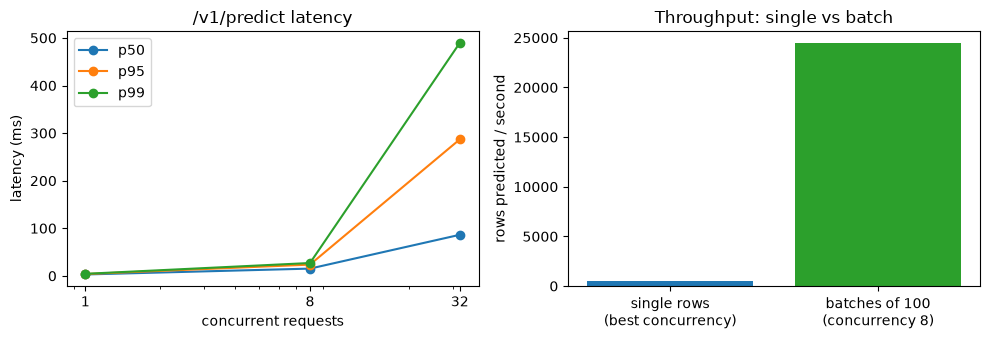

In [64]:
print(f"{'endpoint':22} {'conc':>4} {'errors':>6} {'p50 ms':>7} {'p95 ms':>7} {'p99 ms':>7} {'req/s':>7} {'rows/s':>8}")
for r in single_results:
    print(f"{'/v1/predict':22} {r['concurrency']:4d} {r['errors']:6d} {r['p50_ms']:7.1f} {r['p95_ms']:7.1f} {r['p99_ms']:7.1f} {r['rps']:7.0f} {r['rps']:8.0f}")
b = batch_result
print(f"{'/v1/predict/batch ×100':22} {b['concurrency']:4d} {b['errors']:6d} {b['p50_ms']:7.1f} {b['p95_ms']:7.1f} {b['p99_ms']:7.1f} {b['rps']:7.0f} {b['rps'] * 100:8.0f}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3.5))
levels = [r["concurrency"] for r in single_results]
for key in ["p50_ms", "p95_ms", "p99_ms"]:
    ax1.plot(levels, [r[key] for r in single_results], marker="o", label=key.replace("_ms", ""))
ax1.set(xscale="log", xlabel="concurrent requests", ylabel="latency (ms)", title="/v1/predict latency")
ax1.set_xticks(levels, [str(c) for c in levels])
ax1.legend()
best_single = max(single_results, key=lambda r: r["rps"])
ax2.bar(["single rows\n(best concurrency)", "batches of 100\n(concurrency 8)"], [best_single["rps"], batch_result["rps"] * 100], color=["tab:blue", "tab:green"])
ax2.set(ylabel="rows predicted / second", title="Throughput: single vs batch")
plt.tight_layout()
plt.show()

### Step 7 — Conclusions (computed from the measurements)

In [65]:
SLO_P95_MS = 50
at_8 = next(r for r in single_results if r["concurrency"] == 8)
total_errors = sum(r["errors"] for r in single_results) + batch_result["errors"]
batch_gain = batch_result["rps"] * 100 / best_single["rps"]

print(f"1. Quality: test MAE {test_mae:.3f} (≈ ${test_mae * 1e5:,.0f}) vs baseline {baseline_mae:.3f} → {1 - test_mae / baseline_mae:.0%} lower error; R² {test_r2:.3f}.")
print(f"2. Correctness: {total_errors} errors in {sum(r['requests'] for r in single_results) + batch_result['requests']} load-test requests; "
      f"API predictions match the offline model (max diff {max_diff:.1e}); all invalid inputs returned 4xx.")
print(f"3. SLO 'p95 < {SLO_P95_MS} ms at concurrency 8': p95 = {at_8['p95_ms']:.1f} ms → {'MET' if at_8['p95_ms'] < SLO_P95_MS else 'NOT met'}.")
worst = single_results[-1]
trend = "still grew" if worst["rps"] > 1.1 * at_8["rps"] else "dropped" if worst["rps"] < 0.9 * at_8["rps"] else "barely changed"
print(f"4. Under 32 concurrent requests p99 rose to {worst['p99_ms']:.1f} ms ({worst['p99_ms'] / single_results[0]['p99_ms']:.1f}× the single-client p99) "
      f"while throughput {trend} ({at_8['rps']:.0f} → {worst['rps']:.0f} req/s): past saturation, extra concurrency only adds queueing.")
print(f"5. Batching: {batch_result['rps'] * 100:,.0f} rows/s with 100-row batches vs {best_single['rps']:,.0f} rows/s one row at a time "
      f"→ {batch_gain:.0f}× more throughput for bulk scoring.")

1. Quality: test MAE 0.302 (≈ $30,154) vs baseline 0.906 → 67% lower error; R² 0.843.
2. Correctness: 0 errors in 940 load-test requests; API predictions match the offline model (max diff 5.0e-05); all invalid inputs returned 4xx.
3. SLO 'p95 < 50 ms at concurrency 8': p95 = 23.6 ms → MET.
4. Under 32 concurrent requests p99 rose to 489.6 ms (113.9× the single-client p99) while throughput dropped (488 → 265 req/s): past saturation, extra concurrency only adds queueing.
5. Batching: 24,428 rows/s with 100-row batches vs 488 rows/s one row at a time → 50× more throughput for bulk scoring.


**Stretch goals**
1. Run with `--workers 2` (or two replicas) and re-measure: how do p99 and throughput change? Why might a `def` endpoint benefit less from more threads than from more processes?
2. Remove `OMP_NUM_THREADS=1` and re-run the load test. Explain the difference (hint: thread oversubscription).
3. Add a `/metrics` endpoint with request counts and latency histograms (e.g. `prometheus-client`) and a structured JSON access log.
4. Replace the in-memory API-key list with hashed keys, and add a per-key token bucket from Exercise 6.
5. Add an async job API for large scoring jobs: `POST /v1/jobs` → `202` + job id, `GET /v1/jobs/{id}` for the result.

### 🗣️ How to talk about this in an interview
- "I trained a gradient-boosting regressor on California Housing, chose hyperparameters on a validation split, and touched the test set once: MAE around $30k versus $90k for a mean baseline."
- "The service loads the model once in the FastAPI lifespan, validates inputs with Pydantic bounds that I checked against all 20k real rows, forbids unknown fields, and returns 422 — never 500 — for bad input, including NaN, which I hit as a real bug in the default error handler."
- "It separates liveness from readiness, requires an API key, limits body size and batch length, propagates request IDs, and flags inputs outside the training range instead of silently extrapolating."
- "pytest covers auth, validation, parity with the offline model, and a directional model check; I ran it in CI style from a subprocess."
- "Under a closed-loop load test I report p50/p95/p99 at stated concurrency and compare single vs batch throughput. Next, I'd containerize it and add metrics, which is the next notebook."

## 🎤 Interview Q&A

Try answering **out loud** before opening each answer.

### 🧠 Concepts

**Q1. FastAPI or Flask for a new model-serving API — and is FastAPI "faster"?**

<details><summary>Show answer</summary>

- **30-second answer:** FastAPI for a typed JSON API: Pydantic validation (automatic 422s), generated OpenAPI docs, and native async and streaming. It is faster when endpoints mostly *wait* on I/O, because async handles many waiting requests cheaply. For CPU-bound inference, the model and the number of processes set the throughput in either framework.
- **Go deeper:** FastAPI is ASGI (Starlette + Pydantic); Flask is WSGI. Flask supports `async def` views, but each one runs in an event loop inside a worker thread, so there's no concurrency gain. Production: uvicorn (workers or replicas) vs Gunicorn. Flask still makes sense for existing codebases and server-rendered apps.
- **❌ Common wrong answer:** "FastAPI is async, so it bypasses the GIL and makes model inference faster."

</details>

**Q2. Which status code should invalid input return, and why must it never be 500?**

<details><summary>Show answer</summary>

- **30-second answer:** 422 (Unprocessable Content) for well-formed JSON that fails validation, 400 for requests that can't be parsed at all (FastAPI also uses 422 for broken JSON), 413 for oversized bodies. 5xx means *the server* is broken: it triggers alerts, and clients may retry it, multiplying bad traffic.
- **Go deeper:** Common 500 sources: hand-written parsing (`np.array(payload["x"])` on ragged lists), NaN accepted by `json.loads`, numpy types in responses, and a validation handler that echoes a NaN input and then fails to encode it. Fix with schemas (`min_length`, `allow_inf_nan=False`, `extra="forbid"`), a custom validation handler, and tests that assert 4xx for every bad payload.
- **❌ Common wrong answer:** "Return 200 with `{"error": ...}` in the body."

</details>

**Q3. In FastAPI, what's the difference between `def` and `async def` endpoints? Which should a scikit-learn model use?**

<details><summary>Show answer</summary>

- **30-second answer:** `async def` runs on the event loop and must only `await` non-blocking calls; `def` runs in a threadpool (40 threads by default), so a blocking call only ties up one thread. A scikit-learn predict is blocking CPU work, so use `def` (or `async def` + `await run_in_threadpool(...)`). Scale CPU throughput with processes or replicas.
- **Go deeper:** Blocking inside `async def` freezes *every* request on that process. We measured `/ping` waiting ~2 s behind `time.sleep` in an async endpoint. Threads keep the server responsive, but the GIL prevents a CPU speedup for pure-Python work. Some native libraries release the GIL, but don't count on it.
- **❌ Common wrong answer:** "A plain `def` endpoint is blocking, so always use `async def`."

</details>

**Q4. Where and how should a model be loaded in a web service?**

<details><summary>Show answer</summary>

- **30-second answer:** Once per process at startup in the lifespan handler, stored on `app.state`, injected into endpoints with a dependency. Not per request (we measured ~4× slower even for a 0.5 MB model), and never in request-scoped storage.
- **Go deeper:** Each worker process holds its own copy, so memory = model size × workers. Fail startup loudly if the artifact or library version is wrong. Report *not ready* until loading finishes. Send a warm-up prediction. For big models, download from a registry at startup or bake into the image, and consider a dedicated model server.
- **❌ Common wrong answer:** "Load it in the endpoint so you always use the latest file."

</details>

**Q5. What's the difference between liveness and readiness checks?**

<details><summary>Show answer</summary>

- **30-second answer:** Liveness asks "should the platform restart this container?" and must be cheap and independent of external systems. Readiness asks "should it receive traffic?" and checks the model is loaded and critical dependencies are reachable. A failing readiness check removes the instance from the load balancer without restarting it.
- **Go deeper:** Kubernetes also has a startup probe for slow model loads. Putting a database check in liveness causes cascading restarts during a DB outage. Readiness can also turn false during graceful shutdown so traffic drains first.
- **❌ Common wrong answer:** "They're the same; just have one `/health` that checks everything."

</details>

**Q6. Is `POST /predict` idempotent? When does that matter?**

<details><summary>Show answer</summary>

- **30-second answer:** POST isn't idempotent by definition, though a pure prediction has no side effects, so retrying is harmless. It matters when a POST creates something (a paid batch job, a logged decision): clients send an `Idempotency-Key`, and the server stores the first result and returns it for retries.
- **Go deeper:** GET, PUT, and DELETE are idempotent; proxies and client libraries may retry them automatically. Timeouts are the classic trigger: the client can't tell whether the server processed the request.
- **❌ Common wrong answer:** "Idempotent means the response is always identical."

</details>

### 💻 Coding

**Q7. Write a batch prediction endpoint that can't be crashed by bad input.**

<details><summary>Show answer</summary>

- **30-second answer:** A Pydantic body `rows: list[Features] = Field(min_length=1, max_length=N)`, where `Features` has bounded, finite fields and `extra="forbid"`. A sync `def` endpoint that builds one array in the training column order and makes one vectorized predict call, plus a body-size limit. Return plain Python types through a response model.
- **Go deeper:** Empty lists, ragged rows, wrong feature counts, strings, and NaN all become 422 before model code runs. Share one predict function with the single endpoint so results match, and test that parity. For very large jobs, use `202 Accepted` with a job id.
- **❌ Common wrong answer:** `X = np.array(request.json()["instances"]); return model.predict(X).tolist()` — every malformed request becomes a 500.

</details>

**Q8. How do you compute p95/p99 latency from a load test, and what can make the numbers misleading?**

<details><summary>Show answer</summary>

- **30-second answer:** Record every request's latency, then take percentiles (`np.percentile(lat, [50, 95, 99])` or nearest-rank). Always state the load (concurrency or request rate), request count, and hardware.
- **Go deeper:** Closed-loop tests suffer **coordinated omission** (a slow server receives less load, hiding the tail); use open-loop, fixed-rate load for SLO testing. Need enough samples (≥1,000 for a stable p99). Run the client on separate hardware and warm up first. Averages hide the tail, and per-host percentiles can't be averaged together.
- **❌ Common wrong answer:** "Average the latencies" or "p99 from 20 requests."

</details>

**Q9. How do you test a FastAPI service that loads a model at startup and requires an API key?**

<details><summary>Show answer</summary>

- **30-second answer:** A pytest fixture with `with TestClient(app) as client:` so the lifespan runs. Set config via environment variables before startup and clear cached settings. Test with a known test key, or override the auth dependency with `app.dependency_overrides`. Parametrize invalid payloads and assert 422.
- **Go deeper:** Add a parity test (API prediction == offline prediction on saved real rows), a readiness test (monkeypatch the model to `None` → 503), directional model checks, and treat warnings as errors in CI so deprecated APIs are caught early.
- **❌ Common wrong answer:** Creating `TestClient(app)` without `with` → the model never loads and tests fail with 503 or `AttributeError`.

</details>

### 🐛 Debugging Scenarios

**Q10. Under load, *all* endpoints — even `/health` — become slow whenever one heavy endpoint is called. What's wrong?**

<details><summary>Show answer</summary>

- **30-second answer:** Almost certainly blocking or CPU-heavy work inside an `async def` endpoint (a sync HTTP client, `time.sleep`, `model.predict`), which freezes the event loop for every request on that process. Make it `def`, use `await run_in_threadpool(...)`, or switch to async libraries.
- **Go deeper:** Confirm by timing a trivial endpoint during load, as we did with `/ping`, or with asyncio debug mode (`PYTHONASYNCIODEBUG=1` logs slow callbacks). If it's CPU saturation even with `def`, add workers or replicas, or move inference to a model server.
- **❌ Common wrong answer:** "Increase the threadpool size" — it doesn't help code that runs on the event loop thread.

</details>

**Q11. Clients report occasional 500s; logs show `ValueError: Out of range float values are not JSON compliant`. What happened and how do you fix it?**

<details><summary>Show answer</summary>

- **30-second answer:** Something produced NaN or Infinity in a response. Either the model output NaN, or a client sent `NaN` (which Python's JSON parser accepts) and the default 422 handler echoed it back in the error body. Validate with `allow_inf_nan=False`, use a validation handler that doesn't echo inputs, and check model outputs are finite before returning.
- **Go deeper:** Write a regression test posting `NaN` and `Infinity` bodies. Also check for numpy types and for features producing NaN after preprocessing (division by zero). Log which field failed, not the raw value.
- **❌ Common wrong answer:** "Wrap everything in `try/except` and return 200."

</details>

**Q12. The service's memory grows steadily until the container is OOM-killed after a few days. Where do you look?**

<details><summary>Show answer</summary>

- **30-second answer:** Unbounded in-process state: prediction logs appended to a list, caches without a max size, per-client dictionaries (rate limiters) that never expire, or the model reloaded and kept in memory repeatedly. Bound everything (`deque(maxlen)`, LRU/TTL caches) or move it to external stores.
- **Go deeper:** Measure with `tracemalloc` snapshots or memory metrics over time. Remember each worker has its own copy. `--limit-max-requests` (recycling workers) is a mitigation, not a fix. Also check large request bodies being retained (no size limit).
- **❌ Common wrong answer:** "Python has garbage collection, so it can't leak."

</details>

### 🏗️ Design

**Q13. Design an inference API that serves a tabular model at 2,000 requests/s with p99 < 100 ms.**

<details><summary>Show answer</summary>

- **30-second answer:** Stateless FastAPI containers behind a load balancer, autoscaled on CPU and latency. `def` endpoints, model loaded in the lifespan, one process per container (or a few workers), and readiness probes. Load-test to find per-replica capacity at the p99 target, then provision with headroom (e.g. run at ≤60% of the knee).
- **Go deeper:** Offer a batch endpoint for bulk clients. Cache repeated requests. Consider ONNX/Treelite for faster inference. Set `OMP_NUM_THREADS` to avoid oversubscription. Put rate limits and auth at the gateway. Monitor p50/p95/p99, error rate, saturation, and input drift. Roll out new model versions gradually (canary) with a quick rollback path.
- **❌ Common wrong answer:** "Use async endpoints and one big server" — async doesn't add CPU capacity, and a single instance is a single point of failure.

</details>

**Q14. How would you expose an LLM through your own API with streaming, safely?**

<details><summary>Show answer</summary>

- **30-second answer:** An `async def` endpoint that validates the request (prompt length, allowed parameters), authenticates and rate-limits per user (by tokens, not just requests), calls the provider with an async client and `stream=True`, and re-yields token deltas as Server-Sent Events.
- **Go deeper:** Stop generation when the client disconnects (saves money). Send keep-alive comments and disable proxy buffering. Set timeouts and max tokens. Log usage and cost, not raw prompts containing PII. Moderate inputs and outputs. Return 429 with `Retry-After` when upstream quotas are exhausted. Use WebSockets only when you need two-way messages.
- **❌ Common wrong answer:** "Use a sync `requests` call inside `async def` and return the whole answer at the end."

</details>

## 🧪 Quick Quiz

Predict the answer, then reveal. Every answer was checked by running it with the versions in the header.

**1.** A body model has `sepal_length: float = Field(gt=0)`. What happens to `{"sepal_length": "5.1", ...}` (a string)?
<details><summary>Answer</summary>

It's **accepted** as `5.1`: Pydantic v2 is lax by default and converts numeric strings. Use `ConfigDict(strict=True)` (or `Field(strict=True)`) to reject it.
</details>

**2.** 50 clients call a plain `def` endpoint that does `time.sleep(0.2)` at the same moment, on one uvicorn process. Roughly how long until all 50 finish?
<details><summary>Answer</summary>

About **0.4 s**. The threadpool runs 40 at once (anyio's default limit), and the last 10 wait for a free thread. (Measured: 10 → 0.22 s, 40 → 0.24 s, 50 → 0.44 s.)
</details>

**3.** You register middleware `a`, then middleware `b`, both with `@app.middleware("http")`. Which runs first on an incoming request?
<details><summary>Answer</summary>

**`b`**. The last middleware added becomes the outermost layer.
</details>

**4.** `client = TestClient(app)` (no `with`), and the app loads its model in `lifespan`. What does `client.post("/predict", ...)` return in Section 5's app?
<details><summary>Answer</summary>

**503 "Model not loaded"**. Without `with`, the lifespan never runs, so `app.state.bundle` was never set.
</details>

**5.** `np.percentile([10] * 98 + [500, 1000], 99)` — what's the p99?
<details><summary>Answer</summary>

**≈ 505**. NumPy interpolates linearly between the 99th and 100th sorted values (position 98.01 of 0–99). The nearest-rank method would give **500**. With 100 samples, p99 depends on just one or two requests.
</details>

## 📚 Resources

### 📖 Official Docs
- [FastAPI Tutorial - User Guide](https://fastapi.tiangolo.com/tutorial/) — the official step-by-step guide; every section here maps to a chapter there
- [FastAPI — Lifespan Events](https://fastapi.tiangolo.com/advanced/events/) — loading models at startup, with an ML example
- [FastAPI — Concurrency and async / await](https://fastapi.tiangolo.com/async/) — the official explanation of `def` vs `async def`
- [FastAPI — Testing](https://fastapi.tiangolo.com/tutorial/testing/) — `TestClient` and pytest
- [Pydantic — Validators](https://docs.pydantic.dev/latest/concepts/validators/) — `field_validator`, `model_validator`, and validation modes
- [Uvicorn — Deployment](https://uvicorn.dev/deployment/) — workers, process managers, running behind a proxy
- [ASGI HTTP & WebSocket spec](https://asgi.readthedocs.io/en/latest/specs/www.html) — the exact `scope`/`receive`/`send` messages used in 🔧 Build It From Scratch
- [MDN — HTTP response status codes](https://developer.mozilla.org/en-US/docs/Web/HTTP/Reference/Status) — every status code explained
- [Flask — Quickstart](https://flask.palletsprojects.com/en/stable/quickstart/) — the Flask side of Section 14
- [OWASP API Security Top 10 (2023)](https://owasp.org/API-Security/editions/2023/en/0x11-t10/) — the security checklist interviewers expect you to know

### 🎥 Videos
- [freeCodeCamp — FastAPI Course for Beginners](https://www.youtube.com/watch?v=tLKKmouUams) (~1 h) — a gentle hands-on pass over path, query, and body parameters if Sections 2–3 felt fast
- [ArjanCodes — How to Use FastAPI: A Detailed Python Tutorial](https://www.youtube.com/watch?v=SORiTsvnU28) (~20 min) — an experienced engineer builds a small API with Pydantic models and good structure
- [ArjanCodes — Anatomy of a Scalable Python Project (FastAPI)](https://www.youtube.com/watch?v=Af6Zr0tNNdE) (~20 min) — how to organize a real FastAPI codebase, a good follow-up to Section 14 and the mini project

### 📄 Papers
- [Dean & Barroso (2013) — The Tail at Scale](https://research.google/pubs/the-tail-at-scale/) — why p99 latency dominates user experience in fan-out systems (Section 13)
- [RFC 9110 — HTTP Semantics](https://www.rfc-editor.org/rfc/rfc9110.html) — the standard behind methods, idempotency, and status codes (Section 1)
- [Sculley et al. (2015) — Hidden Technical Debt in Machine Learning Systems](https://papers.nips.cc/paper_files/paper/2015/hash/86df7dcfd896fcaf2674f757a2463eba-Abstract.html) — why the serving code around a model is most of the work

### 📘 Books & Courses
- [Full Stack FastAPI Template](https://github.com/fastapi/full-stack-fastapi-template) — the official production-style project template (FastAPI, tests, Docker, CI)
- [Stanford CS 329S — Machine Learning Systems Design](https://stanford-cs329s.github.io/) — free lecture notes on deploying and serving models

### 🏋️ Practice
- [roadmap.sh — API Design](https://roadmap.sh/api-design) — a structured checklist of API topics to practise (versioning, pagination, auth, rate limiting)
- [Locust — Quick start](https://docs.locust.io/en/stable/quickstart.html) — write a Python load test against your mini-project service and compare with Section 13

## 📝 Summary Cheat Sheet

| Concept | What it does | Key API / rule |
|---|---|---|
| HTTP basics | request/response contract | 2xx ok · 4xx client (401 auth, 403 forbidden, 413 too big, 422 invalid, 429 slow down) · 5xx server (503 not ready) |
| Routes & params | map URLs to functions | `@app.get/post`, path `{x}`, query params, `Annotated[int, Path/Query(ge=, le=)]` |
| Validation | reject bad input before the model | Pydantic `BaseModel`, `Field(gt, le, min_length, max_length, allow_inf_nan=False, examples=[...])`, `extra="forbid"`, `field_validator`, `model_validator` |
| Responses & errors | consistent, safe output | `response_model`, `HTTPException`, `add_exception_handler`, custom `RequestValidationError` handler (no input echo) |
| Lifespan | load once, clean up at shutdown | `@asynccontextmanager async def lifespan(app)` → `FastAPI(lifespan=...)`, `app.state` |
| Dependencies | inject model, settings, auth | `Depends`, `Security(APIKeyHeader(...))`, `secrets.compare_digest`, `dependency_overrides` |
| Concurrency | keep the event loop free | `def` → threadpool (40); `async def` only with `await`; `run_in_threadpool`; CPU throughput = processes |
| Batching & limits | fast, bounded bulk scoring | `list[Row] = Field(min_length=1, max_length=N)`, one vectorized predict, 413 body limit |
| Background tasks | small post-response work | `BackgroundTasks.add_task(fn, ...)`; real queues for durable work |
| Streaming | partial results as they're ready | `response_class=EventSourceResponse` + `yield ServerSentEvent(...)` |
| Middleware & CORS | cross-cutting concerns | `@app.middleware("http")` (last added runs first), request IDs, timing, `CORSMiddleware(allow_origins=[...])` |
| Health | orchestration signals | `/health` liveness (cheap) vs `/ready` readiness (model loaded) |
| Testing | prove behaviour | `with TestClient(app) as c`, pytest fixtures, parametrize bad inputs → 422 |
| Running | real server | `uvicorn module:app --host 0.0.0.0 --port 8000 [--workers N]`; SIGTERM = graceful shutdown |
| Latency | what users feel | p50/p95/p99 at stated load; closed vs open loop; batch for throughput |
| ASGI | the contract under FastAPI | `async def app(scope, receive, send)` |

## ➡️ What's Next

**[02 · Docker and CI/CD](02_Docker_and_CI_CD.ipynb)** — your service runs on your laptop. Next you'll package this exact kind of service into a small, secure Docker image, and build a CI pipeline that lints, tests, checks model quality, and ships the image automatically.